# Analyse en Voorspellingen van Wedstrijden in de Jupiler Pro League

**Academisch project / Data-analyse notebook**

Auteur: Torben de Schrijver
Datum: [2026]

Beschrijving: Deze notebook is bedoeld om factoren te analyseren die voetbalwedstrijden beïnvloeden, en om voorspellingen van experts te vergelijken met datagedreven modellen.

## 0. Imports


In [742]:
import pyodbc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import re
from scipy.stats import ttest_ind, chisquare, pearsonr, pointbiserialr, f_oneway, chi2_contingency


## 1. Introductie

### Doel van de analyse
Het doel van deze analyse is te onderzoeken hoe expertinschattingen van voetbalwedstrijden overeenkomen met data-gedreven voorspellingen op basis van historische wedstrijdstatistieken.

### Onderzoeksvraag
In welke mate zijn de voorspellingen van experts (journalisten, analisten, trainers) accuraat vergeleken met analyses gemaakt met programmeercode en machine learning modellen?

### Dataset beschrijving
De dataset bevat historische wedstrijddata van de Jupiler Pro League, inclusief:
- Wedstrijdresultaten
- Aantal doelpunten en kaarten
- Teamstatistieken (schoten, corners, ranglijstpositie, thuis/uit)
- Weersomstandigheden en stadioninformatie  
Daarnaast bevat de dataset ingevulde vragenlijsten van experts met hun voorspellingen en factorbeoordelingen.

### Overzicht van de methode
1. **Data verzamelen**: Historische wedstrijden en ingevulde vragenlijsten van experts.  
2. **Feature selectie**: Factoren zoals thuisvoordeel, recente vorm, rangverschil, weersomstandigheden.  
3. **Vergelijking voorspellingen**: Experts vs data-gedreven modellen.  
4. **Analyse**: Accuracy, bias-analyse, invloed van factoren en correlaties tussen expertinschattingen en resultaten.  
5. **Visualisatie en rapportage**: Grafieken, tabellen en samenvatting van inzichten.

## 2. Data laden

- Wedstrijddataset
- Weersdata
- Teams / Ranglijst
- Experts dataset

Commentaar over de structuur van de data

### Database connectie instellen

In [743]:
server = 'localhost'
database = 'JPL_Data'
username = 'tds'
password = 'tds'

conn_str = (
    "DRIVER={ODBC Driver 18 for SQL Server};"
    f"SERVER={server};"
    f"DATABASE={database};"
    f"UID={username};"
    f"PWD={password};"
    "Encrypt=yes;"
    "TrustServerCertificate=yes;"
#    "Trusted_Connection=yes;"
)
conn = pyodbc.connect(conn_str)

### Tabellen inladen

In [744]:
# Team
team_df = pd.read_sql("SELECT * FROM Team;", conn)

# Wedstrijd
wedstrijd_df = pd.read_sql("SELECT * FROM Wedstrijd;", conn)

# WedstrijdStatistiek
statistiek_df = pd.read_sql("SELECT * FROM WedstrijdStatistiek;", conn)

# WedstrijdWeer
weer_df = pd.read_sql("SELECT * FROM WedstrijdWeer;", conn)

# WedstrijdWeerVooraf
weer_vooraf_df = pd.read_sql("SELECT * FROM WedstrijdWeerVooraf;", conn)

## 3. Data cleaning

### Wedstrijddata

In [745]:
wedstrijd_df.info()

wedstrijd_df = wedstrijd_df.drop(['divisie'], axis=1)


<class 'pandas.DataFrame'>
RangeIndex: 2006 entries, 0 to 2005
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   wedstrijd_id     2006 non-null   int64 
 1   divisie          2006 non-null   str   
 2   wedstrijd_datum  2006 non-null   object
 3   wedstrijd_tijd   2006 non-null   object
 4   thuis_team       2006 non-null   str   
 5   uit_team         2006 non-null   str   
dtypes: int64(1), object(2), str(3)
memory usage: 94.2+ KB


In [746]:
print(statistiek_df.info())

# 1. Selecteer float64 kolommen
float_cols = statistiek_df.select_dtypes(include=['float64']).columns

# 2. Vul NaN met gemiddelde van elke kolom
statistiek_df[float_cols] = statistiek_df[float_cols].fillna(statistiek_df[float_cols].mean())

# 3. Rond af en converteer naar gewone int64
statistiek_df[float_cols] = statistiek_df[float_cols].round(0).astype('int')

# Check
print(statistiek_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2006 entries, 0 to 2005
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   wedstrijd_id               2006 non-null   int64  
 1   doelpunten_thuis_voltijd   2006 non-null   int64  
 2   doelpunten_uit_voltijd     2006 non-null   int64  
 3   resultaat_voltijd          2006 non-null   str    
 4   doelpunten_thuis_halftijd  2001 non-null   float64
 5   doelpunten_uit_halftijd    2001 non-null   float64
 6   resultaat_halftijd         2006 non-null   str    
 7   schoten_thuis              2000 non-null   float64
 8   schoten_uit                2000 non-null   float64
 9   schoten_op_doel_thuis      2000 non-null   float64
 10  schoten_op_doel_uit        2000 non-null   float64
 11  overtredingen_thuis        2000 non-null   float64
 12  overtredingen_uit          2000 non-null   float64
 13  corners_thuis              2000 non-null   float64
 14  cor

In [747]:
team_df.info()

team_df = team_df.drop(['latitude', 'longitude'], axis=1)

<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   team_naam           24 non-null     str    
 1   latitude            24 non-null     float64
 2   longitude           24 non-null     float64
 3   stadion_capaciteit  24 non-null     int64  
dtypes: float64(2), int64(1), str(1)
memory usage: 896.0 bytes


In [748]:
weer_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2006 entries, 0 to 2005
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   wedstrijd_id                    2006 non-null   int64  
 1   temperatuur_c                   2006 non-null   float64
 2   neerslag_mm                     2006 non-null   float64
 3   relatieve_luchtvochtigheid_pct  2006 non-null   int64  
 4   windsnelheid_m_s                2006 non-null   float64
 5   windrichting_graden             2006 non-null   int64  
 6   windstoten_m_s                  2006 non-null   float64
 7   bewolking_pct                   2006 non-null   int64  
 8   weercode                        2006 non-null   int64  
 9   luchtdruk_hpa                   2006 non-null   float64
 10  temperatuur_gem_c               2006 non-null   float64
 11  neerslag_som_mm                 2006 non-null   float64
 12  windsnelheid_gem_m_s            2006 non-null

In [749]:
weer_vooraf_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2006 entries, 0 to 2005
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   wedstrijd_id                  2006 non-null   int64  
 1   temperatuur_gem_laatste48_c   2006 non-null   float64
 2   neerslag_som_laatste48_mm     2006 non-null   float64
 3   windstoten_max_laatste48_m_s  2006 non-null   float64
 4   regen_uren_laatste48          2006 non-null   int64  
 5   hitte_uren_laatste48          2006 non-null   int64  
dtypes: float64(3), int64(3)
memory usage: 94.2 KB


#### Tabellen mergen

In [750]:
wedstrijden_compleet_df = (
    wedstrijd_df
    .merge(statistiek_df, on='wedstrijd_id', how='left')
    .merge(weer_df, on='wedstrijd_id', how='left')
    .merge(weer_vooraf_df, on='wedstrijd_id', how='left')
)

# merge met team info (thuis en uit)
wedstrijden_compleet_df = (
    wedstrijden_compleet_df
    .merge(team_df.add_prefix('thuis_'), left_on='thuis_team', right_on='thuis_team_naam', how='left')
    .merge(team_df.add_prefix('uit_'), left_on='uit_team', right_on='uit_team_naam', how='left')
)

wedstrijden_compleet_df = wedstrijden_compleet_df.drop('wedstrijd_id', axis=1)

print("Shape van complete dataset:", wedstrijden_compleet_df.shape)
wedstrijden_compleet_df.info()
wedstrijden_compleet_df.head()

Shape van complete dataset: (2006, 44)
<class 'pandas.DataFrame'>
RangeIndex: 2006 entries, 0 to 2005
Data columns (total 44 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   wedstrijd_datum                 2006 non-null   object 
 1   wedstrijd_tijd                  2006 non-null   object 
 2   thuis_team                      2006 non-null   str    
 3   uit_team                        2006 non-null   str    
 4   doelpunten_thuis_voltijd        2006 non-null   int64  
 5   doelpunten_uit_voltijd          2006 non-null   int64  
 6   resultaat_voltijd               2006 non-null   str    
 7   doelpunten_thuis_halftijd       2006 non-null   int64  
 8   doelpunten_uit_halftijd         2006 non-null   int64  
 9   resultaat_halftijd              2006 non-null   str    
 10  schoten_thuis                   2006 non-null   int64  
 11  schoten_uit                     2006 non-null   int64  
 12  schote

,wedstrijd_datum,wedstrijd_tijd,thuis_team,uit_team,doelpunten_thuis_voltijd,doelpunten_uit_voltijd,resultaat_voltijd,doelpunten_thuis_halftijd,doelpunten_uit_halftijd,resultaat_halftijd,...,windstoten_max_m_s,temperatuur_gem_laatste48_c,neerslag_som_laatste48_mm,windstoten_max_laatste48_m_s,regen_uren_laatste48,hitte_uren_laatste48,thuis_team_naam,thuis_stadion_capaciteit,uit_team_naam,uit_stadion_capaciteit
0,2019-07-26,19:30:00,Genk,Kortrijk,2,1,H,0,1,A,...,35.6,30.6,0.0,37.4,0,23,Genk,23718,Kortrijk,9399
1,2019-07-27,17:00:00,Cercle Brugge,Standard,0,2,A,0,0,D,...,28.1,25.9,0.0,45.4,0,27,Cercle Brugge,29062,Standard,27670
2,2019-07-27,19:00:00,St Truiden,Mouscron,0,1,A,0,1,A,...,28.1,29.0,0.3,31.3,1,27,St Truiden,14600,Mouscron,12800
3,2019-07-27,19:00:00,Waregem,Mechelen,0,2,A,0,1,A,...,21.2,25.8,0.1,38.9,1,26,Waregem,12414,Mechelen,16672
4,2019-07-27,19:30:00,Waasland-Beveren,Club Brugge,1,3,A,1,1,D,...,24.5,26.8,0.0,38.5,0,25,Waasland-Beveren,8190,Club Brugge,29062


## 4. Feature engineering

In [751]:
# Kopieer je dataframe voor veiligheid
df = wedstrijden_compleet_df.copy()

### Seizoenkolom toevoegen

In [752]:
def seizoen_bepalen(datum):
    jaar = datum.year
    if datum.month >= 7:  # juli-december → nieuw seizoen startjaar
        return f"{jaar}/{jaar+1}"
    else:                # januari-juni → vorig jaar als startjaar
        return f"{jaar-1}/{jaar}"

# Voeg kolom toe
df['seizoen'] = df['wedstrijd_datum'].apply(seizoen_bepalen)

# Controleer relevante kolommen
df[['wedstrijd_datum', 'wedstrijd_tijd', 'thuis_team', 'uit_team', 'resultaat_voltijd', 'seizoen']].head()

,wedstrijd_datum,wedstrijd_tijd,thuis_team,uit_team,resultaat_voltijd,seizoen
0,2019-07-26,19:30:00,Genk,Kortrijk,H,2019/2020
1,2019-07-27,17:00:00,Cercle Brugge,Standard,A,2019/2020
2,2019-07-27,19:00:00,St Truiden,Mouscron,A,2019/2020
3,2019-07-27,19:00:00,Waregem,Mechelen,A,2019/2020
4,2019-07-27,19:30:00,Waasland-Beveren,Club Brugge,A,2019/2020


### Rangschikking

In [753]:
# Sorteer op datum per seizoen
df = df.sort_values(['seizoen','wedstrijd_datum'])

# Kolommen voor rang
df['thuis_rank'] = 0
df['uit_rank'] = 0

# Itereer per seizoen
for seizoen in df['seizoen'].unique():
    df_seizoen = df[df['seizoen']==seizoen].copy()
    teams = pd.unique(df_seizoen[['thuis_team','uit_team']].values.ravel())
    
    # Initialiseer dict
    stats_dict = {team: {'punten':0, 'doelpunten_voor':0, 'doelpunten_tegen':0} for team in teams}
    
    ranglijst_thuis = []
    ranglijst_uit = []
    
    for idx, row in df_seizoen.iterrows():
        thuis = row['thuis_team']
        uit = row['uit_team']
        resultaat = row['resultaat_voltijd']
        
        # Punten toevoegen
        if resultaat == 'H':
            stats_dict[thuis]['punten'] += 3
        elif resultaat == 'A':
            stats_dict[uit]['punten'] += 3
        elif resultaat == 'D':
            stats_dict[thuis]['punten'] += 1
            stats_dict[uit]['punten'] += 1
        
        # Doelpunten bijwerken
        doel_thuis = row['doelpunten_thuis_voltijd'] if pd.notnull(row['doelpunten_thuis_voltijd']) else 0
        doel_uit = row['doelpunten_uit_voltijd'] if pd.notnull(row['doelpunten_uit_voltijd']) else 0
        
        stats_dict[thuis]['doelpunten_voor'] += doel_thuis
        stats_dict[thuis]['doelpunten_tegen'] += doel_uit
        
        stats_dict[uit]['doelpunten_voor'] += doel_uit
        stats_dict[uit]['doelpunten_tegen'] += doel_thuis
        
        # Bereken doelpuntenverschil
        for team in teams:
            stats_dict[team]['doelpuntenverschil'] = stats_dict[team]['doelpunten_voor'] - stats_dict[team]['doelpunten_tegen']
        
        # Sorteer op punten, dan doelpuntenverschil
        sorted_teams = sorted(stats_dict.items(), key=lambda x: (-x[1]['punten'], -x[1]['doelpuntenverschil'], x[0]))
        team_rank = {team:rank+1 for rank, (team, stats) in enumerate(sorted_teams)}
        
        ranglijst_thuis.append(team_rank[thuis])
        ranglijst_uit.append(team_rank[uit])
    
    df.loc[df['seizoen']==seizoen, 'thuis_rank'] = ranglijst_thuis
    df.loc[df['seizoen']==seizoen, 'uit_rank'] = ranglijst_uit

# Check
df[['wedstrijd_datum','thuis_team','uit_team','resultaat_voltijd','seizoen','thuis_rank','uit_rank']].tail(15)

,wedstrijd_datum,thuis_team,uit_team,resultaat_voltijd,seizoen,thuis_rank,uit_rank
1991,2026-03-07,Oud-Heverlee Leuven,Westerlo,A,2025/2026,14,7
1992,2026-03-07,Dender,Charleroi,D,2025/2026,16,11
1993,2026-03-07,St. Gilloise,Genk,H,2025/2026,1,6
1994,2026-03-08,Club Brugge,Anderlecht,D,2025/2026,2,4
1995,2026-03-08,Gent,Mechelen,H,2025/2026,6,5
1996,2026-03-08,Waregem,Standard,A,2025/2026,12,9
1997,2026-03-08,St Truiden,Cercle Brugge,H,2025/2026,3,13
1998,2026-03-13,Gent,Waregem,H,2025/2026,5,12
1999,2026-03-14,Charleroi,Oud-Heverlee Leuven,A,2025/2026,11,12
2000,2026-03-14,St. Gilloise,Dender,H,2025/2026,1,16


### Titelstrijd / degradatiestrijd

In [754]:
# Voeg velden toe
df['titel_match'] = 0
df['degradatie_match'] = 0

# Sorteer op datum per seizoen
df = df.sort_values(['seizoen', 'wedstrijd_datum'])

for seizoen in df['seizoen'].unique():
    df_seizoen = df[df['seizoen'] == seizoen].copy()
    teams = pd.unique(df_seizoen[['thuis_team', 'uit_team']].values.ravel())
    
    # Initialiseer stats
    stats_dict = {team: {'punten':0, 'doelpunten_voor':0, 'doelpunten_tegen':0} for team in teams}
    
    for idx, row in df_seizoen.iterrows():
        thuis = row['thuis_team']
        uit = row['uit_team']
        resultaat = row['resultaat_voltijd']
        
        # Punten
        if resultaat == 'H':
            stats_dict[thuis]['punten'] += 3
        elif resultaat == 'A':
            stats_dict[uit]['punten'] += 3
        elif resultaat == 'D':
            stats_dict[thuis]['punten'] += 1
            stats_dict[uit]['punten'] += 1
        
        # Doelpunten
        doel_thuis = row['doelpunten_thuis_voltijd'] if pd.notnull(row['doelpunten_thuis_voltijd']) else 0
        doel_uit = row['doelpunten_uit_voltijd'] if pd.notnull(row['doelpunten_uit_voltijd']) else 0
        stats_dict[thuis]['doelpunten_voor'] += doel_thuis
        stats_dict[thuis]['doelpunten_tegen'] += doel_uit
        stats_dict[uit]['doelpunten_voor'] += doel_uit
        stats_dict[uit]['doelpunten_tegen'] += doel_thuis
        
        # Doelpuntenverschil
        for team in teams:
            stats_dict[team]['doelpuntenverschil'] = stats_dict[team]['doelpunten_voor'] - stats_dict[team]['doelpunten_tegen']
        
        # Ranglijst op punten en doelpuntenverschil
        sorted_teams = sorted(stats_dict.items(), key=lambda x: (-x[1]['punten'], -x[1]['doelpuntenverschil'], x[0]))
        team_rank = {team: rank+1 for rank, (team, stats) in enumerate(sorted_teams)}
        
        thuis_rank = team_rank[thuis]
        uit_rank = team_rank[uit]
        punten_thuis = stats_dict[thuis]['punten']
        punten_uit = stats_dict[uit]['punten']
        
        # Titelwedstrijd: beide in top2, >40 punten, max 5 punten verschil
        if thuis_rank <= 2 and uit_rank <= 2 and punten_thuis > 40 and punten_uit > 40 and abs(punten_thuis - punten_uit) <= 5:
            df.loc[idx, 'titel_match'] = 1
        
        # Degradatiewedstrijd: seizoen >20 wedstrijden, beide in laatste 3, max 3 punten verschil
        if idx > 20:  # indicatief: seizoen gevorderd
            max_rank = len(teams)
            if thuis_rank >= max_rank-2 and uit_rank >= max_rank-2 and abs(punten_thuis - punten_uit) <= 3:
                df.loc[idx, 'degradatie_match'] = 1

In [755]:
# Toon enkele wedstrijden voor titelstrijd
titel_wedstrijden = df[df['titel_match'] == 1]
print("Voorbeeld Titelwedstrijden:")
print(titel_wedstrijden[['wedstrijd_datum', 'wedstrijd_tijd','thuis_team','uit_team','thuis_rank','uit_rank','titel_match']].head(10))

# Toon enkele wedstrijden voor degradatiestrijd
degradatie_wedstrijden = df[df['degradatie_match'] == 1]
print("\nVoorbeeld Degradatiewedstrijden:")
print(degradatie_wedstrijden[['wedstrijd_datum','wedstrijd_tijd','thuis_team','uit_team','thuis_rank','uit_rank','degradatie_match']].head(10))

Voorbeeld Titelwedstrijden:
     wedstrijd_datum wedstrijd_tijd    thuis_team      uit_team  thuis_rank  \
1103      2023-03-12       17:30:00          Genk  St. Gilloise           1   
1410      2024-04-14       17:30:00    Anderlecht  St. Gilloise           2   
1440      2024-05-05       17:30:00  St. Gilloise    Anderlecht           1   

      uit_rank  titel_match  
1103         2            1  
1410         1            1  
1440         2            1  

Voorbeeld Degradatiewedstrijden:
     wedstrijd_datum wedstrijd_tijd           thuis_team          uit_team  \
122       2019-11-23       19:00:00     Waasland-Beveren     Cercle Brugge   
169       2020-01-18       19:00:00             Oostende  Waasland-Beveren   
354       2020-12-01       16:00:00             Mouscron        St Truiden   
421       2021-01-19       17:45:00             Mouscron  Waasland-Beveren   
476       2021-02-20       17:30:00             Mouscron     Cercle Brugge   
880       2022-08-19       19:45:

### Rivalen / Derby

In [756]:
# Lijst van echte Belgische derby's / klassieke rivalen
klassieke_rivalen = [
    ("Antwerp", "Beerschot VA"),            # Antwerpse derby
    ("RSC Anderlecht", "Club Brugge"),      # De Topper / Belgische klassieker
    ("Club Brugge", "Cercle Brugge"),       # Brugse derby
    ("Club Brugge", "Union Saint-Gilloise"),# Moderne rivaliteit
    ("Standard", "RSC Anderlecht")          # Belgian Clasico
]

# Functie om te controleren of een wedstrijd een derby/rivaliteit is
def is_derby(row):
    thuis = row['thuis_team']
    uit = row['uit_team']
    return int(any((thuis, uit) == pair or (uit, thuis) == pair for pair in klassieke_rivalen))

# Voeg het veld toe aan je dataframe
wedstrijden_compleet_df['derby/rivaal'] = wedstrijden_compleet_df.apply(is_derby, axis=1)

# Check een paar voorbeelden
print(wedstrijden_compleet_df[['thuis_team', 'uit_team', 'derby/rivaal']].head(10))

         thuis_team     uit_team  derby/rivaal
0              Genk     Kortrijk             0
1     Cercle Brugge     Standard             0
2        St Truiden     Mouscron             0
3           Waregem     Mechelen             0
4  Waasland-Beveren  Club Brugge             0
5        Anderlecht     Oostende             0
6         Charleroi         Gent             0
7             Eupen      Antwerp             0
8       Club Brugge   St Truiden             0
9          Standard      Waregem             0


### Aanvallende of Verdedigende ploeg

In [757]:
# ===============================
# OPTIMALE SPEELSTIJL FEATURE
# ===============================

import pandas as pd
from sklearn.preprocessing import StandardScaler

# ===============================
# 1️⃣ Team statistieken (thuis + uit)
# ===============================

home_stats = df.groupby("thuis_team").agg({
    "schoten_thuis": "mean",
    "doelpunten_thuis_voltijd": "mean",
    "corners_thuis": "mean",
    "schoten_uit": "mean",
    "doelpunten_uit_voltijd": "mean"
}).rename(columns={
    "schoten_thuis": "shots_for",
    "doelpunten_thuis_voltijd": "goals_for",
    "corners_thuis": "corners_for",
    "schoten_uit": "shots_against",
    "doelpunten_uit_voltijd": "goals_against"
})

away_stats = df.groupby("uit_team").agg({
    "schoten_uit": "mean",
    "doelpunten_uit_voltijd": "mean",
    "corners_uit": "mean",
    "schoten_thuis": "mean",
    "doelpunten_thuis_voltijd": "mean"
}).rename(columns={
    "schoten_uit": "shots_for",
    "doelpunten_uit_voltijd": "goals_for",
    "corners_uit": "corners_for",
    "schoten_thuis": "shots_against",
    "doelpunten_thuis_voltijd": "goals_against"
})

# Combineer thuis + uit
team_stats = pd.concat([home_stats, away_stats]).groupby(level=0).mean()

# ===============================
# 2️⃣ Normalisatie (HEEL BELANGRIJK)
# ===============================

features = ['shots_for','goals_for','corners_for','shots_against','goals_against']

scaler = StandardScaler()
scaled = scaler.fit_transform(team_stats[features])

team_scaled = pd.DataFrame(scaled, columns=features, index=team_stats.index)

# ===============================
# 3️⃣ Attack & Defense score
# ===============================

team_stats["attack_score"] = (
    0.4 * team_scaled["shots_for"] +
    0.4 * team_scaled["goals_for"] +
    0.2 * team_scaled["corners_for"]
)

team_stats["defense_score"] = (
    0.6 * team_scaled["goals_against"] +
    0.4 * team_scaled["shots_against"]
)

# ===============================
# 4️⃣ Style score (hoog = aanvallend)
# ===============================

team_stats["style_score"] = team_stats["attack_score"] - team_stats["defense_score"]

# ===============================
# 5️⃣ Dynamische classificatie
# ===============================

low = team_stats["style_score"].quantile(0.33)
high = team_stats["style_score"].quantile(0.66)

def classify(x):
    if x >= high:
        return "Aanvallend"
    elif x <= low:
        return "Verdedigend"
    else:
        return "Gebalanceerd"

team_stats["speelstijl"] = team_stats["style_score"].apply(classify)

# ===============================
# 6️⃣ Merge naar match dataset
# ===============================

df = df.merge(team_stats["speelstijl"], left_on="thuis_team", right_index=True, how="left")
df = df.rename(columns={"speelstijl": "thuis_speelstijl"})

df = df.merge(team_stats["speelstijl"], left_on="uit_team", right_index=True, how="left")
df = df.rename(columns={"speelstijl": "uit_speelstijl"})

# ===============================
# 7️⃣ Controle
# ===============================

print(team_stats[["attack_score","defense_score","style_score","speelstijl"]]
      .sort_values("style_score"))

df[["thuis_team","uit_team","thuis_speelstijl","uit_speelstijl"]].head()

                     attack_score  defense_score  style_score    speelstijl
RWD Molenbeek           -1.147590       1.549976    -2.697567   Verdedigend
Seraing                 -1.564255       1.035008    -2.599263   Verdedigend
Waasland-Beveren        -1.261363       0.882011    -2.143374   Verdedigend
Dender                  -0.917247       0.946450    -1.863697   Verdedigend
Beerschot VA            -0.336226       1.461689    -1.797914   Verdedigend
Eupen                   -0.640314       0.927060    -1.567375   Verdedigend
Waregem                 -0.289995       0.917190    -1.207185   Verdedigend
Kortrijk                -0.426545       0.555568    -0.982113   Verdedigend
Mouscron                -1.031778      -0.370464    -0.661314  Gebalanceerd
Oostende                -0.275974       0.310824    -0.586798  Gebalanceerd
Oud-Heverlee Leuven      0.078702       0.520846    -0.442144  Gebalanceerd
RAAL La Louviere        -1.083172      -0.760017    -0.323155  Gebalanceerd
St Truiden  

,thuis_team,uit_team,thuis_speelstijl,uit_speelstijl
0,Genk,Kortrijk,Aanvallend,Verdedigend
1,Cercle Brugge,Standard,Aanvallend,Gebalanceerd
2,St Truiden,Mouscron,Gebalanceerd,Gebalanceerd
3,Waregem,Mechelen,Verdedigend,Gebalanceerd
4,Waasland-Beveren,Club Brugge,Verdedigend,Aanvallend


## 7. Model voor wedstrijdresultaat

- Keuze model (logistische regressie, classificatie)
- Features en target
- Train-test split
- Resultaten evaluatie

### Recente Vorm (laatste 5 wedstrijden)

In [758]:
# Kolommen aanmaken
df['thuis_form_5'] = np.nan
df['uit_form_5'] = np.nan

for seizoen in df['seizoen'].unique():
    df_seizoen = df[df['seizoen'] == seizoen].copy()
    teams = pd.unique(df_seizoen[['thuis_team','uit_team']].values.ravel())
    
    form_dict = {team: [] for team in teams}

    thuis_form = []
    uit_form = []

    for idx, row in df_seizoen.iterrows():
        thuis = row['thuis_team']
        uit = row['uit_team']
        resultaat = row['resultaat_voltijd']

        # Vorm berekenen (NaN als geen geschiedenis)
        thuis_form.append(np.mean(form_dict[thuis][-5:]) if len(form_dict[thuis]) > 0 else np.nan)
        uit_form.append(np.mean(form_dict[uit][-5:]) if len(form_dict[uit]) > 0 else np.nan)

        # Resultaat toevoegen
        if resultaat == 'H':
            form_dict[thuis].append(3)
            form_dict[uit].append(0)
        elif resultaat == 'A':
            form_dict[thuis].append(0)
            form_dict[uit].append(3)
        else:
            form_dict[thuis].append(1)
            form_dict[uit].append(1)

    df.loc[df['seizoen']==seizoen,'thuis_form_5'] = thuis_form
    df.loc[df['seizoen']==seizoen,'uit_form_5'] = uit_form

### H2H

In [759]:
import numpy as np

# 1️⃣ Bereken H2H-overwinningen
def calc_h2h(df):
    h2h_thuis = []
    h2h_uit = []
    for idx, row in df.iterrows():
        thuis = row['thuis_team']
        uit = row['uit_team']
        datum = row['wedstrijd_datum']

        # Vorige wedstrijden tussen deze teams
        h2h_past = df[(df['thuis_team']==thuis) & (df['uit_team']==uit) & (df['wedstrijd_datum'] < datum)]
        
        # Aantal overwinningen
        h2h_thuis.append(np.sum(h2h_past['resultaat_voltijd']=='H'))
        h2h_uit.append(np.sum(h2h_past['resultaat_voltijd']=='A'))

    return h2h_thuis, h2h_uit

df['h2h_thuis_wins'], df['h2h_uit_wins'] = calc_h2h(df)

# 2️⃣ Maak H2H-resultaat kolom
df['h2h_resultaat'] = df.apply(
    lambda row: 'H' if row['h2h_thuis_wins'] > row['h2h_uit_wins'] 
    else ('A' if row['h2h_uit_wins'] > row['h2h_thuis_wins'] else 'D'), axis=1
)

df.drop(['h2h_thuis_wins', 'h2h_uit_wins'], axis=1, inplace=True)

#  Bekijk resultaat
print(df.tail())

     wedstrijd_datum wedstrijd_tijd     thuis_team          uit_team  \
2001      2026-03-14       19:45:00       Westerlo       Club Brugge   
2002      2026-03-15       12:30:00           Genk        St Truiden   
2003      2026-03-15       15:00:00        Antwerp          Standard   
2004      2026-03-15       17:30:00       Mechelen        Anderlecht   
2005      2026-03-15       18:15:00  Cercle Brugge  RAAL La Louviere   

      doelpunten_thuis_voltijd  doelpunten_uit_voltijd resultaat_voltijd  \
2001                         1                       2                 A   
2002                         1                       0                 H   
2003                         1                       1                 D   
2004                         1                       0                 H   
2005                         1                       3                 A   

      doelpunten_thuis_halftijd  doelpunten_uit_halftijd resultaat_halftijd  \
2001                          0

### Tijdstip

In [760]:
# Zorg dat 'wedstrijd_datum' datetime is
df['wedstrijd_datum'] = pd.to_datetime(df['wedstrijd_datum'], errors='coerce')

# Dag van de week, 0=maandag, 6=zondag
df['weekday'] = df['wedstrijd_datum'].dt.weekday

# Avondmatch indicator (18:00+) indien tijd beschikbaar
if 'wedstrijd_tijd' in df.columns:
    # Zorg dat tijd ook datetime is
    df['avond_match'] = df['wedstrijd_tijd'].apply(lambda t: 1 if pd.notnull(t) and t.hour >= 18 else 0)
else:
    df['avond_match'] = 0

### Extreme weersomstandigheden

In [761]:
# regen > 2 mm = harde regen, temperatuur >23°C = warm
df['regen'] = df['neerslag_som_mm'].apply(lambda x: 1 if pd.notnull(x) and x>0 else 0)
df['harde_regen'] = df['neerslag_mm'].apply(lambda x: 1 if pd.notnull(x) and x>=2 else 0)
df['warm'] = df['temperatuur_gem_c'].apply(lambda x: 1 if pd.notnull(x) and x>=23 else 0)

In [762]:
df[df['regen'] > 0]

,wedstrijd_datum,wedstrijd_tijd,thuis_team,uit_team,doelpunten_thuis_voltijd,doelpunten_uit_voltijd,resultaat_voltijd,doelpunten_thuis_halftijd,doelpunten_uit_halftijd,resultaat_halftijd,...,thuis_speelstijl,uit_speelstijl,thuis_form_5,uit_form_5,h2h_resultaat,weekday,avond_match,regen,harde_regen,warm
1,2019-07-27,17:00:00,Cercle Brugge,Standard,0,2,A,0,0,D,...,Aanvallend,Gebalanceerd,NaN,NaN,D,5,0,1,0,0
2,2019-07-27,19:00:00,St Truiden,Mouscron,0,1,A,0,1,A,...,Gebalanceerd,Gebalanceerd,NaN,NaN,D,5,1,1,1,0
3,2019-07-27,19:00:00,Waregem,Mechelen,0,2,A,0,1,A,...,Verdedigend,Gebalanceerd,NaN,NaN,D,5,1,1,0,0
4,2019-07-27,19:30:00,Waasland-Beveren,Club Brugge,1,3,A,1,1,D,...,Verdedigend,Aanvallend,NaN,NaN,D,5,1,1,0,0
5,2019-07-28,13:30:00,Anderlecht,Oostende,1,2,A,1,1,D,...,Aanvallend,Gebalanceerd,NaN,NaN,D,6,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1984,2026-02-28,17:15:00,Antwerp,St Truiden,1,0,H,0,0,D,...,Aanvallend,Gebalanceerd,0.6,2.4,H,5,0,1,0,0
1998,2026-03-13,19:45:00,Gent,Waregem,2,0,H,1,0,H,...,Aanvallend,Verdedigend,1.2,0.6,H,4,1,1,0,0
1999,2026-03-14,15:00:00,Charleroi,Oud-Heverlee Leuven,0,2,A,0,0,D,...,Aanvallend,Gebalanceerd,0.2,1.2,A,5,0,1,0,0
2000,2026-03-14,17:15:00,St. Gilloise,Dender,2,0,H,0,0,D,...,Aanvallend,Verdedigend,2.2,0.4,H,5,0,1,0,0


### Speelstijl-combinaties

In [763]:
# Combineer speelstijlen (thuis vs uit blijft behouden)
df['speelstijl_combo'] = df['thuis_speelstijl'] + "_vs_" + df['uit_speelstijl']

# Check
df[['thuis_speelstijl','uit_speelstijl','speelstijl_combo']].head()

df['speelstijl_combo'].tail(10)

1996    Verdedigend_vs_Gebalanceerd
1997     Gebalanceerd_vs_Aanvallend
1998      Aanvallend_vs_Verdedigend
1999     Aanvallend_vs_Gebalanceerd
2000      Aanvallend_vs_Verdedigend
2001     Gebalanceerd_vs_Aanvallend
2002     Aanvallend_vs_Gebalanceerd
2003     Aanvallend_vs_Gebalanceerd
2004     Gebalanceerd_vs_Aanvallend
2005     Aanvallend_vs_Gebalanceerd
Name: speelstijl_combo, dtype: str

### Weekdag en Weekend

In [764]:
# Weekend indicator: 1 als zaterdag (5) of zondag (6), anders 0
df['is_weekend'] = df['weekday'].apply(lambda x: 1 if x >= 5 else 0)

# Controle
df[['wedstrijd_datum', 'weekday', 'is_weekend']].head(10)

,wedstrijd_datum,weekday,is_weekend
0,2019-07-26,4,0
1,2019-07-27,5,1
2,2019-07-27,5,1
3,2019-07-27,5,1
4,2019-07-27,5,1
5,2019-07-28,6,1
6,2019-07-28,6,1
7,2019-07-28,6,1
8,2019-08-02,4,0
9,2019-08-03,5,1


### Stadion capaciteit categoriseren

In [765]:
df['capaciteit_cat'] = pd.qcut(df['thuis_stadion_capaciteit'], q=3, labels=['Klein','Middel','Groot'])

print(df[['thuis_stadion_capaciteit','capaciteit_cat']].head(10))

   thuis_stadion_capaciteit capaciteit_cat
0                     23718          Groot
1                     29062          Groot
2                     14600         Middel
3                     12414          Klein
4                      8190          Klein
5                     22500          Groot
6                     15000         Middel
7                      8363          Klein
8                     29062          Groot
9                     27670          Groot


### Rankverschil en vormverschil

In [766]:
# Zorg dat de kolommen numeriek zijn
df['thuis_rank'] = pd.to_numeric(df['thuis_rank'], errors='coerce')
df['uit_rank'] = pd.to_numeric(df['uit_rank'], errors='coerce')
df['thuis_form_5'] = pd.to_numeric(df['thuis_form_5'], errors='coerce')
df['uit_form_5'] = pd.to_numeric(df['uit_form_5'], errors='coerce')

# Rank verschil: positief → thuisteam hoger gerankt
df['rank_diff'] = df['thuis_rank'] - df['uit_rank']

# Vorm verschil: positief → thuisteam recent beter
df['form_diff'] = df['thuis_form_5'] - df['uit_form_5']

# Controle: eerste 10 rijen
df[['thuis_team','uit_team','thuis_rank','uit_rank','rank_diff',
    'thuis_form_5','uit_form_5','form_diff']].tail(10)

,thuis_team,uit_team,thuis_rank,uit_rank,rank_diff,thuis_form_5,uit_form_5,form_diff
1996,Waregem,Standard,12,9,3,0.6,1.6,-1.0
1997,St Truiden,Cercle Brugge,3,13,-10,1.8,1.4,0.4
1998,Gent,Waregem,5,12,-7,1.2,0.6,0.6
1999,Charleroi,Oud-Heverlee Leuven,11,12,-1,0.2,1.2,-1.0
2000,St. Gilloise,Dender,1,16,-15,2.2,0.4,1.8
2001,Westerlo,Club Brugge,8,2,6,2.0,2.6,-0.6
2002,Genk,St Truiden,7,3,4,1.8,2.4,-0.6
2003,Antwerp,Standard,10,8,2,0.8,1.6,-0.8
2004,Mechelen,Anderlecht,4,5,-1,1.8,1.6,0.2
2005,Cercle Brugge,RAAL La Louviere,15,13,2,1.4,0.6,0.8


### Totalen

In [767]:
# Totaal aantal schoten
df['totaal_schoten'] = df['schoten_thuis'] + df['schoten_uit']

# Totaal aantal doelpunten
df['totaal_doelpunten'] = df['doelpunten_thuis_voltijd'] + df['doelpunten_uit_voltijd']

# Totaal aantal overtredingen
df['totaal_overtredingen'] = df['overtredingen_thuis'] + df['overtredingen_uit']

# Totaal aantal kaarten (geel + rood)
df['totaal_kaarten'] = (
    df['gele_kaarten_thuis'] + df['gele_kaarten_uit'] +
    df['rode_kaarten_thuis'] + df['rode_kaarten_uit']
)

# Check
df[['totaal_schoten', 'totaal_doelpunten', 'totaal_overtredingen', 'totaal_kaarten']].head()

,totaal_schoten,totaal_doelpunten,totaal_overtredingen,totaal_kaarten
0,18,3,29,1
1,27,2,31,5
2,20,1,31,6
3,17,2,35,4
4,32,4,30,4


### Alle features

In [768]:
# Print alle kolommen van je dataframe
print("Aantal kolommen:", len(df.columns))
print(df.columns.tolist())

Aantal kolommen: 68
['wedstrijd_datum', 'wedstrijd_tijd', 'thuis_team', 'uit_team', 'doelpunten_thuis_voltijd', 'doelpunten_uit_voltijd', 'resultaat_voltijd', 'doelpunten_thuis_halftijd', 'doelpunten_uit_halftijd', 'resultaat_halftijd', 'schoten_thuis', 'schoten_uit', 'schoten_op_doel_thuis', 'schoten_op_doel_uit', 'overtredingen_thuis', 'overtredingen_uit', 'corners_thuis', 'corners_uit', 'gele_kaarten_thuis', 'gele_kaarten_uit', 'rode_kaarten_thuis', 'rode_kaarten_uit', 'temperatuur_c', 'neerslag_mm', 'relatieve_luchtvochtigheid_pct', 'windsnelheid_m_s', 'windrichting_graden', 'windstoten_m_s', 'bewolking_pct', 'weercode', 'luchtdruk_hpa', 'temperatuur_gem_c', 'neerslag_som_mm', 'windsnelheid_gem_m_s', 'windstoten_max_m_s', 'temperatuur_gem_laatste48_c', 'neerslag_som_laatste48_mm', 'windstoten_max_laatste48_m_s', 'regen_uren_laatste48', 'hitte_uren_laatste48', 'thuis_team_naam', 'thuis_stadion_capaciteit', 'uit_team_naam', 'uit_stadion_capaciteit', 'seizoen', 'thuis_rank', 'uit_rank

### Verwijderen overbodige/gecorreleerde features

In [769]:
df = df.drop(['wedstrijd_tijd', 'thuis_team_naam', 'uit_team_naam', 'temperatuur_c', 'neerslag_mm', 'windsnelheid_m_s',
              'doelpunten_thuis_halftijd', 'doelpunten_uit_halftijd', 'resultaat_halftijd',
'temperatuur_gem_laatste48_c',
    'neerslag_som_laatste48_mm',
    'windstoten_max_laatste48_m_s',
    'regen_uren_laatste48',
    'hitte_uren_laatste48', 'windrichting_graden', 'uit_stadion_capaciteit'], axis=1)

In [770]:
print("Aantal kolommen:", len(df.columns))
print(df.columns.tolist())

Aantal kolommen: 52
['wedstrijd_datum', 'thuis_team', 'uit_team', 'doelpunten_thuis_voltijd', 'doelpunten_uit_voltijd', 'resultaat_voltijd', 'schoten_thuis', 'schoten_uit', 'schoten_op_doel_thuis', 'schoten_op_doel_uit', 'overtredingen_thuis', 'overtredingen_uit', 'corners_thuis', 'corners_uit', 'gele_kaarten_thuis', 'gele_kaarten_uit', 'rode_kaarten_thuis', 'rode_kaarten_uit', 'relatieve_luchtvochtigheid_pct', 'windstoten_m_s', 'bewolking_pct', 'weercode', 'luchtdruk_hpa', 'temperatuur_gem_c', 'neerslag_som_mm', 'windsnelheid_gem_m_s', 'windstoten_max_m_s', 'thuis_stadion_capaciteit', 'seizoen', 'thuis_rank', 'uit_rank', 'titel_match', 'degradatie_match', 'thuis_speelstijl', 'uit_speelstijl', 'thuis_form_5', 'uit_form_5', 'h2h_resultaat', 'weekday', 'avond_match', 'regen', 'harde_regen', 'warm', 'speelstijl_combo', 'is_weekend', 'capaciteit_cat', 'rank_diff', 'form_diff', 'totaal_schoten', 'totaal_doelpunten', 'totaal_overtredingen', 'totaal_kaarten']


## 5. Exploratory Data Analysis (EDA)

- Verdelen van thuis- en uitwinst
- Rangverschil versus resultaat
- Vormanalyse
- Weersomstandigheden
- Schoten / corners
- Grafieken en commentaar

### Algemene structuur & sanity checks

In [771]:
print("Shape:", df.shape)

# Datatypes
display(df.dtypes)

# Missing values
missing = df.isnull().sum().sort_values(ascending=False)
display(missing[missing > 0])

Shape: (2006, 52)


wedstrijd_datum                   datetime64[s]
thuis_team                                  str
uit_team                                    str
doelpunten_thuis_voltijd                  int64
doelpunten_uit_voltijd                    int64
resultaat_voltijd                           str
schoten_thuis                             int64
schoten_uit                               int64
schoten_op_doel_thuis                     int64
schoten_op_doel_uit                       int64
overtredingen_thuis                       int64
overtredingen_uit                         int64
corners_thuis                             int64
corners_uit                               int64
gele_kaarten_thuis                        int64
gele_kaarten_uit                          int64
rode_kaarten_thuis                        int64
rode_kaarten_uit                          int64
relatieve_luchtvochtigheid_pct            int64
windstoten_m_s                          float64
bewolking_pct                           

uit_form_5      59
form_diff       59
thuis_form_5    59
dtype: int64

### Target analyse

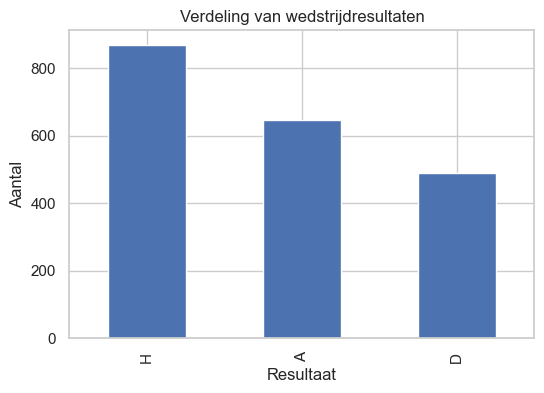

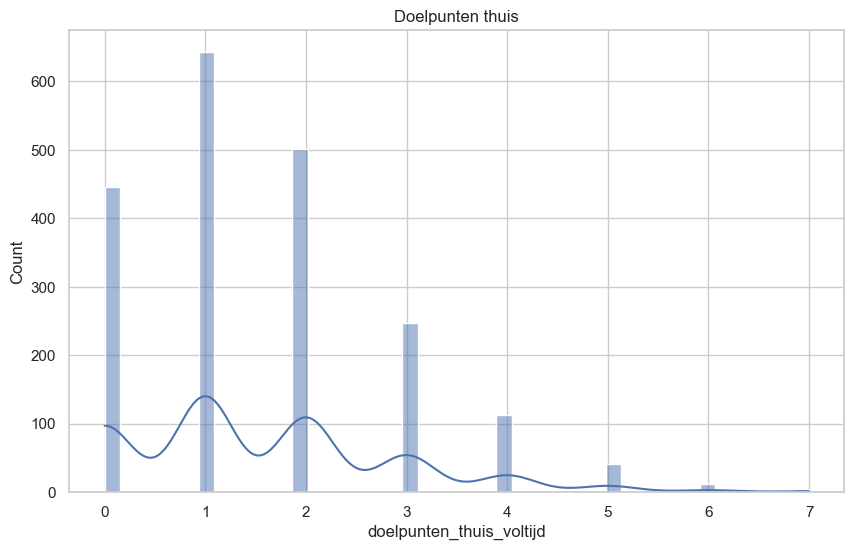

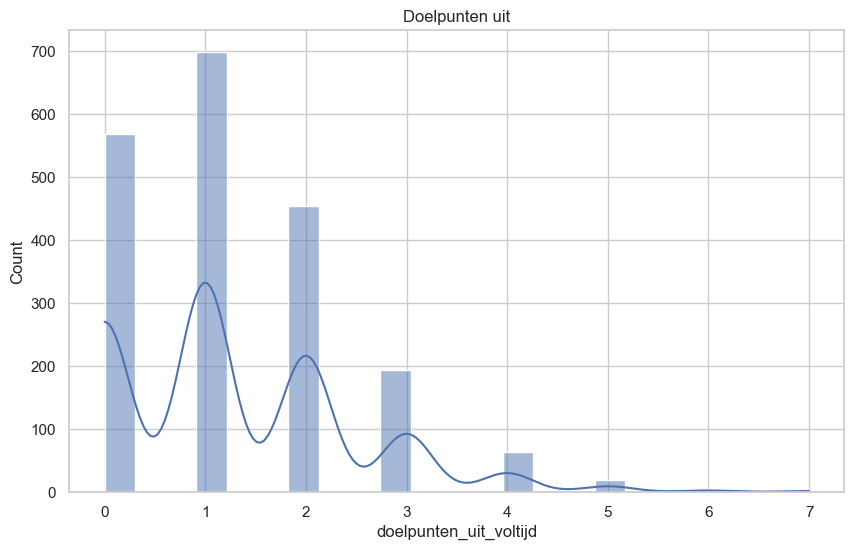

In [772]:
# Resultaat verdeling (H = thuis wint, D = draw, A = uit wint)
plt.figure(figsize=(6,4))
df['resultaat_voltijd'].value_counts().plot(kind='bar')
plt.title("Verdeling van wedstrijdresultaten")
plt.xlabel("Resultaat")
plt.ylabel("Aantal")
plt.show()

# Doelpunten distributie
plt.figure()
sns.histplot(df['doelpunten_thuis_voltijd'], kde=True)
plt.title("Doelpunten thuis")
plt.show()

plt.figure()
sns.histplot(df['doelpunten_uit_voltijd'], kde=True)
plt.title("Doelpunten uit")
plt.show()

### Match statistieken vs resultaat

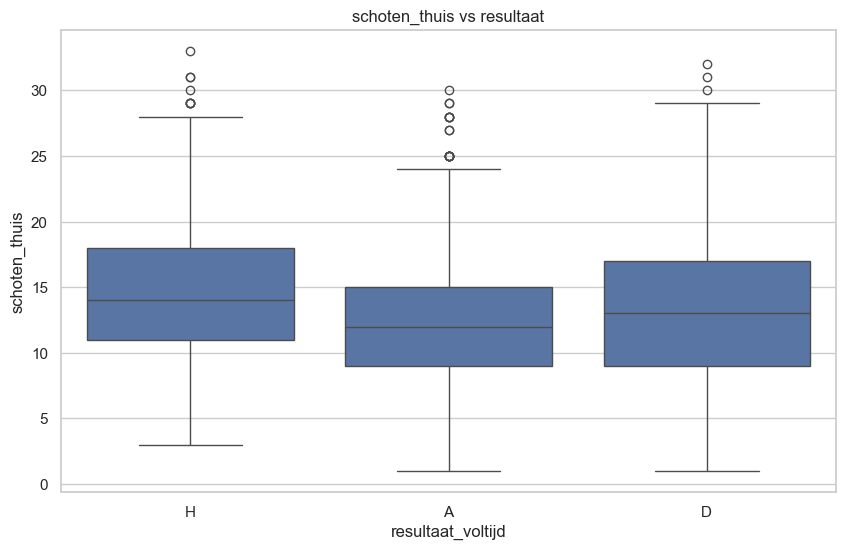

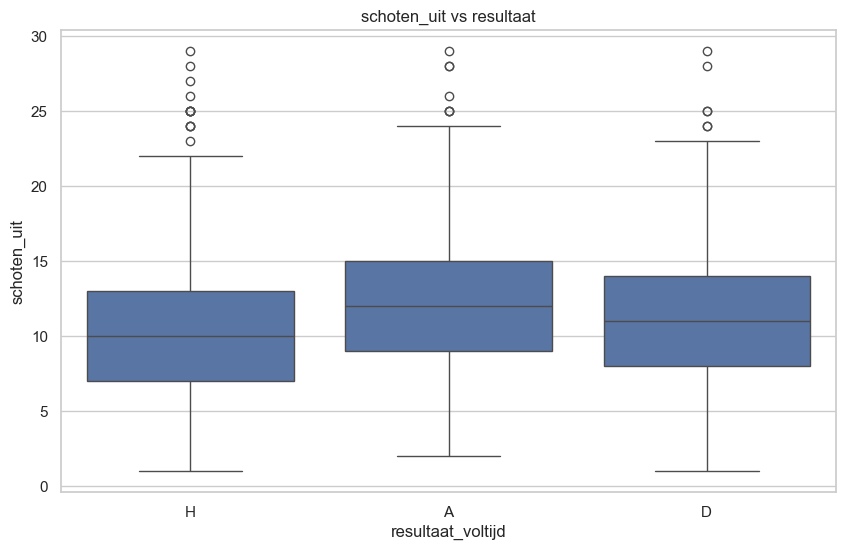

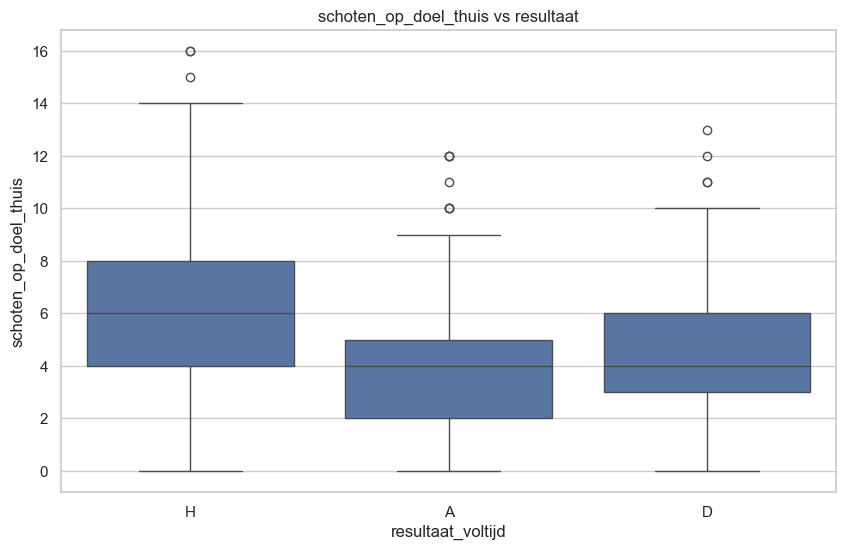

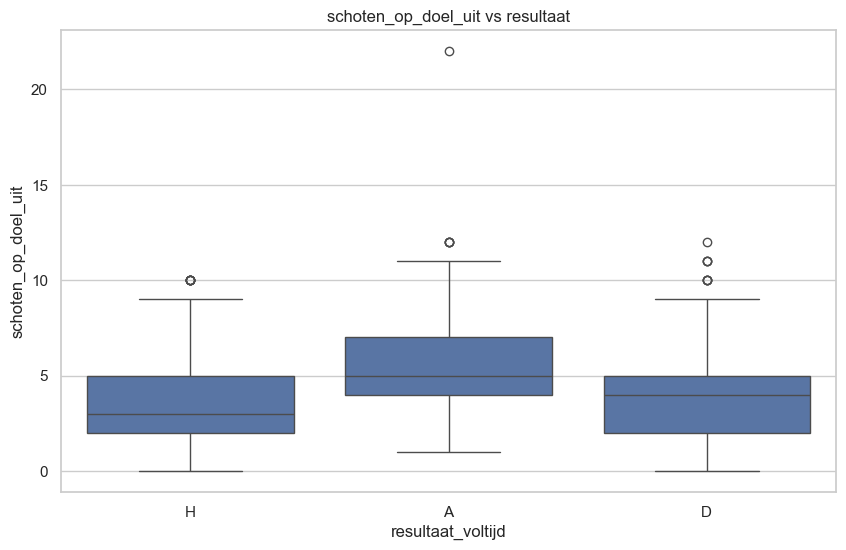

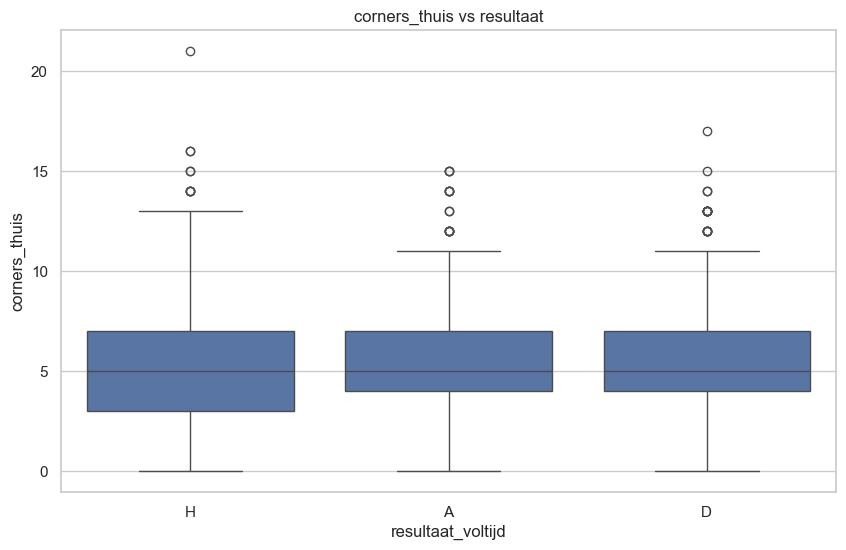

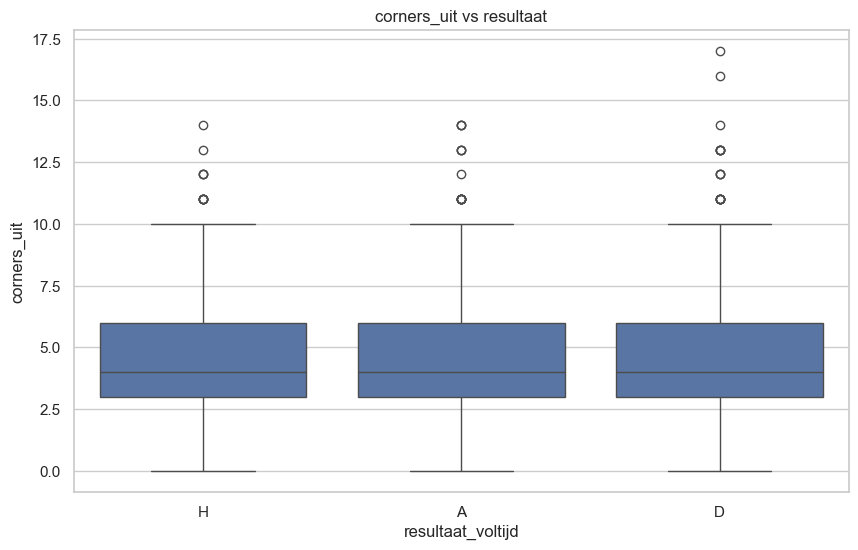

In [773]:
stats_cols = [
    'schoten_thuis', 'schoten_uit',
    'schoten_op_doel_thuis', 'schoten_op_doel_uit',
    'corners_thuis', 'corners_uit'
]

for col in stats_cols:
    plt.figure()
    sns.boxplot(x=df['resultaat_voltijd'], y=df[col])
    plt.title(f"{col} vs resultaat")
    plt.show()

### Ranking & form

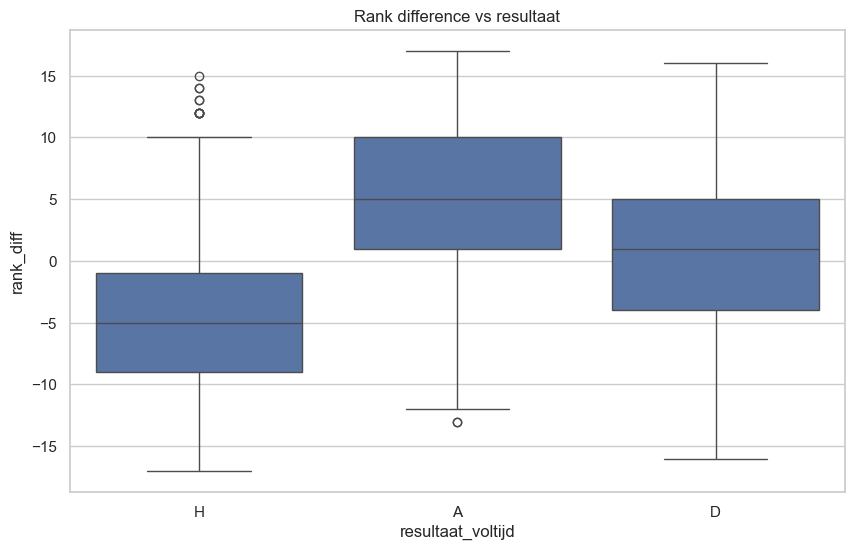

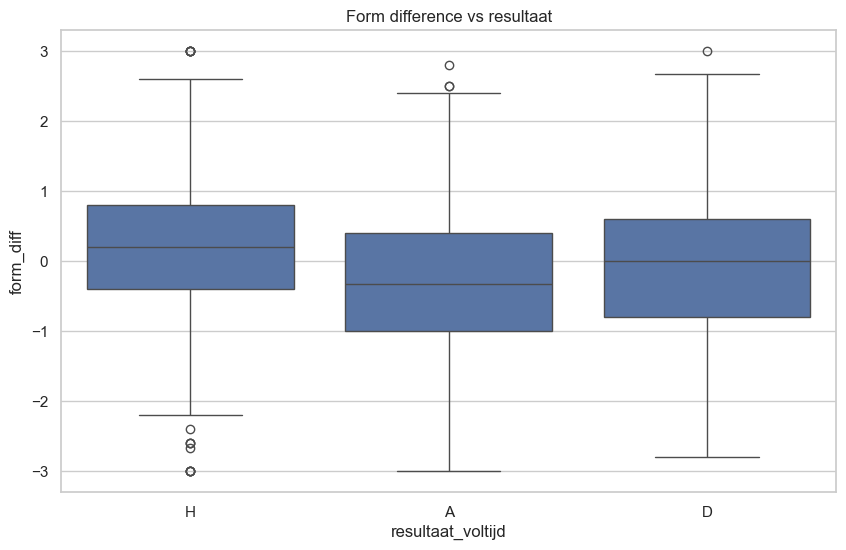

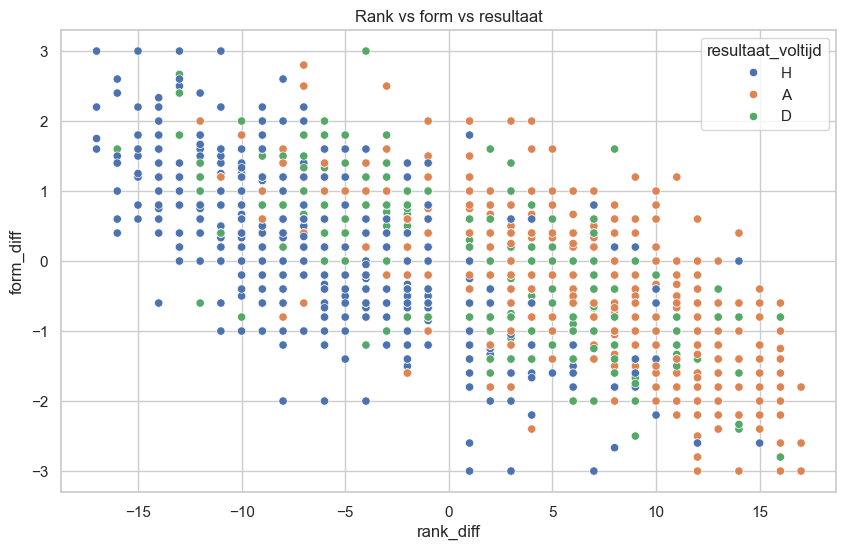

In [774]:
# Rank difference impact
sns.boxplot(x=df['resultaat_voltijd'], y=df['rank_diff'])
plt.title("Rank difference vs resultaat")
plt.show()

# Form difference impact
sns.boxplot(x=df['resultaat_voltijd'], y=df['form_diff'])
plt.title("Form difference vs resultaat")
plt.show()

# Scatter (extra inzicht)
sns.scatterplot(x=df['rank_diff'], y=df['form_diff'], hue=df['resultaat_voltijd'])
plt.title("Rank vs form vs resultaat")
plt.show()

### Weer-impact

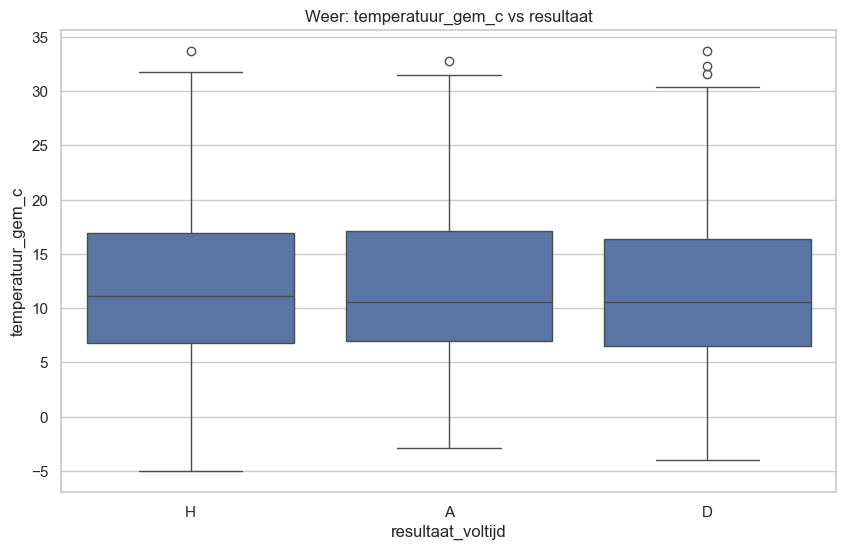

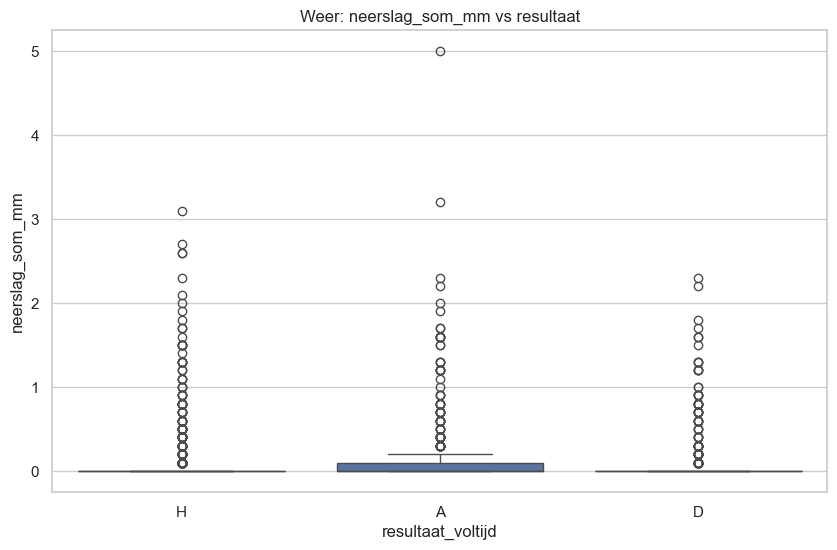

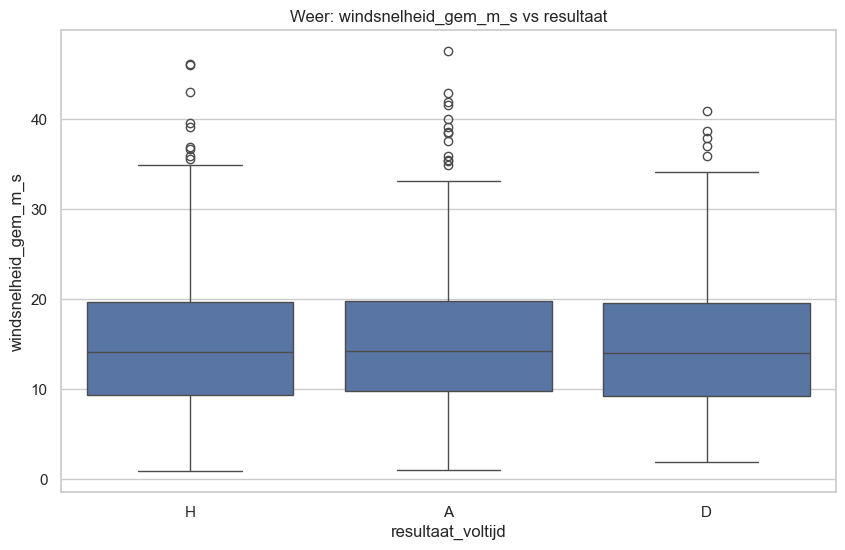

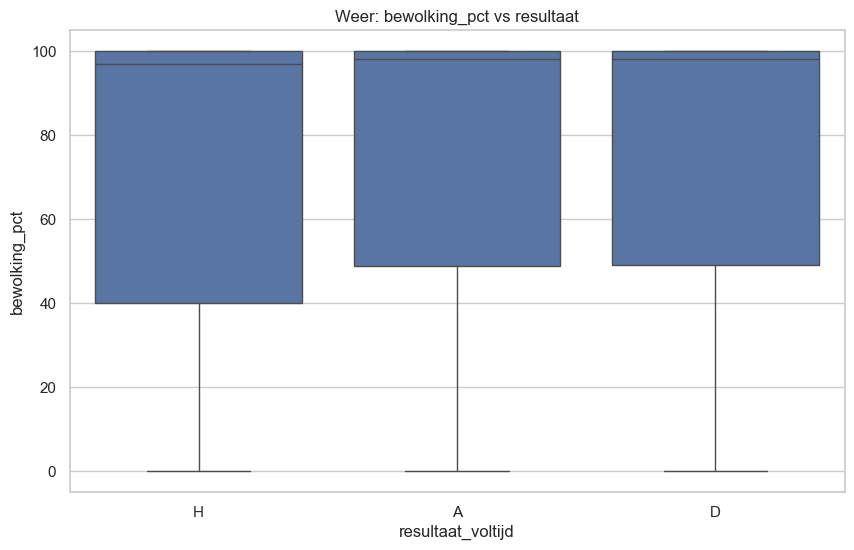

In [775]:
weather_cols = [
    'temperatuur_gem_c', 'neerslag_som_mm',
    'windsnelheid_gem_m_s', 'bewolking_pct'
]

for col in weather_cols:
    plt.figure()
    sns.boxplot(x=df['resultaat_voltijd'], y=df[col])
    plt.title(f"Weer: {col} vs resultaat")
    plt.show()

resultaat_voltijd,A,D,H
regen,,,
0,0.315929,0.252479,0.431593
1,0.344828,0.217039,0.438134


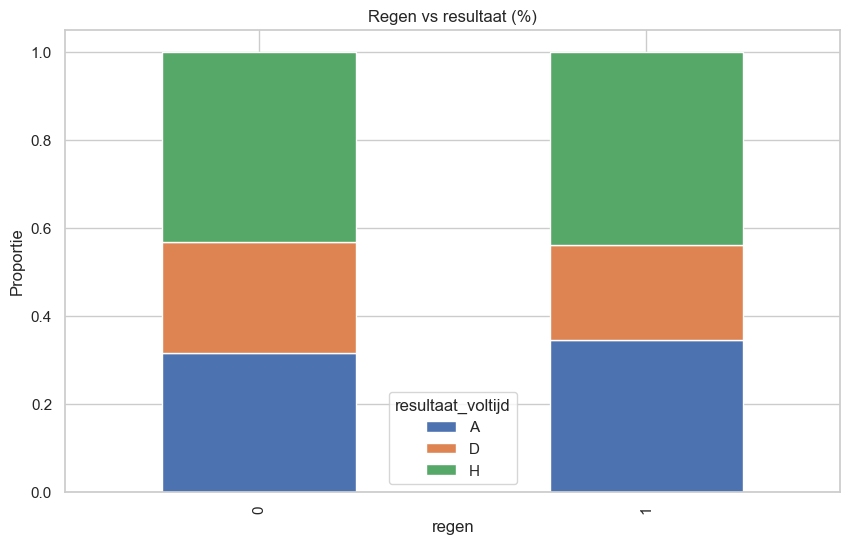

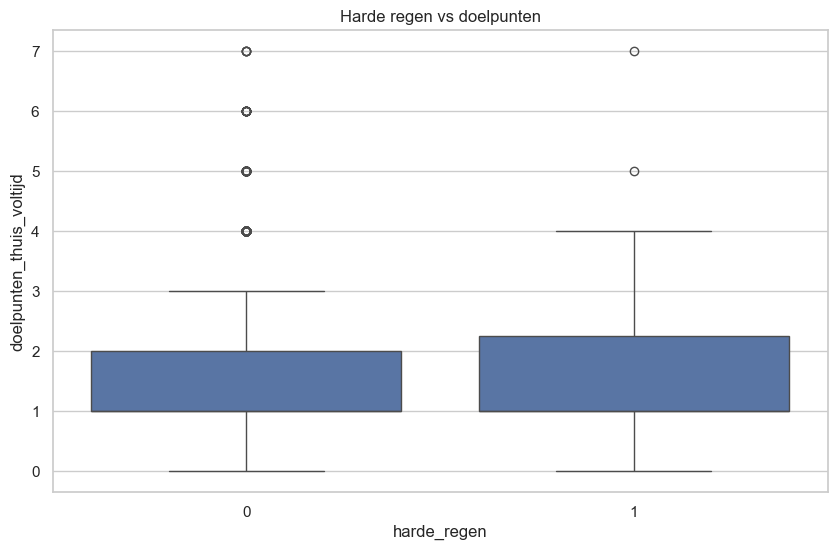

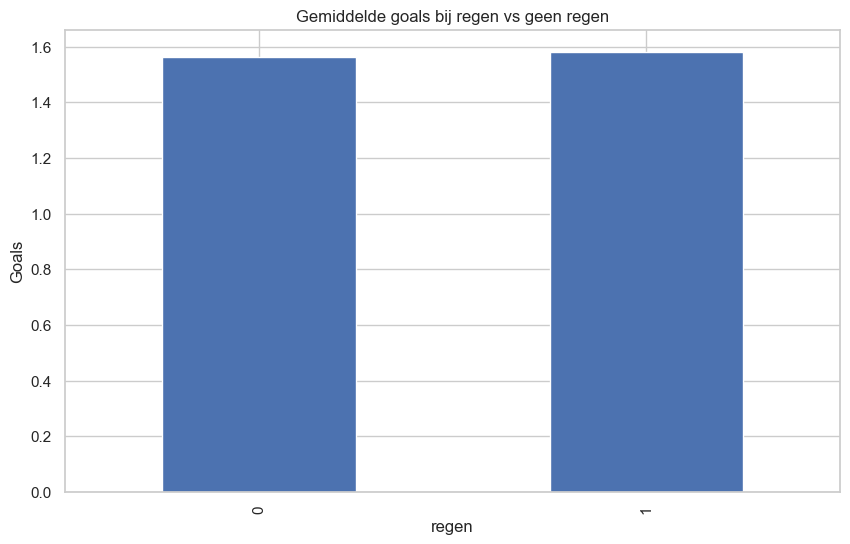

In [776]:
# Kruistabel met percentages
regen_resultaat = pd.crosstab(df['regen'], df['resultaat_voltijd'], normalize='index')

display(regen_resultaat)

# Plot
regen_resultaat.plot(kind='bar', stacked=True)
plt.title("Regen vs resultaat (%)")
plt.ylabel("Proportie")
plt.show()

sns.boxplot(x=df['harde_regen'], y=df['doelpunten_thuis_voltijd'])
plt.title("Harde regen vs doelpunten")
plt.show()

df.groupby('regen')['doelpunten_thuis_voltijd'].mean().plot(kind='bar')
plt.title("Gemiddelde goals bij regen vs geen regen")
plt.ylabel("Goals")
plt.show()

### Thuisvoordeel

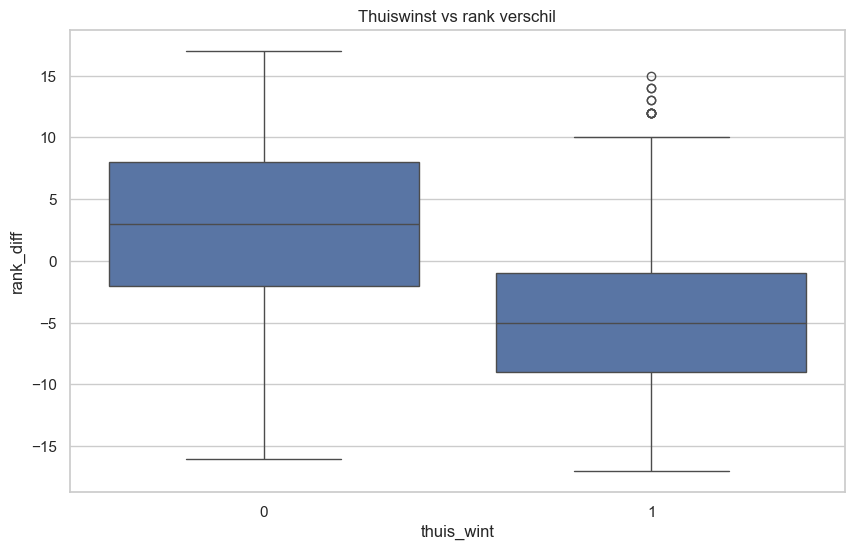

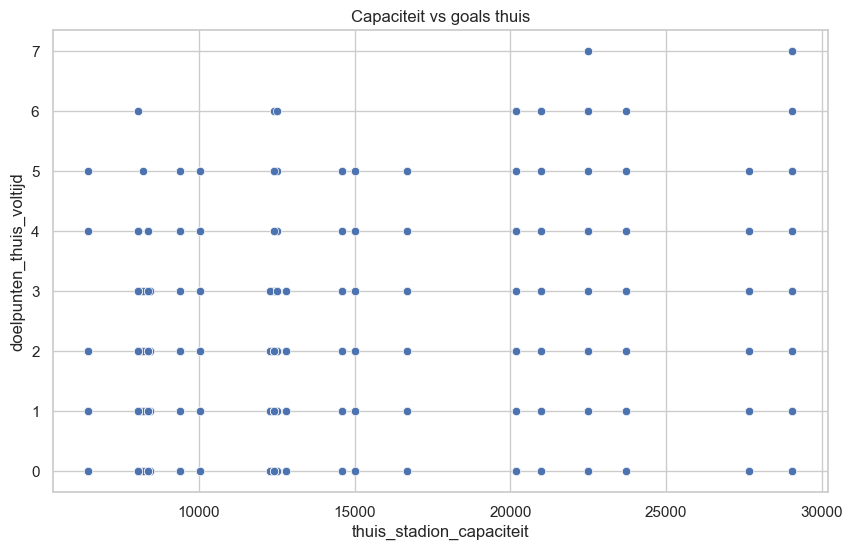

In [777]:
# Rank verschil vs thuiswinst
df['thuis_wint'] = (df['resultaat_voltijd'] == 'H').astype(int)

sns.boxplot(x=df['thuis_wint'], y=df['rank_diff'])
plt.title("Thuiswinst vs rank verschil")
plt.show()

# Stadioncapaciteit
sns.scatterplot(x=df['thuis_stadion_capaciteit'], y=df['doelpunten_thuis_voltijd'])
plt.title("Capaciteit vs goals thuis")
plt.show()

### Tijd & kalender

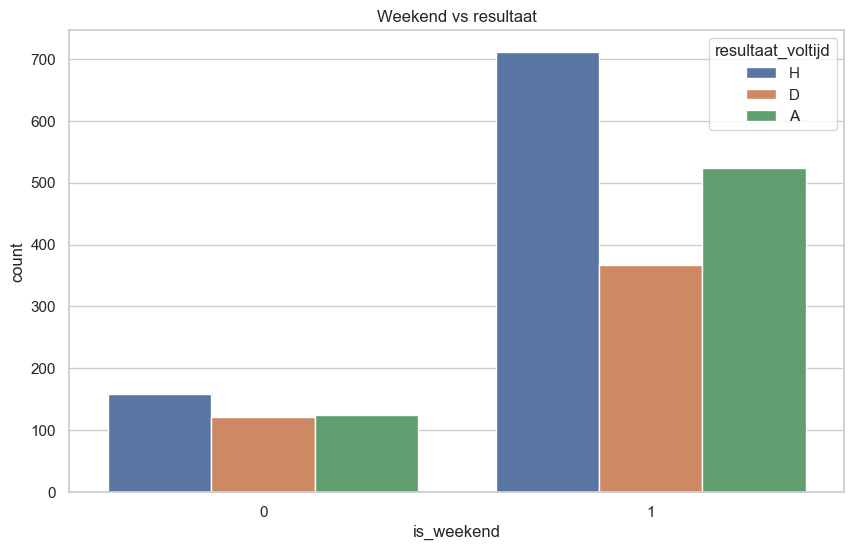

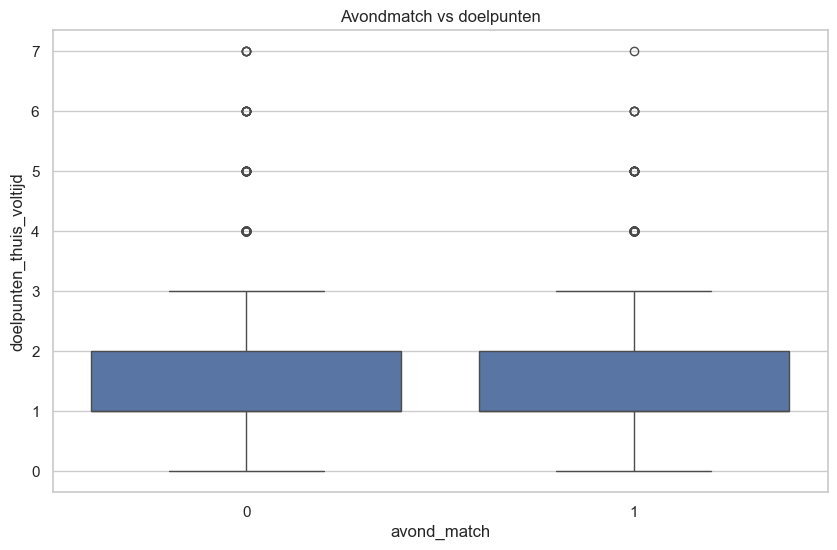

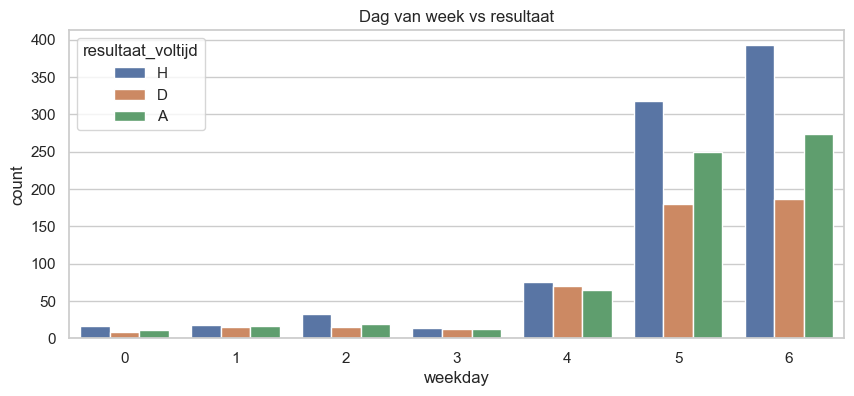

In [778]:
# Weekend effect
sns.countplot(x=df['is_weekend'], hue=df['resultaat_voltijd'])
plt.title("Weekend vs resultaat")
plt.show()

# Avondmatch
sns.boxplot(x=df['avond_match'], y=df['doelpunten_thuis_voltijd'])
plt.title("Avondmatch vs doelpunten")
plt.show()

# Weekday
plt.figure(figsize=(10,4))
sns.countplot(x=df['weekday'], hue=df['resultaat_voltijd'])
plt.title("Dag van week vs resultaat")
plt.show()

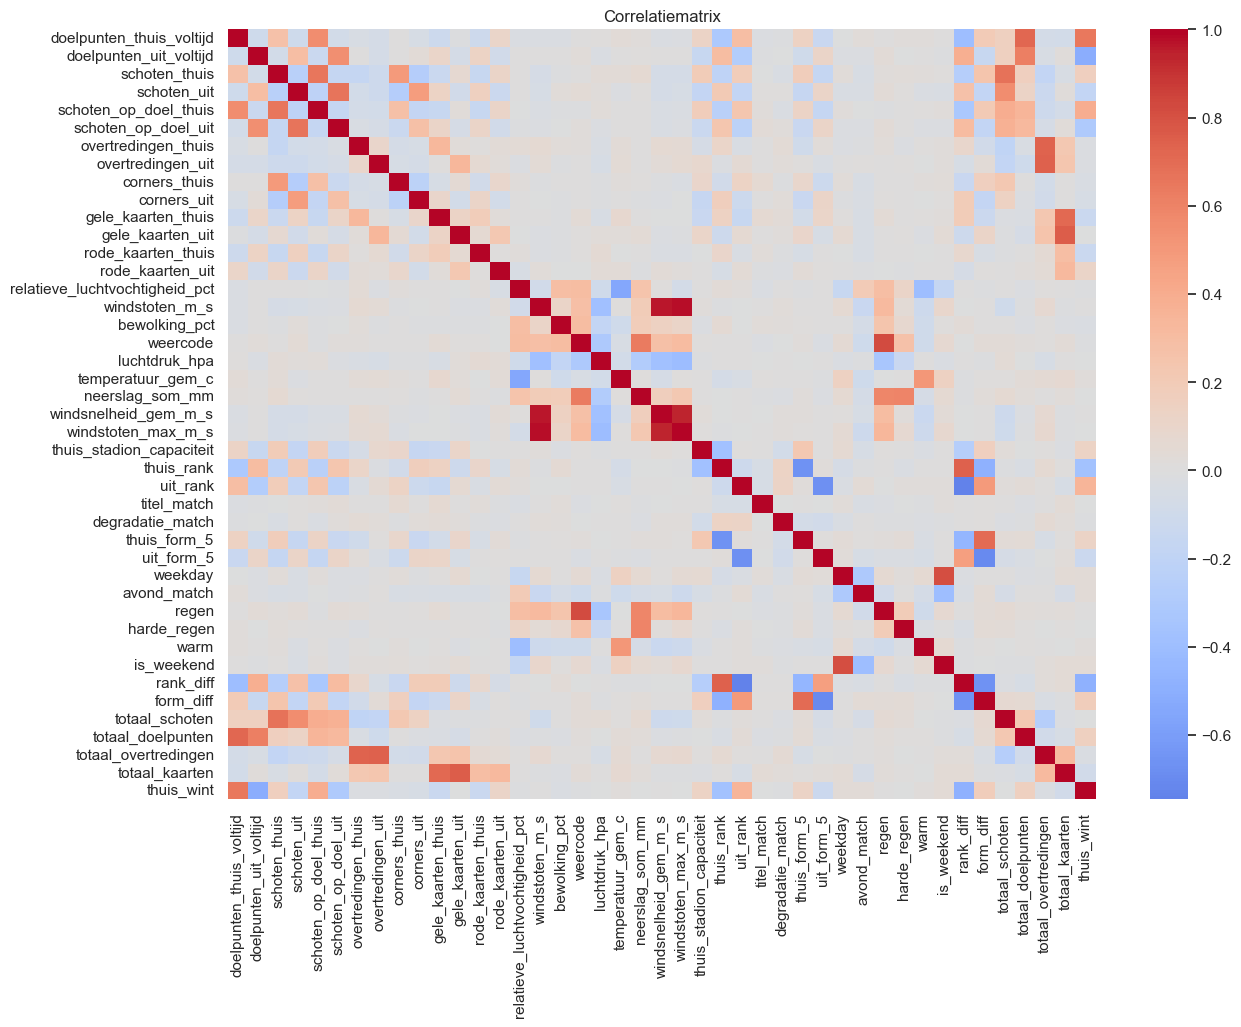

In [779]:
plt.figure(figsize=(14,10))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlatiematrix")
plt.show()

### Hoe belangrijk is het thuisvoordeel bij het voorspellen van winst/verlies?

Aantal wedstrijden per resultaat (H/A/D):
resultaat_voltijd
H    869
A    648
D    489
Name: count, dtype: int64

Thuisoverwinningen: 869
Uitoverwinningen: 648
Gelijke spelen: 489

Percentage resultaten:
Thuiswinst: 43.32%
Uitwinst: 32.30%
Gelijk: 24.38%

Chi-kwadraat test voor thuisvoordeel:
Chi²-statistiek: 108.93
P-waarde: 2.2143e-24
✅ Conclusie: Thuisvoordeel heeft een SIGNIFICANTE invloed.


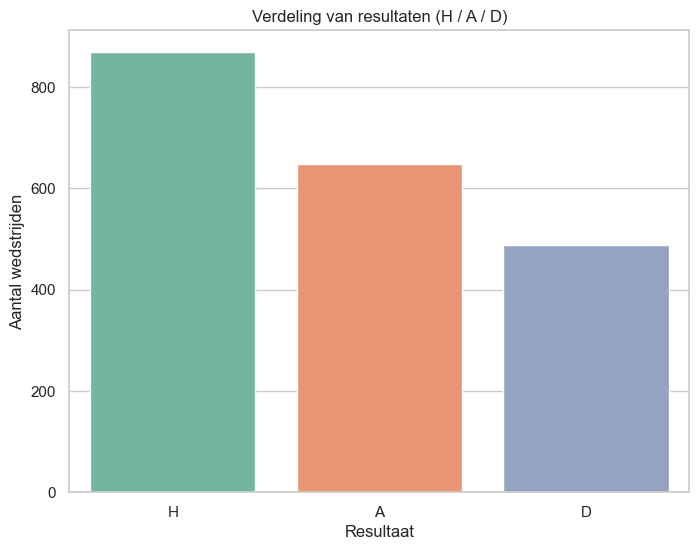

In [780]:

# 1️⃣ Totaal aantal wedstrijden per resultaat
resultaten = df['resultaat_voltijd'].value_counts()
print("Aantal wedstrijden per resultaat (H/A/D):")
print(resultaten)

# 2️⃣ Aantal thuis-, uitoverwinningen en gelijke spelen
thuis_overwinningen = (df['resultaat_voltijd'] == 'H').sum()
uit_overwinningen = (df['resultaat_voltijd'] == 'A').sum()
gelijk = (df['resultaat_voltijd'] == 'D').sum()

print(f"\nThuisoverwinningen: {thuis_overwinningen}")
print(f"Uitoverwinningen: {uit_overwinningen}")
print(f"Gelijke spelen: {gelijk}")

# 3️⃣ Percentages
totaal = len(df)
print("\nPercentage resultaten:")
print(f"Thuiswinst: {thuis_overwinningen/totaal*100:.2f}%")
print(f"Uitwinst: {uit_overwinningen/totaal*100:.2f}%")
print(f"Gelijk: {gelijk/totaal*100:.2f}%")

# 4️⃣ Chi-kwadraat test (heeft thuisvoordeel invloed?)
# H0: H, A en D komen even vaak voor (geen thuisvoordeel)

observed = [thuis_overwinningen, uit_overwinningen, gelijk]
expected = [totaal/3] * 3

chi2_stat, p_value = chisquare(observed, expected)

print("\nChi-kwadraat test voor thuisvoordeel:")
print(f"Chi²-statistiek: {chi2_stat:.2f}")
print(f"P-waarde: {p_value:.4e}")

if p_value < 0.05:
    print("✅ Conclusie: Thuisvoordeel heeft een SIGNIFICANTE invloed.")
else:
    print("❌ Conclusie: Geen significant thuisvoordeel gevonden.")

# 5️⃣ Visualisatie
plt.figure(figsize=(8,6))
sns.countplot(x='resultaat_voltijd', data=df, palette='Set2')
plt.title("Verdeling van resultaten (H / A / D)")
plt.xlabel("Resultaat")
plt.ylabel("Aantal wedstrijden")
plt.show()


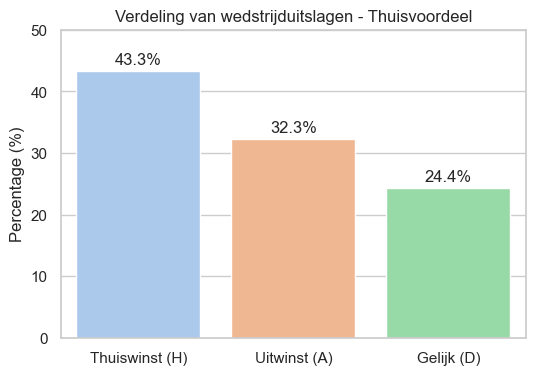

In [781]:
# Percentages berekenen
total = 869 + 648 + 489
percentages = {
    'Thuiswinst (H)': 869/total*100,
    'Uitwinst (A)': 648/total*100,
    'Gelijk (D)': 489/total*100
}

# Barplot
plt.figure(figsize=(6,4))
sns.barplot(x=list(percentages.keys()), y=list(percentages.values()), palette="pastel")
plt.ylabel("Percentage (%)")
plt.title("Verdeling van wedstrijduitslagen - Thuisvoordeel")
plt.ylim(0, 50)
for i, v in enumerate(percentages.values()):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')
plt.show()

### In welke mate beïnvloedt stadioncapaciteit het totaal aantal schoten in een wedstrijd?  

Gemiddeld totaal aantal schoten per stadioncapaciteit-categorie:
capaciteit_cat
Klein     24.701513
Middel    24.663730
Groot     25.061873
Name: totaal_schoten, dtype: float64


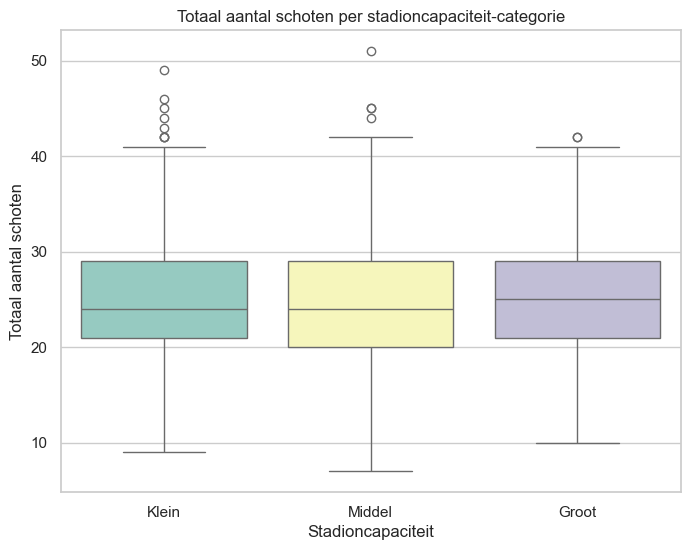

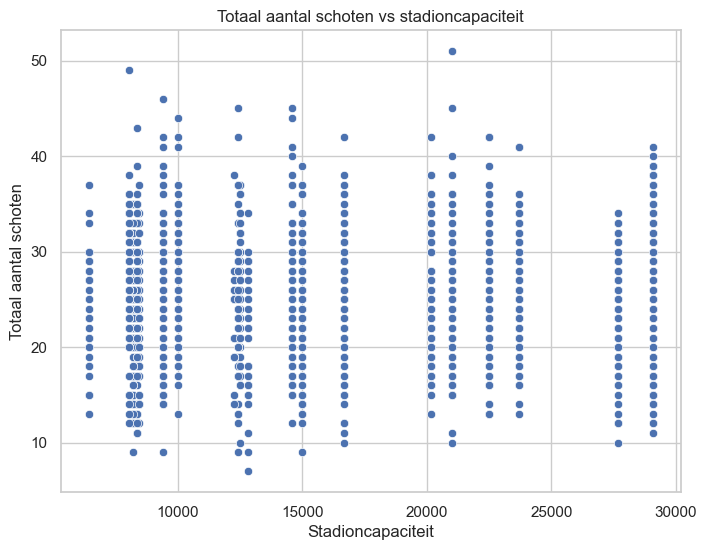

Pearson correlatie: 0.031
P-waarde: 1.7032e-01
👉 Geen significant verband gevonden tussen stadioncapaciteit en totaal aantal schoten.


In [782]:
# 1️⃣ Totaal aantal schoten per wedstrijd (thuis + uit)
df['totaal_schoten'] = df['schoten_thuis'] + df['schoten_uit']

gemiddelde_per_cat = df.groupby('capaciteit_cat')['totaal_schoten'].mean()
print("Gemiddeld totaal aantal schoten per stadioncapaciteit-categorie:")
print(gemiddelde_per_cat)

# 3️⃣ Visualisatie: boxplot per categorie
plt.figure(figsize=(8,6))
sns.boxplot(x='capaciteit_cat', y='totaal_schoten', data=df, palette='Set3')
plt.title("Totaal aantal schoten per stadioncapaciteit-categorie")
plt.xlabel("Stadioncapaciteit")
plt.ylabel("Totaal aantal schoten")
plt.show()

# 4️⃣ Scatterplot en correlatie (numeriek)
plt.figure(figsize=(8,6))
sns.scatterplot(x='thuis_stadion_capaciteit', y='totaal_schoten', data=df)
plt.title("Totaal aantal schoten vs stadioncapaciteit")
plt.xlabel("Stadioncapaciteit")
plt.ylabel("Totaal aantal schoten")
plt.show()

# Pearson correlatie
corr, p_value = pearsonr(df['thuis_stadion_capaciteit'], df['totaal_schoten'])
print(f"Pearson correlatie: {corr:.3f}")
print(f"P-waarde: {p_value:.4e}")

if p_value < 0.05:
    print("👉 Er is een statistisch significant verband tussen stadioncapaciteit en totaal aantal schoten.")
else:
    print("👉 Geen significant verband gevonden tussen stadioncapaciteit en totaal aantal schoten.")

### In welke mate beïnvloedt stadioncapaciteit het aantal overtredingen van het uitteam?  

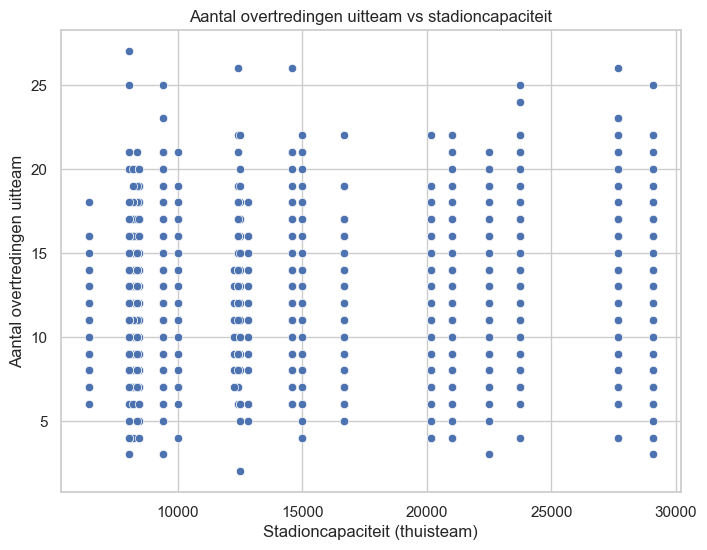

Gemiddeld aantal overtredingen uitteam per stadioncapaciteit-categorie:
capaciteit_cat
Klein     12.200825
Middel    11.687225
Groot     12.984950
Name: overtredingen_uit, dtype: float64


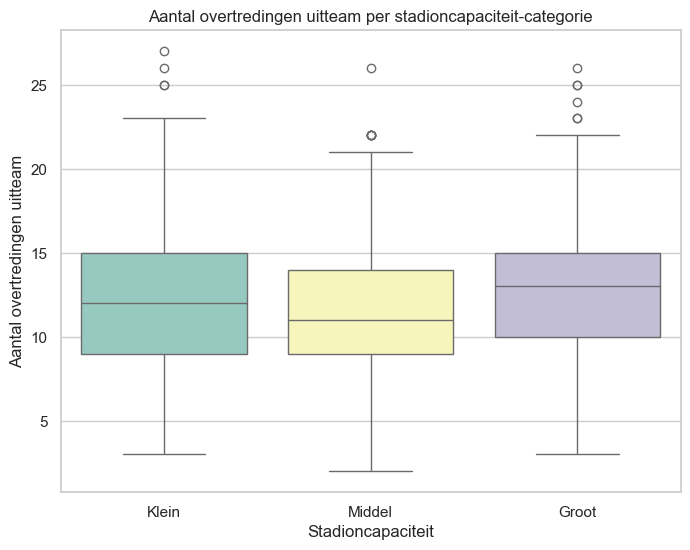

Pearson correlatie: 0.079
P-waarde: 3.6602e-04
👉 Er is een statistisch significant verband tussen stadioncapaciteit en overtredingen van het uitteam.


In [783]:
# 1️⃣ Scatterplot: overtredingen uitteam vs stadioncapaciteit
plt.figure(figsize=(8,6))
sns.scatterplot(x='thuis_stadion_capaciteit', y='overtredingen_uit', data=df)
plt.title("Aantal overtredingen uitteam vs stadioncapaciteit")
plt.xlabel("Stadioncapaciteit (thuisteam)")
plt.ylabel("Aantal overtredingen uitteam")
plt.show()

# 2️⃣ Gemiddelde overtredingen per categorie stadioncapaciteit
# Maak bins: klein / middel / groot
df['capaciteit_cat'] = pd.qcut(df['thuis_stadion_capaciteit'], q=3, labels=['Klein','Middel','Groot'])

gemiddelde_per_cat = df.groupby('capaciteit_cat')['overtredingen_uit'].mean()
print("Gemiddeld aantal overtredingen uitteam per stadioncapaciteit-categorie:")
print(gemiddelde_per_cat)

# 3️⃣ Boxplot per categorie
plt.figure(figsize=(8,6))
sns.boxplot(x='capaciteit_cat', y='overtredingen_uit', data=df, palette='Set3')
plt.title("Aantal overtredingen uitteam per stadioncapaciteit-categorie")
plt.xlabel("Stadioncapaciteit")
plt.ylabel("Aantal overtredingen uitteam")
plt.show()

# 4️⃣ Correlatie (Pearson)
corr, p_value = pearsonr(df['thuis_stadion_capaciteit'], df['overtredingen_uit'])
print(f"Pearson correlatie: {corr:.3f}")
print(f"P-waarde: {p_value:.4e}")

if p_value < 0.05:
    print("👉 Er is een statistisch significant verband tussen stadioncapaciteit en overtredingen van het uitteam.")
else:
    print("👉 Geen significant verband gevonden tussen stadioncapaciteit en overtredingen van het uitteam.")

### Heeft regen invloed op het aantal doelpunten?

Gemiddeld aantal doelpunten bij regen: 2.94
Gemiddeld aantal doelpunten zonder regen: 2.83


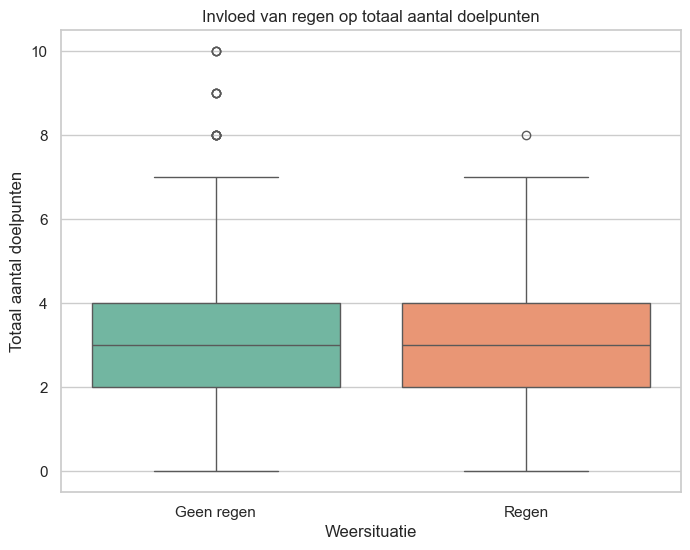

T-test p-waarde: 1.7900e-01
👉 Geen significant effect van regen op het aantal doelpunten.


In [784]:
# 1️⃣ Totaal aantal doelpunten per wedstrijd
df['totaal_goals'] = df['doelpunten_thuis_voltijd'] + df['doelpunten_uit_voltijd']

# 2️⃣ Subsets: met regen vs zonder regen
met_regen = df[df['regen'] == 1]['totaal_goals']
zonder_regen = df[df['regen'] == 0]['totaal_goals']

# 3️⃣ Gemiddelde doelpunten
gemiddelde_met_regen = met_regen.mean()
gemiddelde_zonder_regen = zonder_regen.mean()

print(f"Gemiddeld aantal doelpunten bij regen: {gemiddelde_met_regen:.2f}")
print(f"Gemiddeld aantal doelpunten zonder regen: {gemiddelde_zonder_regen:.2f}")

# 4️⃣ Visualisatie
plt.figure(figsize=(8,6))
sns.boxplot(x=df['regen'].map({0:"Geen regen", 1:"Regen"}), y=df['totaal_goals'], palette="Set2")
plt.title("Invloed van regen op totaal aantal doelpunten")
plt.xlabel("Weersituatie")
plt.ylabel("Totaal aantal doelpunten")
plt.show()

# 5️⃣ Statistische toets (t-test)
t_stat, p_value = ttest_ind(met_regen.dropna(), zonder_regen.dropna(), equal_var=False)
print(f"T-test p-waarde: {p_value:.4e}")

if p_value < 0.05:
    print("👉 Regen heeft een statistisch significante invloed op het aantal doelpunten.")
else:
    print("👉 Geen significant effect van regen op het aantal doelpunten.")

### In welke mate verwacht u dat regen het aantal kaarten in een wedstrijd beïnvloedt?

Gemiddeld aantal kaarten bij regen: 4.23
Gemiddeld aantal kaarten zonder regen: 4.10


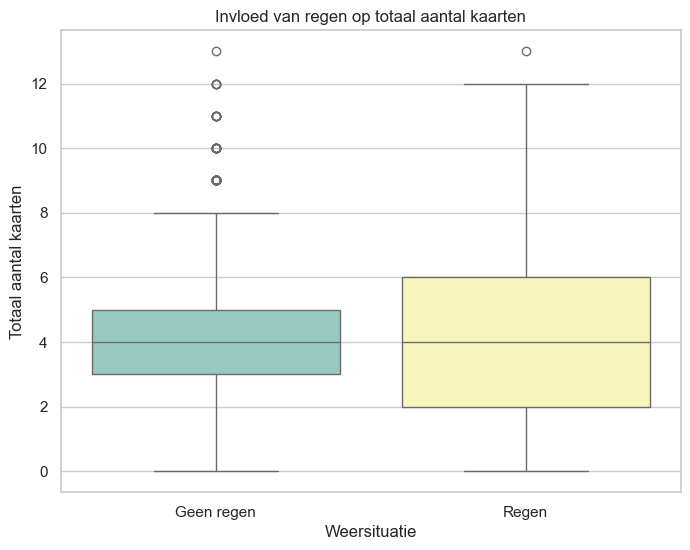

T-test p-waarde: 2.6602e-01
👉 Geen significant effect van regen op het aantal kaarten.


In [785]:
# 1️⃣ Totaal aantal kaarten per wedstrijd
df['totaal_kaarten'] = df['gele_kaarten_thuis'] + df['gele_kaarten_uit'] + \
                       df['rode_kaarten_thuis'] + df['rode_kaarten_uit']

# 2️⃣ Subsets: wedstrijden met regen vs zonder regen
kaarten_met_regen = df[df['regen'] == 1]['totaal_kaarten']
kaarten_zonder_regen = df[df['regen'] == 0]['totaal_kaarten']

# 3️⃣ Gemiddelden
gem_met_regen = kaarten_met_regen.mean()
gem_zonder_regen = kaarten_zonder_regen.mean()

print(f"Gemiddeld aantal kaarten bij regen: {gem_met_regen:.2f}")
print(f"Gemiddeld aantal kaarten zonder regen: {gem_zonder_regen:.2f}")

# 4️⃣ Visualisatie
plt.figure(figsize=(8,6))
sns.boxplot(x=df['regen'].map({0:"Geen regen", 1:"Regen"}), y=df['totaal_kaarten'], palette="Set3")
plt.title("Invloed van regen op totaal aantal kaarten")
plt.xlabel("Weersituatie")
plt.ylabel("Totaal aantal kaarten")
plt.show()

# 5️⃣ Statistische toets (t-test)
t_stat, p_value = ttest_ind(kaarten_met_regen.dropna(), kaarten_zonder_regen.dropna(), equal_var=False)
print(f"T-test p-waarde: {p_value:.4e}")

if p_value < 0.05:
    print("👉 Regen heeft een statistisch significante invloed op het aantal kaarten.")
else:
    print("👉 Geen significant effect van regen op het aantal kaarten.")

### Hoe bepalend is recente vorm (laatste 5 wedstrijden) voor het resultaat?

Kans op thuiswinst per vormcategorie:
uit_form_cat    Goed  Normaal  Slecht
thuis_form_cat                       
Goed            0.47     0.53    0.57
Normaal         0.28     0.47    0.51
Slecht          0.31     0.38    0.41


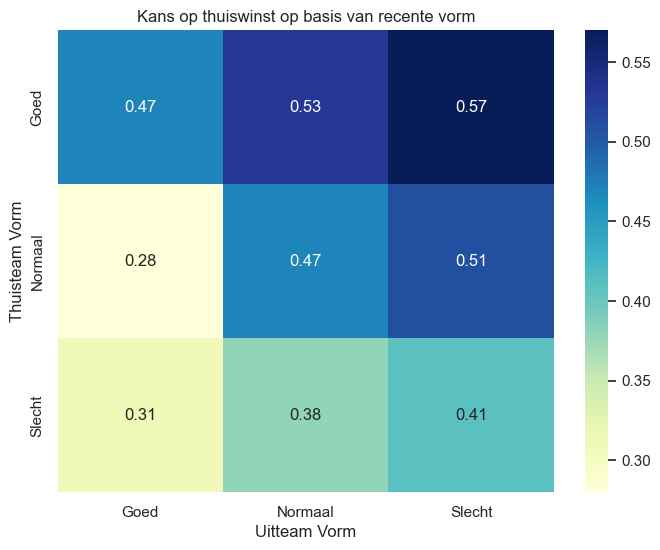


Chi²-statistiek: 67.31
P-waarde: 1.6797e-11
✅ Recente vorm is SIGNIFICANT bepalend


In [786]:
# Categorisatie (NaN blijft NaN)
def categorize_form(x):
    if pd.isna(x):
        return np.nan
    elif x < 1:
        return 'Slecht'
    elif x < 1.7:
        return 'Normaal'
    else:
        return 'Goed'

df['thuis_form_cat'] = df['thuis_form_5'].apply(categorize_form)
df['uit_form_cat'] = df['uit_form_5'].apply(categorize_form)

# Drop rijen zonder vorm (begin seizoen)
df_analysis = df.dropna(subset=['thuis_form_cat','uit_form_cat'])

# Thuis wint kolom
df_analysis['thuis_wint'] = (df_analysis['resultaat_voltijd'] == 'H').astype(int)

# Crosstab (kans op thuiswinst)
crosstab = pd.crosstab(
    df_analysis['thuis_form_cat'],
    df_analysis['uit_form_cat'],
    values=df_analysis['thuis_wint'],
    aggfunc='mean'
).round(2)

print("Kans op thuiswinst per vormcategorie:")
print(crosstab)

# Visualisatie
plt.figure(figsize=(8,6))
sns.heatmap(crosstab, annot=True, fmt=".2f", cmap='YlGnBu')
plt.title("Kans op thuiswinst op basis van recente vorm")
plt.xlabel("Uitteam Vorm")
plt.ylabel("Thuisteam Vorm")
plt.show()

# Chi-square test
count_table = pd.crosstab(
    [df_analysis['thuis_form_cat'], df_analysis['uit_form_cat']],
    df_analysis['thuis_wint']
)

chi2_stat, p_val, dof, expected = chi2_contingency(count_table)

print(f"\nChi²-statistiek: {chi2_stat:.2f}")
print(f"P-waarde: {p_val:.4e}")

if p_val < 0.05:
    print("✅ Recente vorm is SIGNIFICANT bepalend")
else:
    print("❌ Geen significant effect")

### Hoe belangrijk is het verschil in het klassement voor het voorspellen van een wedstrijd?

Gemiddelde kans op winst van thuisteam per rankverschil categorie:
  rank_diff_cat  thuis_wint
0          <-10    0.842105
1        -10--5    0.659026
2         -5--2    0.536977
3          -2-0    0.447761
4           0-2    0.328947
5           2-5    0.229839
6          5-10    0.198697
7           >10    0.060440


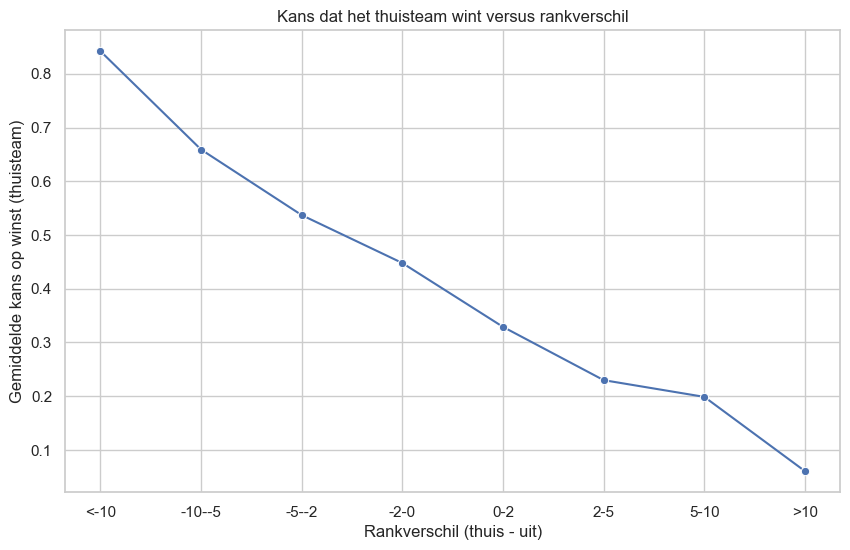


Chi-square test voor invloed van rankverschil op thuisresultaat:
Chi²-statistiek: 478.06, p-waarde: 4.1741e-99
✅ Conclusie: Rangverschil heeft een SIGNIFICANTE invloed op het wedstrijdresultaat.


In [787]:
# 1️⃣ Categoriseer resultaten: 1 = thuis wint, 0 = anders
df['thuis_wint'] = df['resultaat_voltijd'].apply(lambda x: 1 if x=='H' else 0)

# 2️⃣ Bin rank_diff volgens nieuwe grenzen
bins = [-100, -10, -5, -2, 0, 2, 5, 10, 100]  # extra uitersten om alles te vangen
labels = ['<-10','-10--5','-5--2','-2-0','0-2','2-5','5-10','>10']
df['rank_diff_cat'] = pd.cut(df['rank_diff'], bins=bins, labels=labels)

# 3️⃣ Gemiddelde kans op winst per rank_diff categorie
winst_per_cat = df.groupby('rank_diff_cat')['thuis_wint'].mean().reset_index()
print("Gemiddelde kans op winst van thuisteam per rankverschil categorie:")
print(winst_per_cat)

# 4️⃣ Visualisatie: lijnplot
plt.figure(figsize=(10,6))
sns.lineplot(data=winst_per_cat, x='rank_diff_cat', y='thuis_wint', marker='o')
plt.title("Kans dat het thuisteam wint versus rankverschil")
plt.xlabel("Rankverschil (thuis - uit)")
plt.ylabel("Gemiddelde kans op winst (thuisteam)")
plt.grid(True)
plt.show()

# 5️⃣ Chi-square test voor onafhankelijkheid
crosstab = pd.crosstab(df['rank_diff_cat'], df['thuis_wint'])
chi2_stat, p_val, dof, expected = chi2_contingency(crosstab)

print(f"\nChi-square test voor invloed van rankverschil op thuisresultaat:")
print(f"Chi²-statistiek: {chi2_stat:.2f}, p-waarde: {p_val:.4e}")

if p_val < 0.05:
    print("✅ Conclusie: Rangverschil heeft een SIGNIFICANTE invloed op het wedstrijdresultaat.")
else:
    print("❌ Conclusie: Rangverschil lijkt GEEN significant effect te hebben op het resultaat.")

### In welke mate hebben eerdere confrontaties invloed in uw voorspelling?

Percentage H2H correct: 38.63%

Crosstab (per H2H-favoriet, aandeel echte resultaten):
resultaat_voltijd         A         D         H
h2h_resultaat                                  
A                  0.415479  0.268839  0.315682
D                  0.334591  0.242767  0.422642
H                  0.247222  0.227778  0.525000

Crosstab (aantal wedstrijden per combinatie):
resultaat_voltijd    A    D    H
h2h_resultaat                   
A                  204  132  155
D                  266  193  336
H                  178  164  378


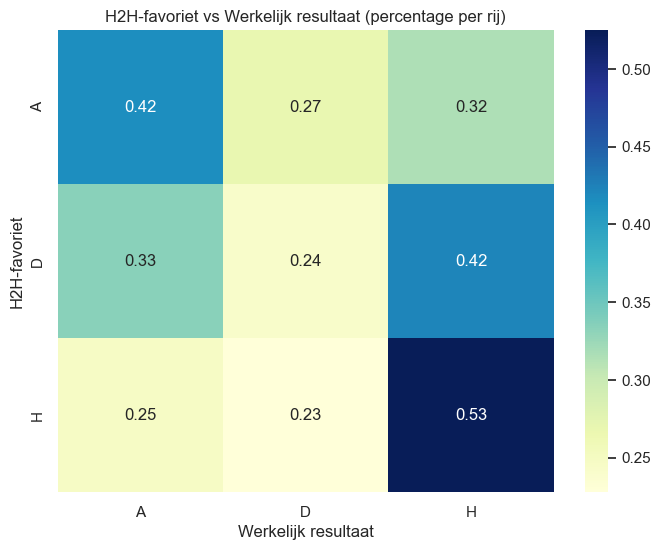


Aantal wedstrijden gewonnen door H2H-favoriet: 775 van 2006 (38.63%)


In [788]:
# 1️⃣ Maak een kolom die checkt of H2H-favoriet gelijk is aan de echte winnaar
df['h2h_correct'] = df['h2h_resultaat'] == df['resultaat_voltijd']

# 2️⃣ Percentage van wedstrijden waarbij H2H correct voorspelde
percentage_correct = df['h2h_correct'].mean() * 100
print(f"Percentage H2H correct: {percentage_correct:.2f}%")

# 3️⃣ Crosstab: H2H-resultaat vs echte resultaat (percen)
tabel_pct = pd.crosstab(df['h2h_resultaat'], df['resultaat_voltijd'], normalize='index')
print("\nCrosstab (per H2H-favoriet, aandeel echte resultaten):")
print(tabel_pct)

# 4️⃣ Crosstab: absoluut aantal keren
tabel_count = pd.crosstab(df['h2h_resultaat'], df['resultaat_voltijd'])
print("\nCrosstab (aantal wedstrijden per combinatie):")
print(tabel_count)

# 5️⃣ Visualisatie: heatmap percentage
plt.figure(figsize=(8,6))
sns.heatmap(tabel_pct, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("H2H-favoriet vs Werkelijk resultaat (percentage per rij)")
plt.ylabel("H2H-favoriet")
plt.xlabel("Werkelijk resultaat")
plt.show()

# 6️⃣ Extra: Hoe vaak wint H2H-favoriet?
h2h_wins = df[df['h2h_resultaat'] == df['resultaat_voltijd']]
h2h_wins_count = h2h_wins.shape[0]
total_matches = df.shape[0]
print(f"\nAantal wedstrijden gewonnen door H2H-favoriet: {h2h_wins_count} van {total_matches} ({h2h_wins_count/total_matches*100:.2f}%)")

### In welke mate verwacht u dat een hoger aantal schoten samenhangt met meer corners tijdens een wedstrijd?

Pearson correlatie tussen totaal schoten en totaal corners: 0.29
P-waarde: 6.6471e-40
👉 Er is een zwakke positieve samenhang tussen aantal schoten en corners.


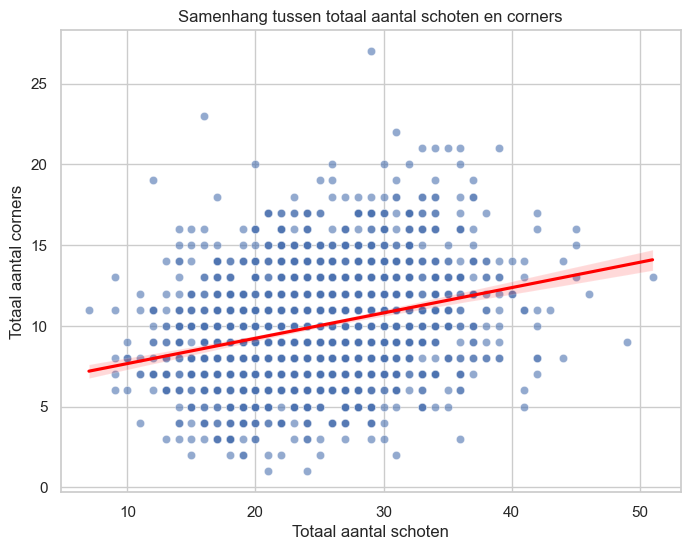

In [789]:
# 1️⃣ Totaal aantal schoten en corners per wedstrijd
df['totaal_schoten'] = df['schoten_thuis'] + df['schoten_uit']
df['totaal_corners'] = df['corners_thuis'] + df['corners_uit']

# 2️⃣ Correlatie berekenen (Pearson)
correlatie, p_value = pearsonr(df['totaal_schoten'], df['totaal_corners'])
print(f"Pearson correlatie tussen totaal schoten en totaal corners: {correlatie:.2f}")
print(f"P-waarde: {p_value:.4e}")

# 3️⃣ Interpretatie
if abs(correlatie) > 0.5:
    interpretatie = "sterke"
elif abs(correlatie) > 0.3:
    interpretatie = "matige"
else:
    interpretatie = "zwakke"

print(f"👉 Er is een {interpretatie} positieve samenhang tussen aantal schoten en corners.")

# 4️⃣ Visualisatie: scatterplot
plt.figure(figsize=(8,6))
sns.scatterplot(x='totaal_schoten', y='totaal_corners', data=df, alpha=0.6)
sns.regplot(x='totaal_schoten', y='totaal_corners', data=df, scatter=False, color='red')
plt.title("Samenhang tussen totaal aantal schoten en corners")
plt.xlabel("Totaal aantal schoten")
plt.ylabel("Totaal aantal corners")
plt.show()

### Stadioncapaciteit → overtredingen uitteam

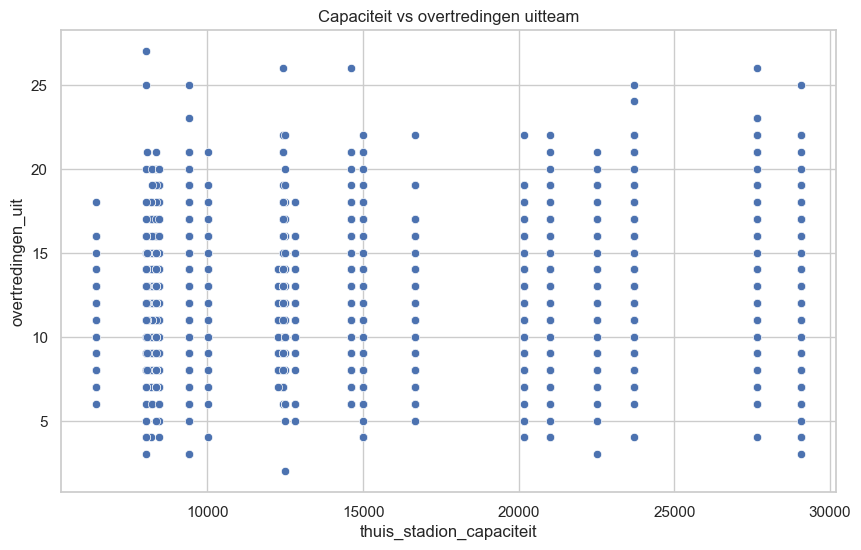

Correlatie: 0.0794854428013269


In [790]:
sns.scatterplot(x=df['thuis_stadion_capaciteit'], y=df['overtredingen_uit'])
plt.title("Capaciteit vs overtredingen uitteam")
plt.show()

print("Correlatie:", df['thuis_stadion_capaciteit'].corr(df['overtredingen_uit']))

### Als het thuisteam een aanvallende speelstijl hanteert en het uitteam defensief speelt zullen er gemiddeld meer/zelfde/minder doelpunten vallen.

Gemiddeld aantal goals (Aanvallend vs Verdedigend): 3.23
Algemeen gemiddelde aantal goals: 2.86
👉 In deze situatie vallen gemiddeld meer doelpunten.

Gemiddeld aantal goals per speelstijl-combinatie:
speelstijl_combo
Aanvallend_vs_Aanvallend        2.650943
Gebalanceerd_vs_Gebalanceerd    2.700000
Gebalanceerd_vs_Aanvallend      2.709030
Verdedigend_vs_Gebalanceerd     2.780822
Gebalanceerd_vs_Verdedigend     2.891156
Aanvallend_vs_Gebalanceerd      2.989967
Verdedigend_vs_Aanvallend       3.054726
Verdedigend_vs_Verdedigend      3.069767
Aanvallend_vs_Verdedigend       3.225490
Name: totaal_goals, dtype: float64


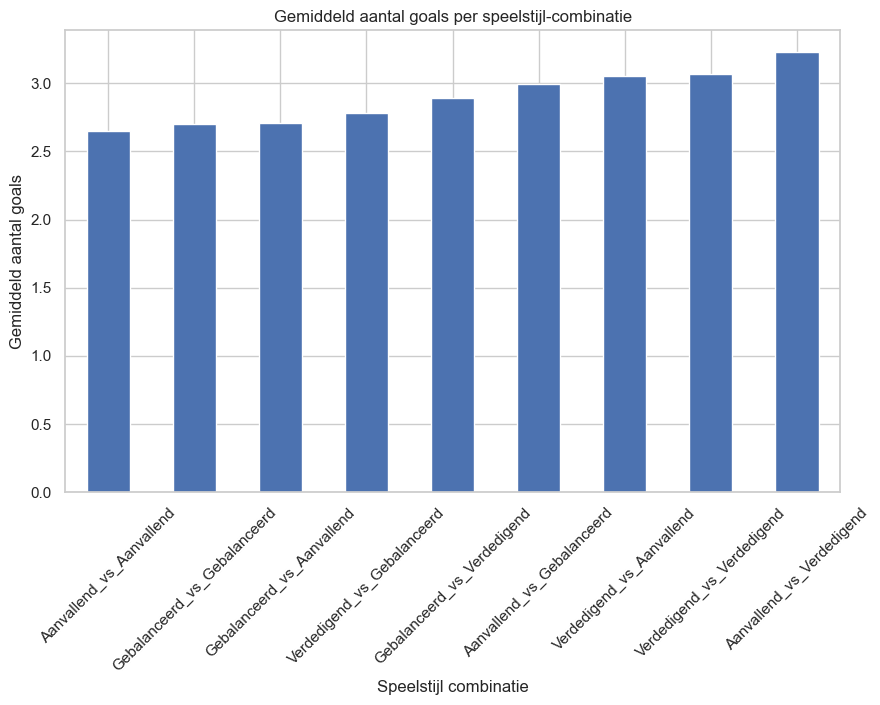


p-value: 0.00367
👉 Verschil is statistisch significant


In [791]:
# ===============================
# 2️⃣ Specifieke situatie:
# Aanvallend vs Verdedigend
# ===============================
subset = df[df['speelstijl_combo'] == 'Aanvallend_vs_Verdedigend']

# ===============================
# 3️⃣ Gemiddelden
# ===============================
gem_specifiek = subset['totaal_goals'].mean()
gem_algemeen = df['totaal_goals'].mean()

print(f"Gemiddeld aantal goals (Aanvallend vs Verdedigend): {gem_specifiek:.2f}")
print(f"Algemeen gemiddelde aantal goals: {gem_algemeen:.2f}")

# ===============================
# 4️⃣ Interpretatie
# ===============================
if gem_specifiek > gem_algemeen:
    conclusie = "meer"
elif gem_specifiek < gem_algemeen:
    conclusie = "minder"
else:
    conclusie = "hetzelfde"

print(f"👉 In deze situatie vallen gemiddeld {conclusie} doelpunten.")

# ===============================
# 5️⃣ Overzicht alle combinaties
# ===============================
overzicht = df.groupby('speelstijl_combo')['totaal_goals'].mean().sort_values()
print("\nGemiddeld aantal goals per speelstijl-combinatie:")
print(overzicht)

# ===============================
# 6️⃣ Visualisatie (barplot)
# ===============================
plt.figure(figsize=(10,6))
overzicht.plot(kind='bar')
plt.title("Gemiddeld aantal goals per speelstijl-combinatie")
plt.xlabel("Speelstijl combinatie")
plt.ylabel("Gemiddeld aantal goals")
plt.xticks(rotation=45)
plt.show()

# ===============================
# 7️⃣ Statistische test (t-test)
# ===============================
groep1 = subset['totaal_goals'].dropna()
groep2 = df['totaal_goals'].dropna()

t_stat, p = ttest_ind(groep1, groep2, equal_var=False)

print(f"\np-value: {p:.5f}")

if p < 0.05:
    print("👉 Verschil is statistisch significant")
else:
    print("👉 Geen significant verschil")

### Als het erg warm (>23°C) is, zal het aantal schoten meer/zelfde/minder zijn dan gemiddeld.

Gemiddeld aantal schoten bij warm weer (>23°C): 24.70
Algemeen gemiddeld aantal schoten: 24.80
👉 Bij warm weer vallen gemiddeld minder schoten per wedstrijd.


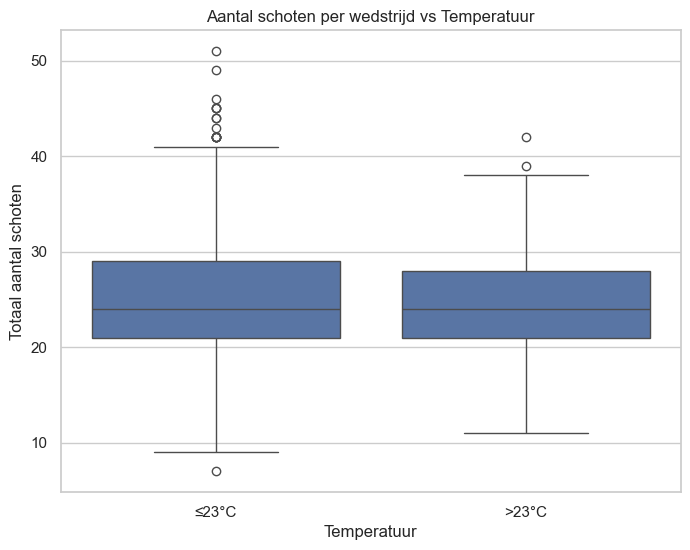


T-test p-value: 0.87160
👉 Geen significant verschil


In [792]:
# ===============================
# Analyse: Warm weer vs Aantal schoten
# ===============================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# 1️⃣ Totale schoten per wedstrijd
df['totaal_schoten'] = df['schoten_thuis'] + df['schoten_uit']

# 2️⃣ Subset voor warm weer (>23°C)
subset_warm = df[df['temperatuur_gem_c'] > 23].copy()

# 3️⃣ Gemiddelden berekenen
gemiddelde_warm = subset_warm['totaal_schoten'].mean()
gemiddelde_algemeen = df['totaal_schoten'].mean()

print(f"Gemiddeld aantal schoten bij warm weer (>23°C): {gemiddelde_warm:.2f}")
print(f"Algemeen gemiddeld aantal schoten: {gemiddelde_algemeen:.2f}")

# 4️⃣ Interpretatie (meer/minder/hetzelfde)
if gemiddelde_warm > gemiddelde_algemeen:
    conclusie = "meer"
elif gemiddelde_warm < gemiddelde_algemeen:
    conclusie = "minder"
else:
    conclusie = "hetzelfde"

print(f"👉 Bij warm weer vallen gemiddeld {conclusie} schoten per wedstrijd.")

# 5️⃣ Visualisatie
plt.figure(figsize=(8,6))
sns.boxplot(x=pd.cut(df['temperatuur_gem_c'], bins=[-10,23,50], labels=['≤23°C', '>23°C']),
            y=df['totaal_schoten'])
plt.title("Aantal schoten per wedstrijd vs Temperatuur")
plt.xlabel("Temperatuur")
plt.ylabel("Totaal aantal schoten")
plt.show()

# 6️⃣ Statistische test (t-test)
groep_warm = subset_warm['totaal_schoten'].dropna()
groep_algemeen = df['totaal_schoten'].dropna()

t_stat, p = ttest_ind(groep_warm, groep_algemeen, equal_var=False)

print(f"\nT-test p-value: {p:.5f}")
if p < 0.05:
    print("👉 Verschil is statistisch significant")
else:
    print("👉 Geen significant verschil")

### Als er een derby is, of rivalen spelen, zal het aantal schoten van beide teams meer/zelfde/minder zijn dan gemiddeld.

Gemiddeld aantal schoten bij derby/rivaliteit: 24.77
Algemeen gemiddeld aantal schoten: 24.80
👉 Bij derby/rivaliteitswedstrijden vallen gemiddeld minder schoten per wedstrijd.


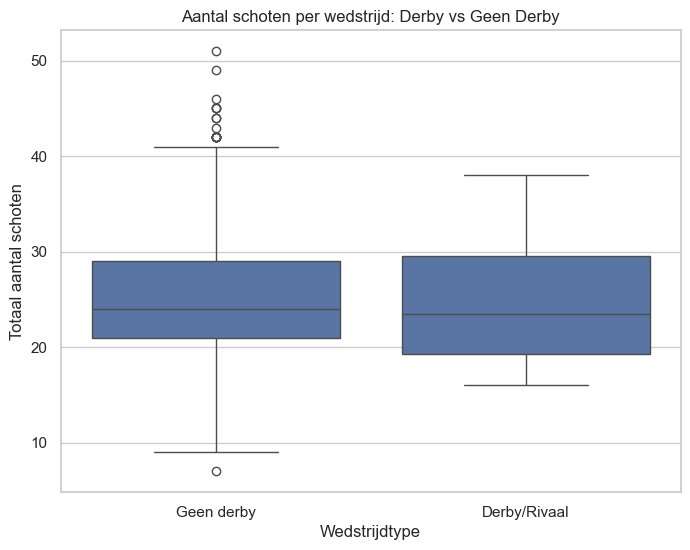


T-test p-value: 0.98687
👉 Geen significant verschil


In [793]:
# 1️⃣ Totale schoten per wedstrijd
wedstrijden_compleet_df['totaal_schoten'] = wedstrijden_compleet_df['schoten_thuis'] + wedstrijden_compleet_df['schoten_uit']

# 2️⃣ Subset van derby- of rivaliteitswedstrijden
derby_subset = wedstrijden_compleet_df[wedstrijden_compleet_df['derby/rivaal'] == 1].copy()

# 3️⃣ Gemiddelden berekenen
gemiddelde_derby = derby_subset['totaal_schoten'].mean()
gemiddelde_algemeen = wedstrijden_compleet_df['totaal_schoten'].mean()

print(f"Gemiddeld aantal schoten bij derby/rivaliteit: {gemiddelde_derby:.2f}")
print(f"Algemeen gemiddeld aantal schoten: {gemiddelde_algemeen:.2f}")

# 4️⃣ Interpretatie (meer/minder/hetzelfde)
if gemiddelde_derby > gemiddelde_algemeen:
    conclusie = "meer"
elif gemiddelde_derby < gemiddelde_algemeen:
    conclusie = "minder"
else:
    conclusie = "hetzelfde"

print(f"👉 Bij derby/rivaliteitswedstrijden vallen gemiddeld {conclusie} schoten per wedstrijd.")

# 5️⃣ Visualisatie
plt.figure(figsize=(8,6))
sns.boxplot(x=wedstrijden_compleet_df['derby/rivaal'].map({0:'Geen derby', 1:'Derby/Rivaal'}),
            y=wedstrijden_compleet_df['totaal_schoten'])
plt.title("Aantal schoten per wedstrijd: Derby vs Geen Derby")
plt.xlabel("Wedstrijdtype")
plt.ylabel("Totaal aantal schoten")
plt.show()

# 6️⃣ Statistische test (t-test)
groep_derby = derby_subset['totaal_schoten'].dropna()
groep_algemeen = wedstrijden_compleet_df['totaal_schoten'].dropna()

t_stat, p = ttest_ind(groep_derby, groep_algemeen, equal_var=False)

print(f"\nT-test p-value: {p:.5f}")
if p < 0.05:
    print("👉 Verschil is statistisch significant")
else:
    print("👉 Geen significant verschil")

### Weekend → resultaat

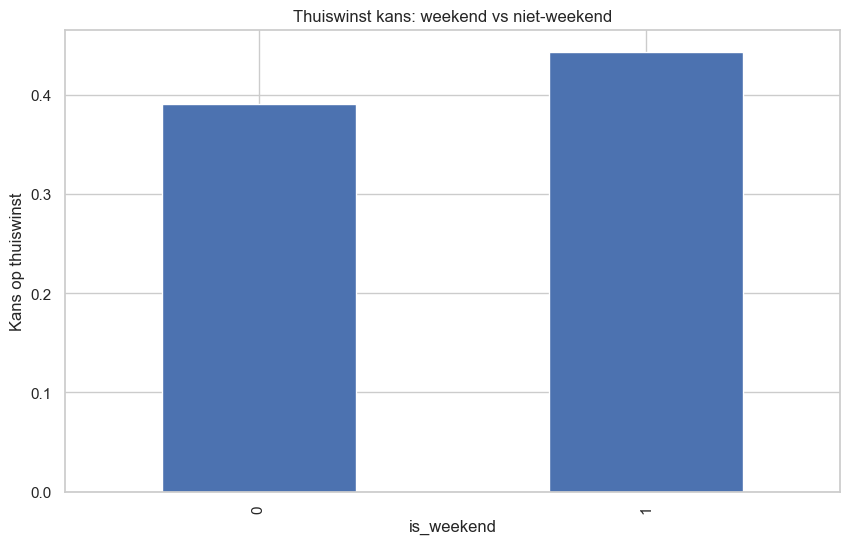

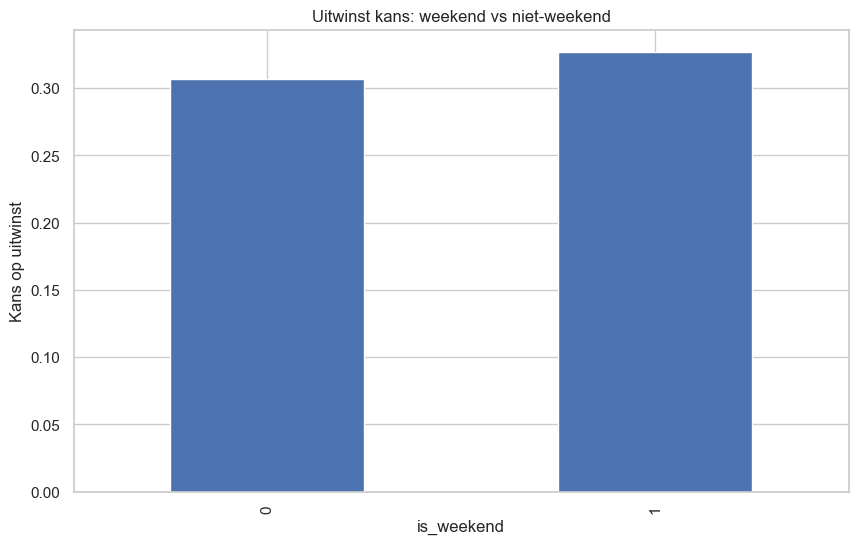

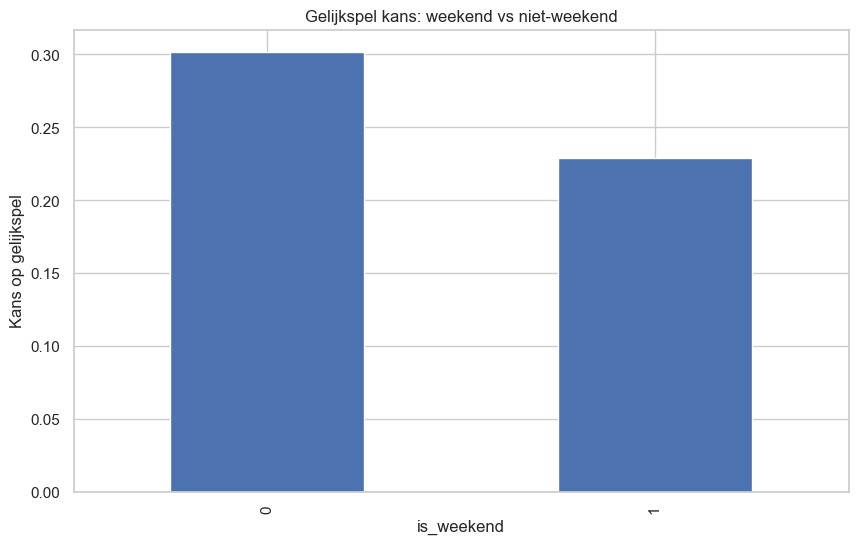

In [794]:
df['thuis_wint'] = (df['resultaat_voltijd'] == 'H').astype(int)

df.groupby('is_weekend')['thuis_wint'].mean().plot(kind='bar')
plt.title("Thuiswinst kans: weekend vs niet-weekend")
plt.ylabel("Kans op thuiswinst")
plt.show()

df['uit_wint'] = (df['resultaat_voltijd'] == 'A').astype(int)

df.groupby('is_weekend')['uit_wint'].mean().plot(kind='bar')
plt.title("Uitwinst kans: weekend vs niet-weekend")
plt.ylabel("Kans op uitwinst")
plt.show()

df['gelijkspel'] = (df['resultaat_voltijd'] == 'D').astype(int)

df.groupby('is_weekend')['gelijkspel'].mean().plot(kind='bar')
plt.title("Gelijkspel kans: weekend vs niet-weekend")
plt.ylabel("Kans op gelijkspel")
plt.show()

### Als team A 10 plaatsen boven team B staat in het klassement: hoe groot is volgens u de kans op een overwinning van team A?  Percentage (0 - 100)

Aantal wedstrijden met rangverschil ±10: 109
Aantal keer dat het hoger gerangschikte team won: 86
Percentage dat het hoger gerangschikte team won: 78.90%


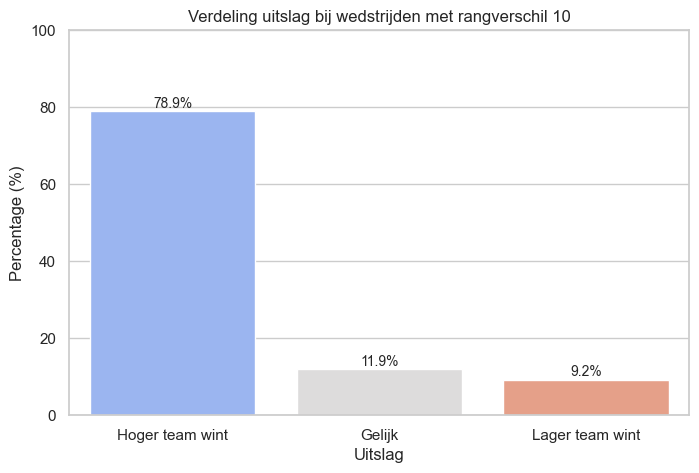

In [795]:
# 1️⃣ Filter alle wedstrijden waar het rangverschil 10 of -10 is
df_10 = df[df['rank_diff'].abs() == 10]

# 2️⃣ Bepaal het hoger gerangschikte team
def hoger_team(row):
    if row['rank_diff'] < 0:
        return row['thuis_team']  # thuisteam hoger
    else:
        return row['uit_team']    # uitteam hoger

df_10['hoger_team'] = df_10.apply(hoger_team, axis=1)

# 3️⃣ Bepaal wie echt won
def echte_winnaar(row):
    if row['resultaat_voltijd'] == 'H':
        return row['thuis_team']
    elif row['resultaat_voltijd'] == 'A':
        return row['uit_team']
    else:
        return 'gelijk'

df_10['echte_winnaar'] = df_10.apply(echte_winnaar, axis=1)

# 4️⃣ Check of hoger team gewonnen heeft
df_10['hoger_team_wint'] = df_10['hoger_team'] == df_10['echte_winnaar']

# 5️⃣ Bereken percentage van alle wedstrijden
totaal = len(df_10)
aantal_hoger_wint = df_10['hoger_team_wint'].sum()
percentage = (aantal_hoger_wint / totaal) * 100

print(f"Aantal wedstrijden met rangverschil ±10: {totaal}")
print(f"Aantal keer dat het hoger gerangschikte team won: {aantal_hoger_wint}")
print(f"Percentage dat het hoger gerangschikte team won: {percentage:.2f}%")

# 1️⃣ Maak een nieuwe kolom met drie categorieën: 'Hoger team wint', 'Lager team wint', 'Gelijk'
def uitslag_category(row):
    if row['echte_winnaar'] == 'gelijk':
        return 'Gelijk'
    elif row['hoger_team_wint']:
        return 'Hoger team wint'
    else:
        return 'Lager team wint'

df_10['uitslag_cat'] = df_10.apply(uitslag_category, axis=1)

# 2️⃣ Tel het aantal per categorie
uitslag_counts = df_10['uitslag_cat'].value_counts().reset_index()
uitslag_counts.columns = ['Uitslag', 'Aantal']

# 3️⃣ Bereken percentage
uitslag_counts['Percentage'] = (uitslag_counts['Aantal'] / uitslag_counts['Aantal'].sum()) * 100

# 4️⃣ Plot een mooie staafgrafiek
plt.figure(figsize=(8,5))
sns.barplot(data=uitslag_counts, x='Uitslag', y='Percentage', palette='coolwarm')
plt.title('Verdeling uitslag bij wedstrijden met rangverschil 10')
plt.ylabel('Percentage (%)')
plt.ylim(0, 100)
for i, row in uitslag_counts.iterrows():
    plt.text(i, row['Percentage']+1, f"{row['Percentage']:.1f}%", ha='center', fontsize=10)
plt.show()

### Stel dat een team 3 keer op rij verloren heeft, hoe groot is volgens u de kans op een 4e nederlaag?  Percentage (0 - 100)

In [796]:
import pandas as pd

# 1️⃣ Combineer thuis- en uitteam in één dataframe
teams = pd.concat([
    df[['thuis_team','resultaat_voltijd','wedstrijd_datum']].rename(
        columns={'thuis_team':'team','resultaat_voltijd':'resultaat'}),
    df[['uit_team','resultaat_voltijd','wedstrijd_datum']].rename(
        columns={'uit_team':'team','resultaat_voltijd':'resultaat'})
])

# 2️⃣ Sorteer per team en datum
teams = teams.sort_values(['team','wedstrijd_datum']).reset_index(drop=True)

# 3️⃣ Maak een kolom 'verlies' (1 = verlies, 0 = niet verloren)
# Stel: verlies = H als thuis, A als uit
teams['verlies'] = teams['resultaat'].map({'H':1, 'A':1, 'D':0})

# 4️⃣ Bereken rolling window van 3 opeenvolgende verliezen
teams['verlies_3_reeks'] = teams.groupby('team')['verlies'].rolling(window=3).sum().reset_index(level=0, drop=True)

# 5️⃣ Kijk of de **volgende wedstrijd** ook verlies was
teams['volgende_verlies'] = teams.groupby('team')['verlies'].shift(-1)

# 6️⃣ Filter gevallen waar team 3 keer op rij verloor
teams_3verlies = teams[teams['verlies_3_reeks'] == 3]

# 7️⃣ Percentage dat 4e verlies volgde
totaal = len(teams_3verlies)
aantal_vierde = teams_3verlies['volgende_verlies'].sum()
percentage_vierde = (aantal_vierde / totaal) * 100

print(f"Aantal gevallen met 3 opeenvolgende verliezen: {totaal}")
print(f"Aantal keer dat een 4e verlies volgde: {aantal_vierde}")
print(f"Percentage dat een 4e verlies volgde: {percentage_vierde:.2f}%")

Aantal gevallen met 3 opeenvolgende verliezen: 1731
Aantal keer dat een 4e verlies volgde: 1315.0
Percentage dat een 4e verlies volgde: 75.97%


### Avondmatch → doelpunten

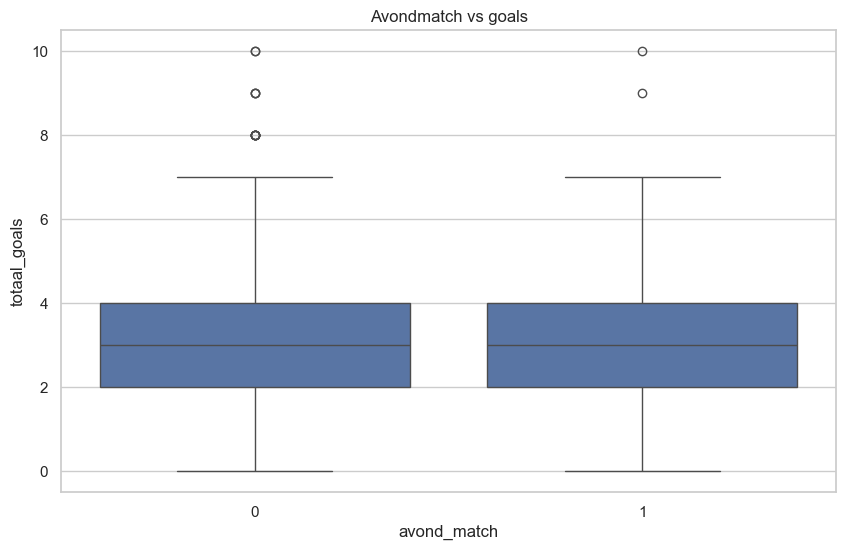

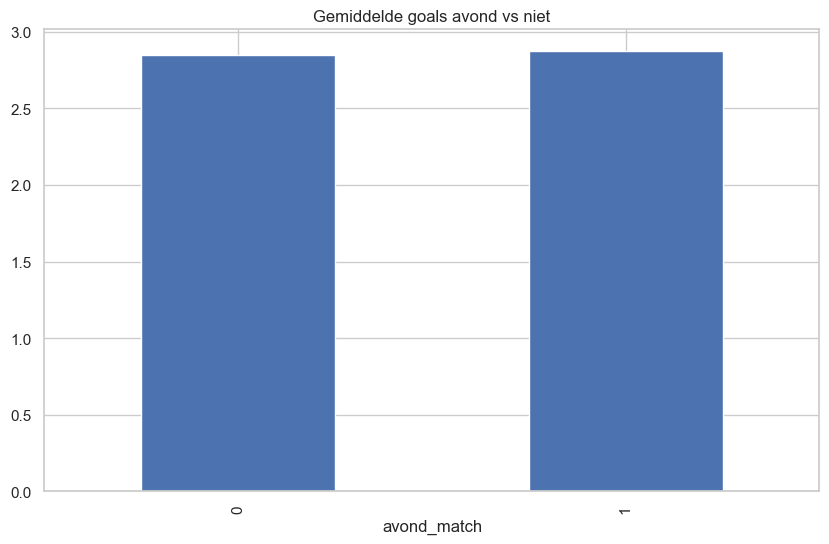

In [797]:
sns.boxplot(x=df['avond_match'], y=df['totaal_goals'])
plt.title("Avondmatch vs goals")
plt.show()

df.groupby('avond_match')['totaal_goals'].mean().plot(kind='bar')
plt.title("Gemiddelde goals avond vs niet")
plt.show()

### Hoeveel invloed heeft een wedstrijd voor de titel op het aantal schoten?

Gemiddeld aantal schoten bij titelwedstrijden: 26.00
Algemeen gemiddeld aantal schoten: 24.80
👉 Bij titelwedstrijden worden gemiddeld meer schoten gedaan.


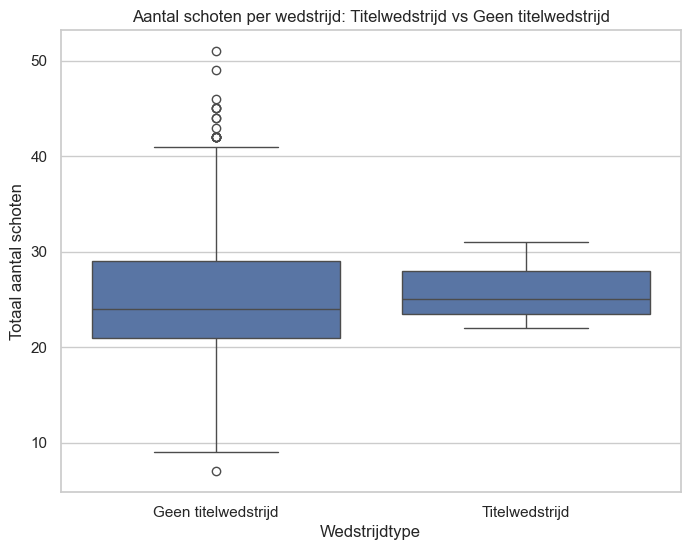


T-test p-value: 0.69387
👉 Geen significant verschil


In [798]:
# 1️⃣ Totaal aantal schoten per wedstrijd (thuis + uit)
df['totaal_schoten'] = df['schoten_thuis'] + df['schoten_uit']

# 2️⃣ Subset van titelwedstrijden
titel_subset = df[df['titel_match'] == 1].copy()

# 3️⃣ Gemiddelden berekenen
gemiddelde_titel = titel_subset['totaal_schoten'].mean()
gemiddelde_algemeen = df['totaal_schoten'].mean()

print(f"Gemiddeld aantal schoten bij titelwedstrijden: {gemiddelde_titel:.2f}")
print(f"Algemeen gemiddeld aantal schoten: {gemiddelde_algemeen:.2f}")

# 4️⃣ Interpretatie
if gemiddelde_titel > gemiddelde_algemeen:
    conclusie = "meer"
elif gemiddelde_titel < gemiddelde_algemeen:
    conclusie = "minder"
else:
    conclusie = "hetzelfde"

print(f"👉 Bij titelwedstrijden worden gemiddeld {conclusie} schoten gedaan.")

# 5️⃣ Visualisatie
plt.figure(figsize=(8,6))
sns.boxplot(
    x=df['titel_match'].map({0:'Geen titelwedstrijd', 1:'Titelwedstrijd'}),
    y=df['totaal_schoten']
)
plt.title("Aantal schoten per wedstrijd: Titelwedstrijd vs Geen titelwedstrijd")
plt.xlabel("Wedstrijdtype")
plt.ylabel("Totaal aantal schoten")
plt.show()

# 6️⃣ Statistische test (t-test)
groep_titel = titel_subset['totaal_schoten'].dropna()
groep_algemeen = df['totaal_schoten'].dropna()

t_stat, p = ttest_ind(groep_titel, groep_algemeen, equal_var=False)

print(f"\nT-test p-value: {p:.5f}")
if p < 0.05:
    print("👉 Verschil is statistisch significant")
else:
    print("👉 Geen significant verschil")

### Hoeveel invloed heeft een derby/rivalen match op het aantal kaarten?

Gemiddeld aantal kaarten bij derby/rivaliteit: 4.32
Algemeen gemiddeld aantal kaarten: 4.13
👉 Bij derby/rivaliteitswedstrijden worden gemiddeld meer kaarten gegeven.


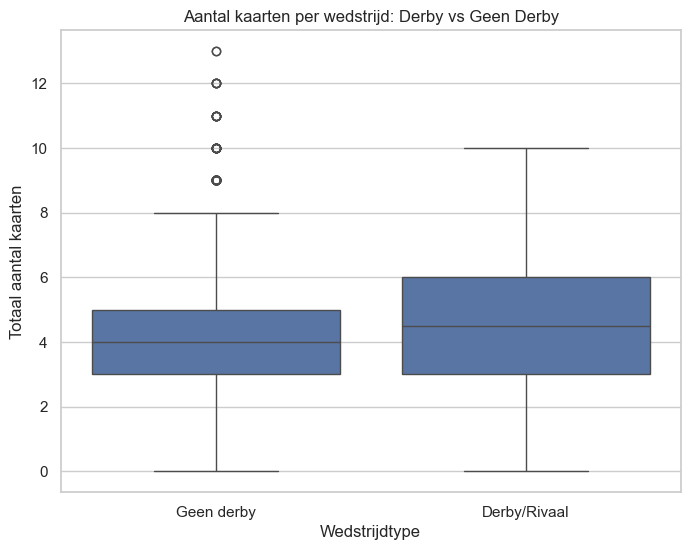


T-test p-value: 0.71765
👉 Geen significant verschil


In [799]:
# 1️⃣ Totaal aantal kaarten per wedstrijd (geel + rood)
wedstrijden_compleet_df['totaal_kaarten'] = (
    wedstrijden_compleet_df['gele_kaarten_thuis'] +
    wedstrijden_compleet_df['gele_kaarten_uit'] +
    wedstrijden_compleet_df['rode_kaarten_thuis'] +
    wedstrijden_compleet_df['rode_kaarten_uit']
)

# 2️⃣ Subset van derby/rivaliteitswedstrijden
derby_subset = wedstrijden_compleet_df[wedstrijden_compleet_df['derby/rivaal'] == 1].copy()

# 3️⃣ Gemiddelden berekenen
gemiddelde_derby = derby_subset['totaal_kaarten'].mean()
gemiddelde_algemeen = wedstrijden_compleet_df['totaal_kaarten'].mean()

print(f"Gemiddeld aantal kaarten bij derby/rivaliteit: {gemiddelde_derby:.2f}")
print(f"Algemeen gemiddeld aantal kaarten: {gemiddelde_algemeen:.2f}")

# 4️⃣ Interpretatie
if gemiddelde_derby > gemiddelde_algemeen:
    conclusie = "meer"
elif gemiddelde_derby < gemiddelde_algemeen:
    conclusie = "minder"
else:
    conclusie = "hetzelfde"

print(f"👉 Bij derby/rivaliteitswedstrijden worden gemiddeld {conclusie} kaarten gegeven.")

# 5️⃣ Visualisatie
plt.figure(figsize=(8,6))
sns.boxplot(
    x=wedstrijden_compleet_df['derby/rivaal'].map({0:'Geen derby', 1:'Derby/Rivaal'}),
    y=wedstrijden_compleet_df['totaal_kaarten']
)
plt.title("Aantal kaarten per wedstrijd: Derby vs Geen Derby")
plt.xlabel("Wedstrijdtype")
plt.ylabel("Totaal aantal kaarten")
plt.show()

# 6️⃣ Statistische test (t-test)
groep_derby = derby_subset['totaal_kaarten'].dropna()
groep_algemeen = wedstrijden_compleet_df['totaal_kaarten'].dropna()

t_stat, p = ttest_ind(groep_derby, groep_algemeen, equal_var=False)

print(f"\nT-test p-value: {p:.5f}")
if p < 0.05:
    print("👉 Verschil is statistisch significant")
else:
    print("👉 Geen significant verschil")

### Hoeveel invloed heeft een wedstrijd voor degradatie op het aantal kaarten?

Gemiddeld aantal kaarten bij degradatiewedstrijden: 4.88
Algemeen gemiddeld aantal kaarten: 4.13
👉 Bij degradatiewedstrijden worden gemiddeld meer kaarten gegeven.


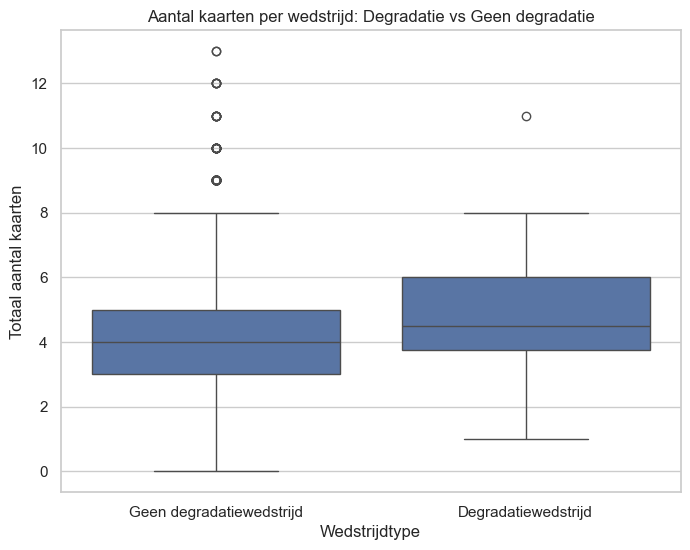


T-test p-value: 0.28235
👉 Geen significant verschil


In [800]:
# 1️⃣ Totaal aantal kaarten per wedstrijd
df['totaal_kaarten'] = df['gele_kaarten_thuis'] + df['gele_kaarten_uit'] + df['rode_kaarten_thuis'] + df['rode_kaarten_uit']

# 2️⃣ Subset van degradatiewedstrijden
degradatie_subset = df[df['degradatie_match'] == 1].copy()

# 3️⃣ Gemiddelden berekenen
gemiddelde_degradatie = degradatie_subset['totaal_kaarten'].mean()
gemiddelde_algemeen = df['totaal_kaarten'].mean()

print(f"Gemiddeld aantal kaarten bij degradatiewedstrijden: {gemiddelde_degradatie:.2f}")
print(f"Algemeen gemiddeld aantal kaarten: {gemiddelde_algemeen:.2f}")

# 4️⃣ Interpretatie
if gemiddelde_degradatie > gemiddelde_algemeen:
    conclusie = "meer"
elif gemiddelde_degradatie < gemiddelde_algemeen:
    conclusie = "minder"
else:
    conclusie = "hetzelfde"

print(f"👉 Bij degradatiewedstrijden worden gemiddeld {conclusie} kaarten gegeven.")

# 5️⃣ Visualisatie
plt.figure(figsize=(8,6))
sns.boxplot(
    x=df['degradatie_match'].map({0:'Geen degradatiewedstrijd', 1:'Degradatiewedstrijd'}),
    y=df['totaal_kaarten']
)
plt.title("Aantal kaarten per wedstrijd: Degradatie vs Geen degradatie")
plt.xlabel("Wedstrijdtype")
plt.ylabel("Totaal aantal kaarten")
plt.show()

# 6️⃣ Statistische test (t-test)
groep_degradatie = degradatie_subset['totaal_kaarten'].dropna()
groep_algemeen = df['totaal_kaarten'].dropna()

t_stat, p = ttest_ind(groep_degradatie, groep_algemeen, equal_var=False)

print(f"\nT-test p-value: {p:.5f}")
if p < 0.05:
    print("👉 Verschil is statistisch significant")
else:
    print("👉 Geen significant verschil")

### Werkelijke kans op resultaten

resultaat_voltijd
H    0.433200
A    0.323031
D    0.243769
Name: proportion, dtype: float64


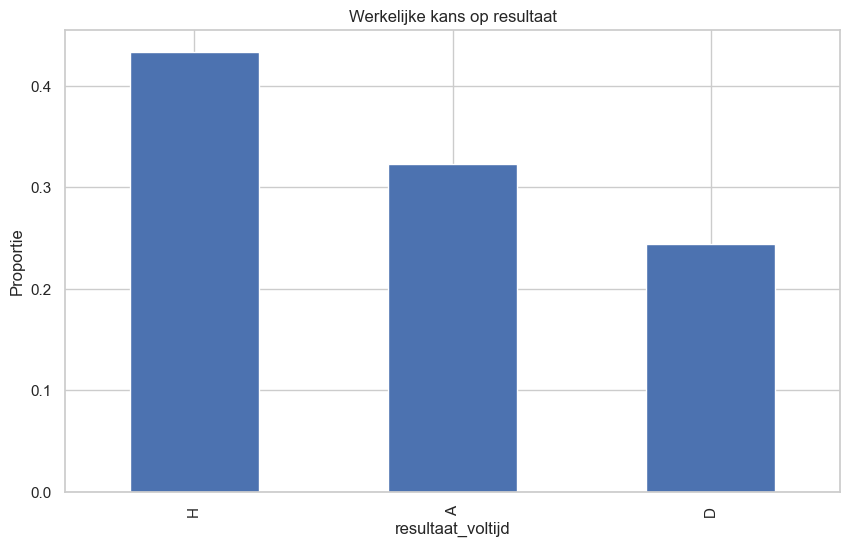

In [801]:
result_dist = df['resultaat_voltijd'].value_counts(normalize=True)

print(result_dist)

result_dist.plot(kind='bar')
plt.title("Werkelijke kans op resultaat")
plt.ylabel("Proportie")
plt.show()

### Werkelijk aantal goals

Gemiddelde goals:
doelpunten_thuis_voltijd    1.568295
doelpunten_uit_voltijd      1.290628
dtype: float64


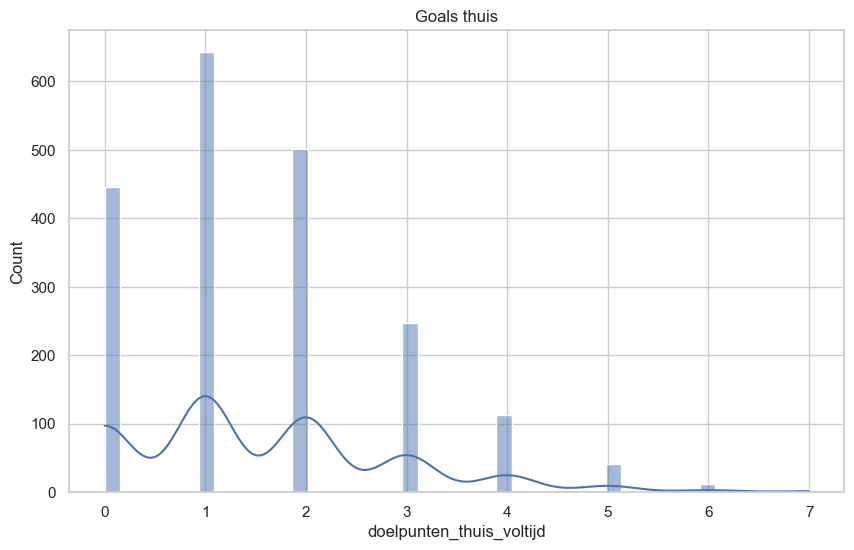

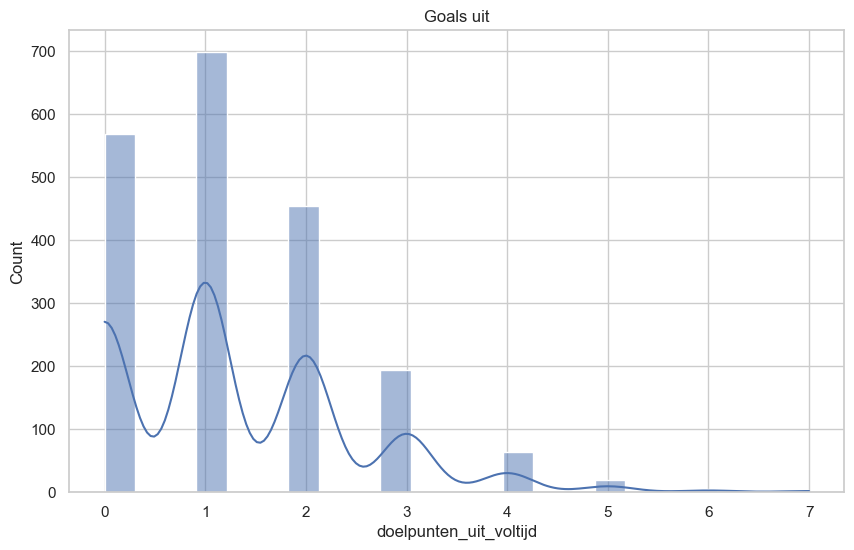

In [802]:
print("Gemiddelde goals:")
print(df[['doelpunten_thuis_voltijd','doelpunten_uit_voltijd']].mean())

sns.histplot(df['doelpunten_thuis_voltijd'], kde=True)
plt.title("Goals thuis")
plt.show()

sns.histplot(df['doelpunten_uit_voltijd'], kde=True)
plt.title("Goals uit")
plt.show()

## 8. Model voor doelpunten

- Keuze model (Poisson regression, regressie)
- Features en target
- Resultaten evaluatie

## 9. Model evaluatie

- Accuracy, log-loss, RMSE, MAE
- Grafieken van voorspelling vs echte resultaten

## 10. Expertdata

### CSV (enquête) inladen

In [803]:
enquete_df = pd.read_csv('../data/experts_enquete.csv')

### Kolommen hernoemen

In [804]:
rename_map = {
    "Kans op thuiswinst  (0 - 100)": "Kans_thuis_RSCvCercle",
    "Kans op gelijkspel  (0 - 100)": "Kans_gelijk_RSCvCercle",
    "Kans op uitwinst  (0 - 100)": "Kans_uit_RSCvCercle",
    "Verwacht aantal doelpunten thuisteam?": "Doelpunten_thuis_RSCvCercle",
    "Verwacht aantal doelpunten uitteam?": "Doelpunten_uit_RSCvCercle",
    "Hoe zeker bent u van deze match voorspelling?": "Confidence_RSCvCercle",
    "Kans op thuiswinst  (0 - 100).1": "Kans_thuis_STVVvUSG",
    "Kans op gelijkspel  (0 - 100).1": "Kans_gelijk_STVVvUSG",
    "Kans op uitwinst  (0 - 100).1": "Kans_uit_STVVvUSG",
    "Verwacht aantal doelpunten thuisteam?.1": "Doelpunten_thuis_STVVvUSG",
    "Verwacht aantal doelpunten uitteam?.1": "Doelpunten_uit_STVVvUSG",
    "Hoe zeker bent u van deze match voorspelling?.1": "Confidence_STVVvUSG"
}

enquete_df = enquete_df.rename(columns=rename_map)

### Schalen controleren en omzetten

In [805]:
scale_1_5 = [
    "Hoe belangrijk is het thuisvoordeel bij het voorspellen van winst/verlies?",
    "In welke mate beïnvloedt stadioncapaciteit het totaal aantal schoten in een wedstrijd?  ",
    "In welke mate beïnvloedt stadioncapaciteit het aantal overtredingen van het uitteam?  ",
    "Heeft regen invloed op het aantal doelpunten?  ",
    "In welke mate verwacht u dat regen het aantal kaarten in een wedstrijd beïnvloedt? ",
    "Hoe bepalend is recente vorm (laatste 5 wedstrijden) voor het resultaat? ",
    "Hoe belangrijk is het verschil in het klassement voor het voorspellen van een wedstrijd? ",
    "In welke mate hebben eerdere confrontaties invloed in uw voorspelling? ",
    "In welke mate verwacht u dat een hoger aantal schoten samenhangt met meer corners tijdens een wedstrijd? ",
    "Hoe zeker bent u van deze match voorspelling?",
    "Hoeveel invloed heeft een derby/rivalen match op het aantal kaarten?",
    "Hoeveel invloed heeft een wedstrijd voor de titel op het aantal schoten?",
    "Hoeveel invloed heeft een wedstrijd voor degradatie op het aantal kaarten?"
]

scale_0_100 = [
    "Kans_thuis_RSCvCercle", "Kans_gelijk_RSCvCercle", "Kans_uit_RSCvCercle",
    "Doelpunten_thuis_RSCvCercle", "Doelpunten_uit_RSCvCercle", "Confidence_RSCvCercle",
    "Kans_thuis_STVVvUSG", "Kans_gelijk_STVVvUSG", "Kans_uit_STVVvUSG",
    "Doelpunten_thuis_STVVvUSG", "Doelpunten_uit_STVVvUSG", "Confidence_STVVvUSG",
    "Als team A 10 plaatsen boven team B staat in het klassement: hoe groot is volgens u de kans op een overwinning van team A?  Percentage (0 - 100)",
    "Stel dat een team 3 keer op rij verloren heeft, hoe groot is volgens u de kans op een 4e nederlaag?  Percentage (0 - 100)"
]

# 1-5 schaal: numeriek en foutcontrole
for col in scale_1_5:
    if col in enquete_df.columns:
        enquete_df[col] = pd.to_numeric(enquete_df[col], errors="coerce").clip(1,5)

# 0-100 schaal: numeriek, clip 0-100
for col in scale_0_100:
    if col in enquete_df.columns:
        enquete_df[col] = pd.to_numeric(enquete_df[col], errors="coerce").clip(0,100)

### Test: Som van kansen voor wedstrijden moet 100 zijn

In [806]:
# Wedstrijd 1: RSC Anderlecht vs Cercle Brugge
enquete_df['kans_som_match1'] = (
    enquete_df['Kans_thuis_RSCvCercle'] +
    enquete_df['Kans_gelijk_RSCvCercle'] +
    enquete_df['Kans_uit_RSCvCercle']
)

# Wedstrijd 2: Sint-Truidense VV vs Union Saint-Gilloise
enquete_df['kans_som_match2'] = (
    enquete_df['Kans_thuis_STVVvUSG'] +
    enquete_df['Kans_gelijk_STVVvUSG'] +
    enquete_df['Kans_uit_STVVvUSG']
)

# Controleer wedstrijd 1
fouten_match1 = enquete_df[enquete_df['kans_som_match1'] != 100]
if not fouten_match1.empty:
    print("Fouten in kans-som voor match 1 (RSCvCercle):")
    print(fouten_match1[['Kans_thuis_RSCvCercle', 'Kans_gelijk_RSCvCercle', 'Kans_uit_RSCvCercle', 'kans_som_match1']])
else:
    print("Alle sommen van kansvragen voor match 1 zijn correct (=100)")

# Controleer wedstrijd 2
fouten_match2 = enquete_df[enquete_df['kans_som_match2'] != 100]
if not fouten_match2.empty:
    print("\nFouten in kans-som voor match 2 (STVVvUSG):")
    print(fouten_match2[['Kans_thuis_STVVvUSG', 'Kans_gelijk_STVVvUSG', 'Kans_uit_STVVvUSG', 'kans_som_match2']])
else:
    print("Alle sommen van kansvragen voor match 2 zijn correct (=100)")

# Verwijder tijdelijke kolommen na controle
enquete_df = enquete_df.drop(columns=['kans_som_match1', 'kans_som_match2'])

Alle sommen van kansvragen voor match 1 zijn correct (=100)
Alle sommen van kansvragen voor match 2 zijn correct (=100)


In [807]:
enquete_df.info()

enquete_df = enquete_df.drop(['Tijdstempel'], axis=1)

enquete_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 49 columns):
 #   Column                                                                                                                                            Non-Null Count  Dtype
---  ------                                                                                                                                            --------------  -----
 0   Tijdstempel                                                                                                                                       6 non-null      str  
 1   Hoe belangrijk is het thuisvoordeel bij het voorspellen van winst/verlies?                                                                        6 non-null      int64
 2   In welke mate beïnvloedt stadioncapaciteit het totaal aantal schoten in een wedstrijd?                                                            6 non-null      int64
 3   In welke mate beïnvloedt stadioncapacite

,Hoe belangrijk is het thuisvoordeel bij het voorspellen van winst/verlies?,In welke mate beïnvloedt stadioncapaciteit het totaal aantal schoten in een wedstrijd?,In welke mate beïnvloedt stadioncapaciteit het aantal overtredingen van het uitteam?,Heeft regen invloed op het aantal doelpunten?,In welke mate verwacht u dat regen het aantal kaarten in een wedstrijd beïnvloedt?,Hoe bepalend is recente vorm (laatste 5 wedstrijden) voor het resultaat?,Hoe belangrijk is het verschil in het klassement voor het voorspellen van een wedstrijd?,In welke mate hebben eerdere confrontaties invloed in uw voorspelling?,In welke mate verwacht u dat een hoger aantal schoten samenhangt met meer corners tijdens een wedstrijd?,Kans_thuis_RSCvCercle,...,Rangschik de onderstaande factoren van meeste invloed → minste invloed voor aantal kaarten [5e],Rangschik de onderstaande factoren van meeste invloed → minste invloed voor aantal kaarten [6e],"Als het hard regent, zullen er ... kaarten verwacht worden.","Als het hard regent, zullen er ... doelpunten verwacht worden.",Als het thuisteam een aanvallende speelstijl hanteert en het uitteam defensief speelt zullen er gemiddeld ... doelpunten vallen.,"Als het erg warm (>23°C) is, zal het aantal schoten ... zijn dan gemiddeld.","Als er een derby is, of rivalen spelen, zal het aantal schoten van beide teams ... zijn dan gemiddeld.",Hoeveel invloed heeft een derby/rivalen match op het aantal kaarten?,Hoeveel invloed heeft een wedstrijd voor de titel op het aantal schoten?,Hoeveel invloed heeft een wedstrijd voor degradatie op het aantal kaarten?
0,4,1,1,3,2,4,4,4,5,50,...,stadioncapaciteit,tijdstip,meer,zelfde,meer,zelfde,meer,4,4,4
1,3,2,2,3,2,4,4,4,4,52,...,stadioncapaciteit,Recente vorm,meer,zelfde,zelfde,minder,meer,5,4,4
2,4,3,3,2,1,4,4,3,1,65,...,neerslag,tijdstip,zelfde,zelfde,meer,zelfde,minder,4,4,2
3,4,4,5,1,3,3,3,4,4,60,...,neerslag,stadioncapaciteit,meer,zelfde,minder,minder,meer,5,5,5
4,5,3,1,3,1,1,5,4,1,70,...,derby/rivalen,tijdstip,zelfde,zelfde,zelfde,zelfde,zelfde,4,1,1


### Factorbelang van wedstrijdstatistieken (inclusief mentale aspecten en motivatie)

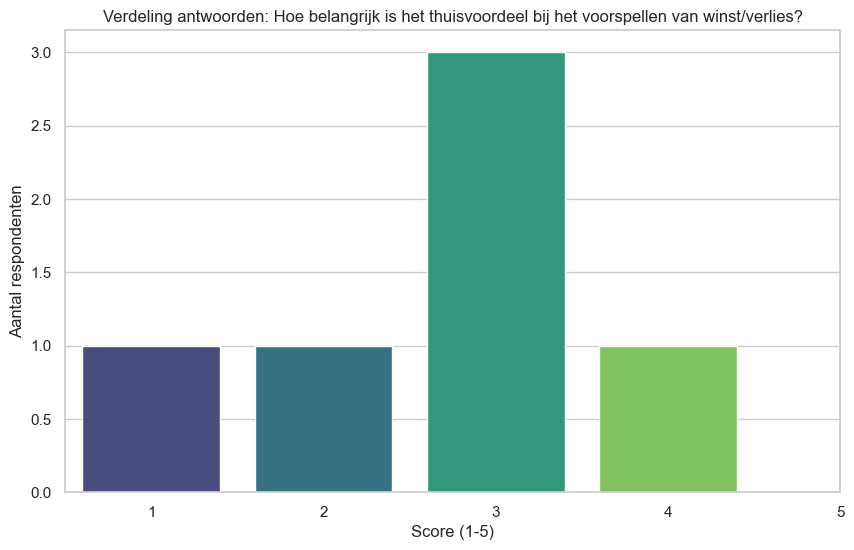

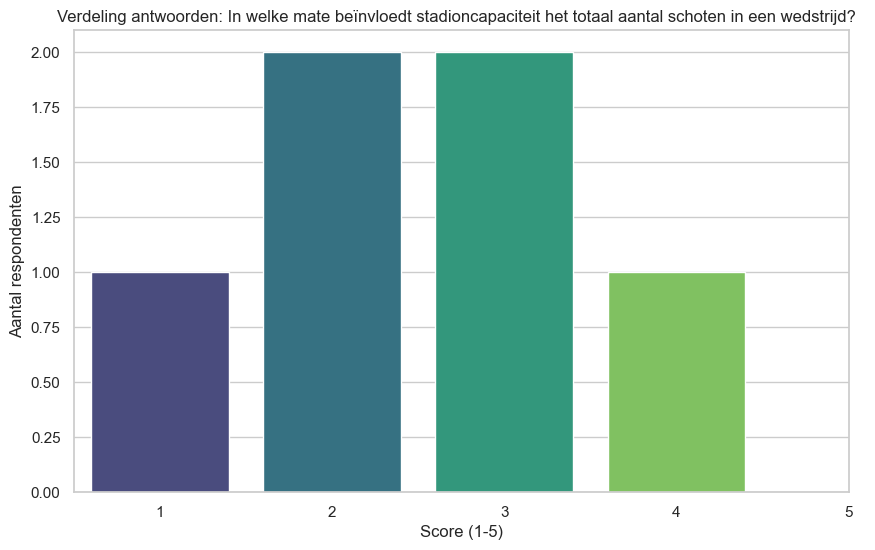

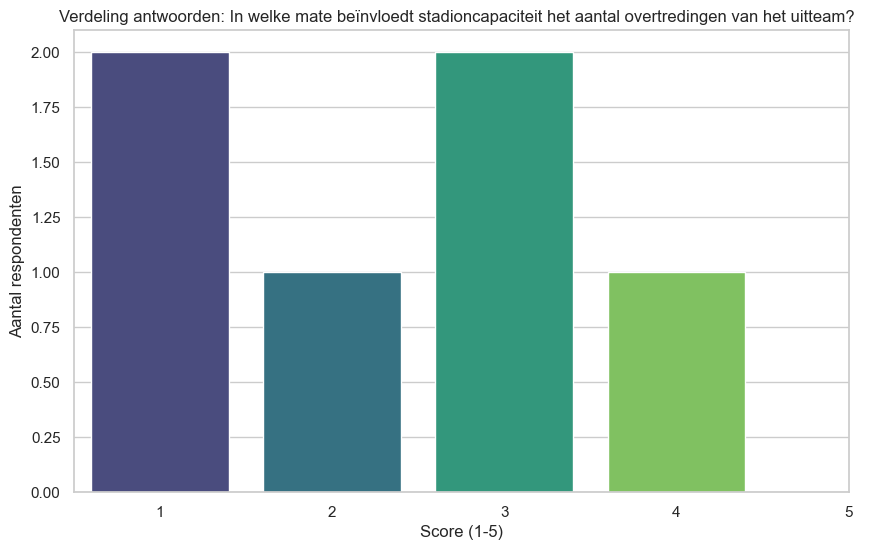

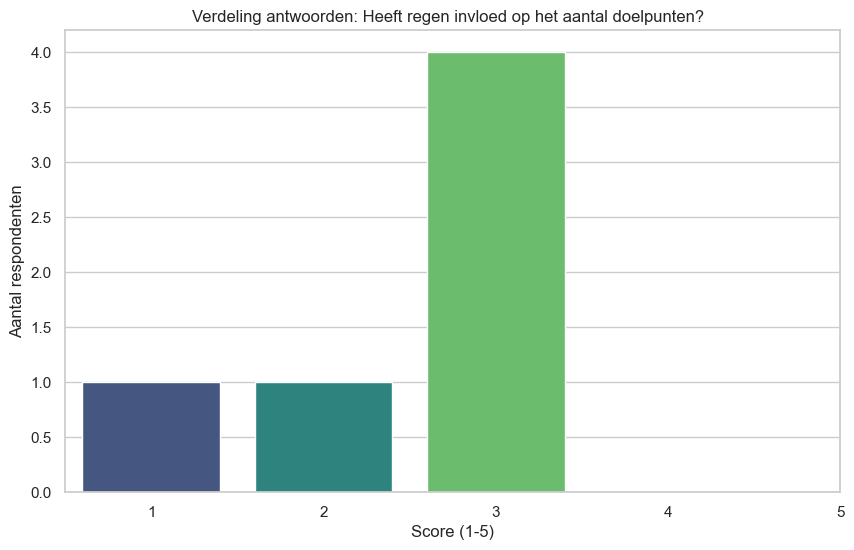

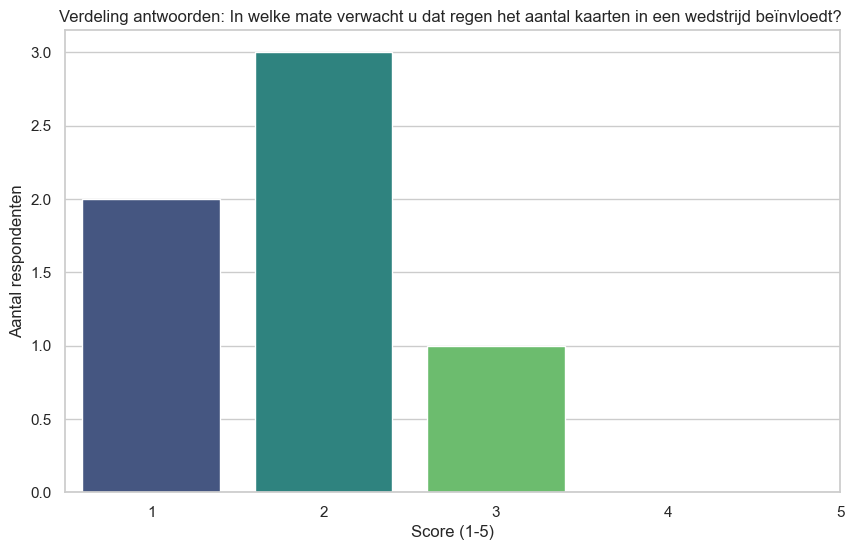

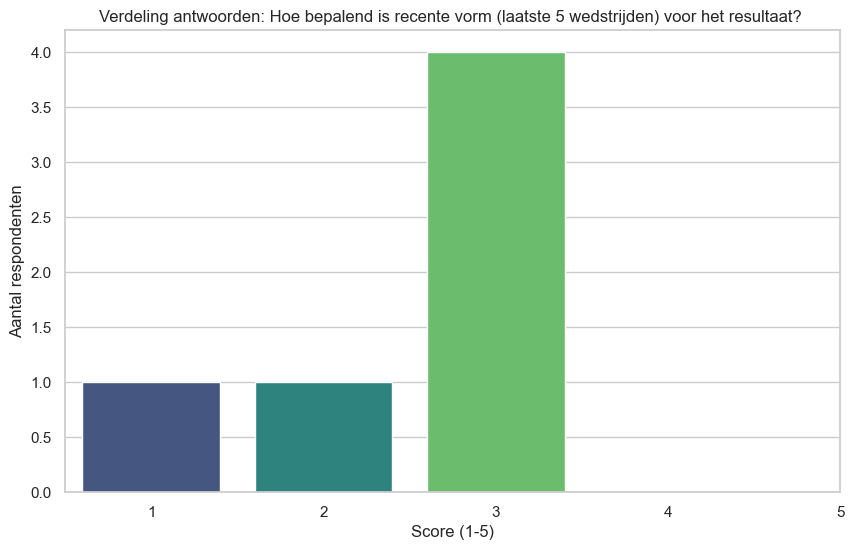

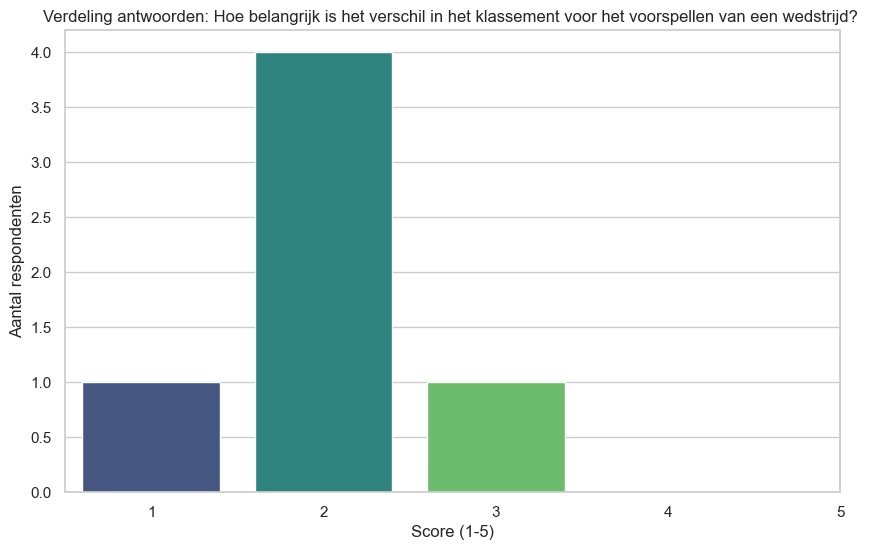

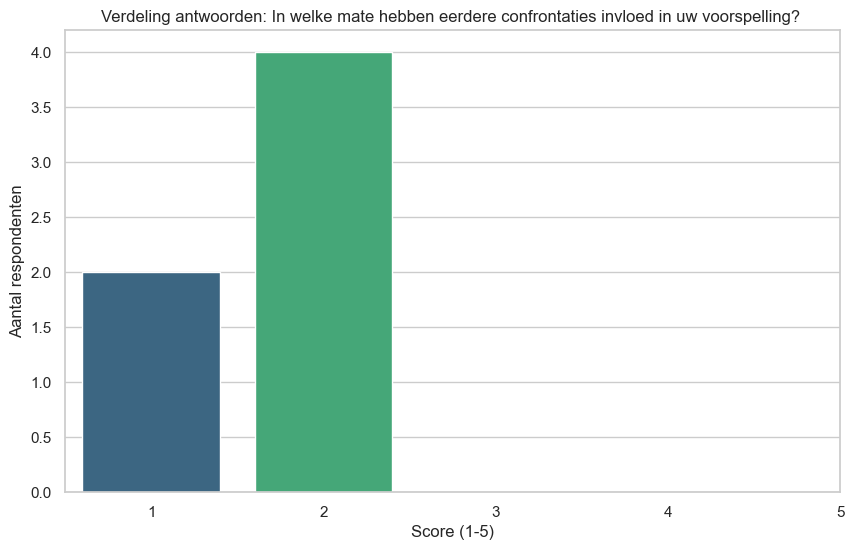

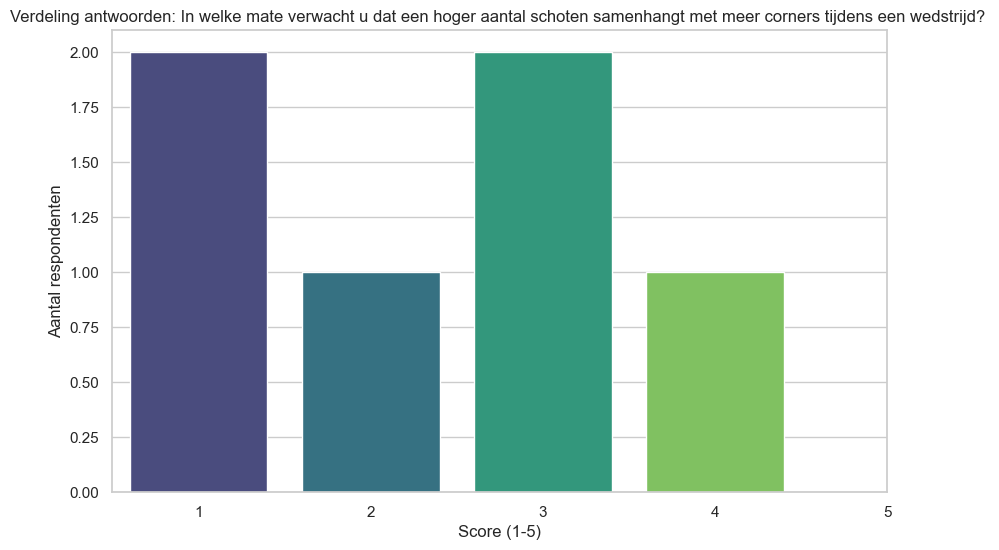

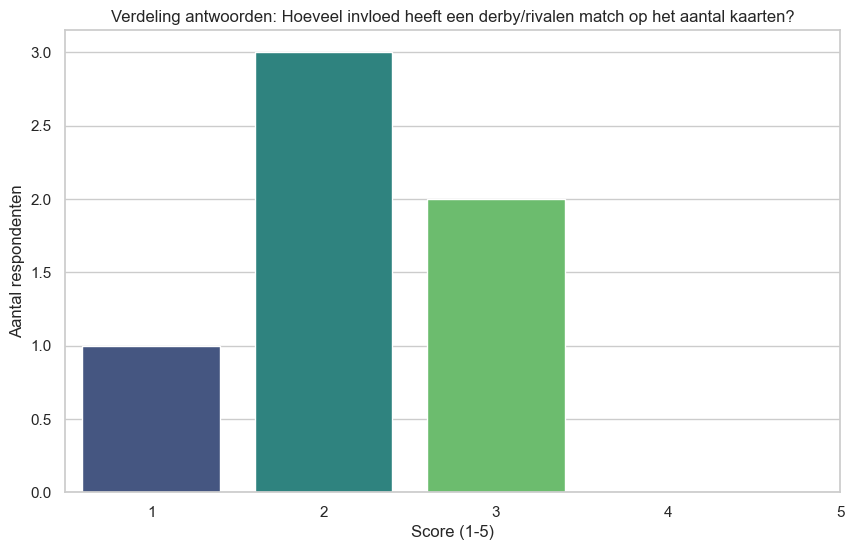

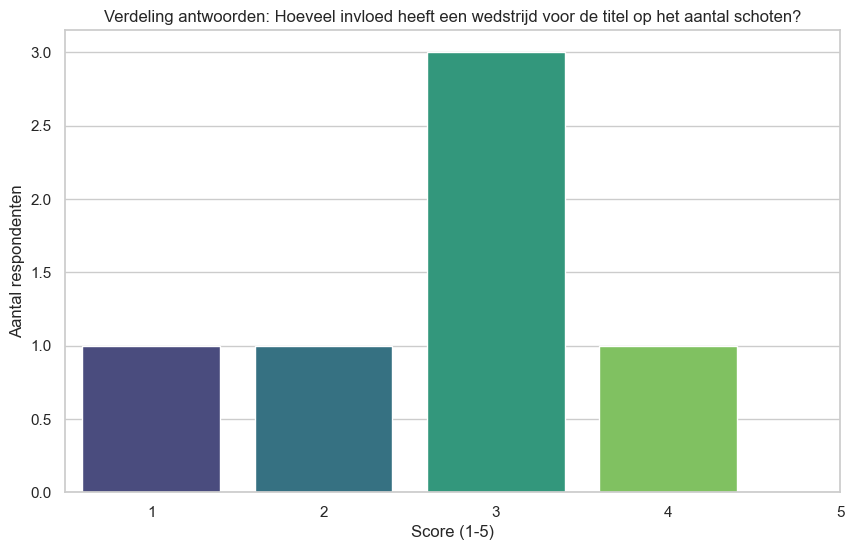

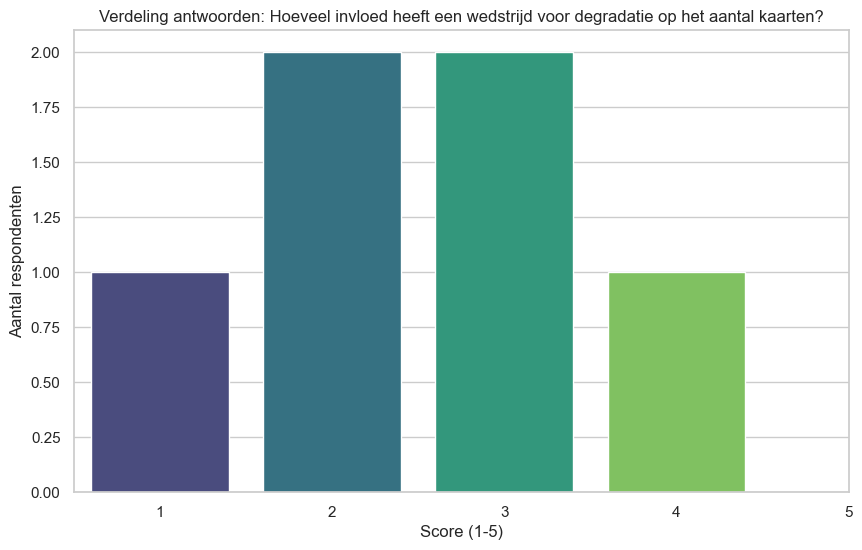

In [808]:
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

for col in scale_1_5:
    if col in enquete_df.columns:
        plt.figure()
        sns.countplot(data=enquete_df, x=col, palette="viridis")
        plt.title(f"Verdeling antwoorden: {col}")
        plt.xlabel("Score (1-5)")
        plt.ylabel("Aantal respondenten")
        plt.xticks([0,1,2,3,4], [1,2,3,4,5])
        plt.show()

### Concrete voorspellingen voor geselecteerde wedstrijden

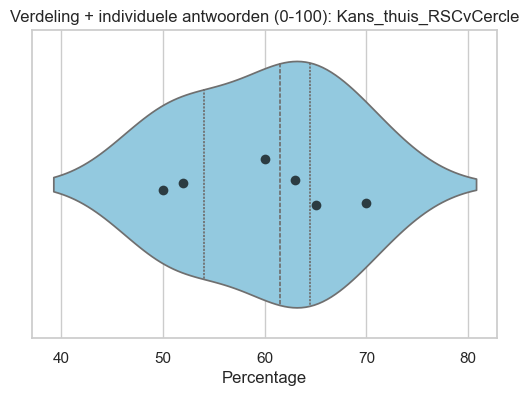

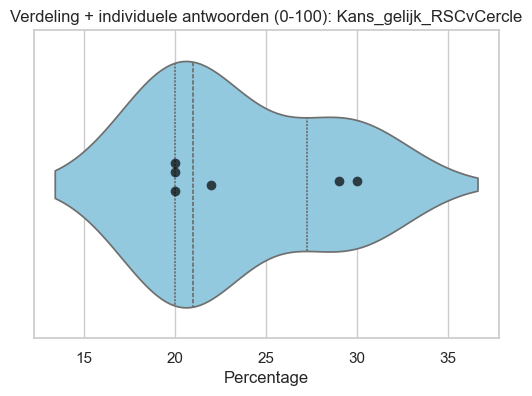

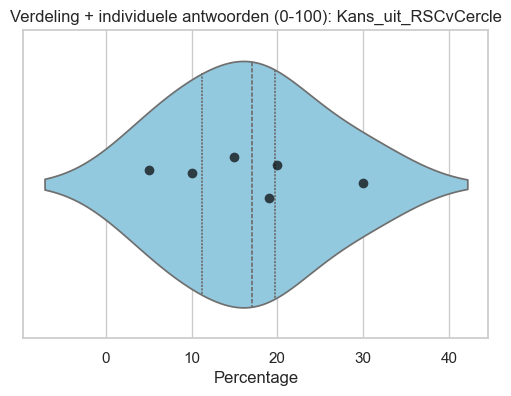

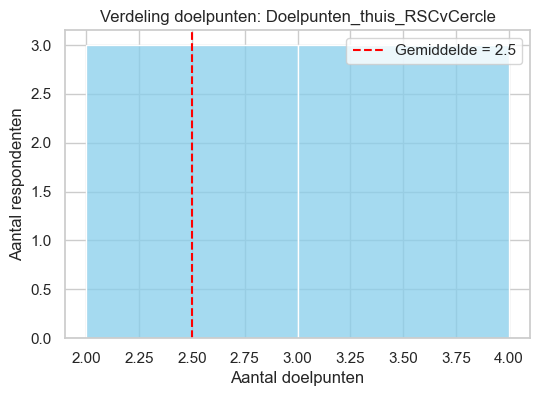

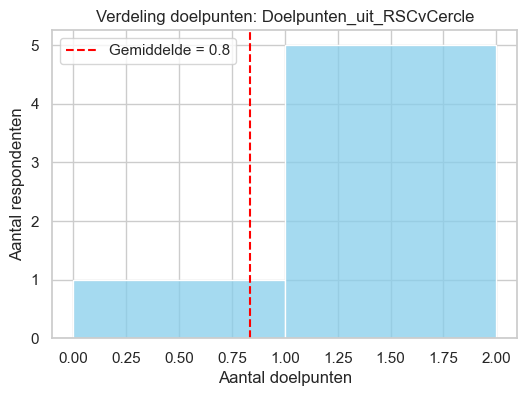

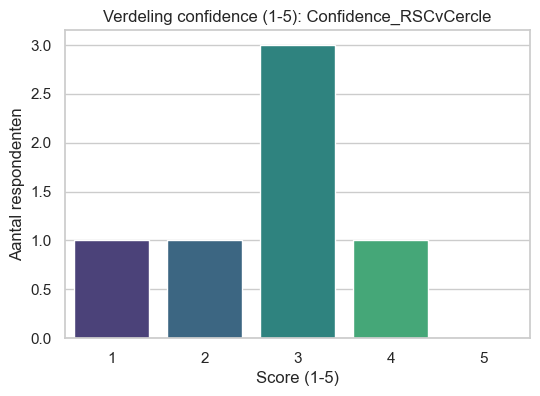

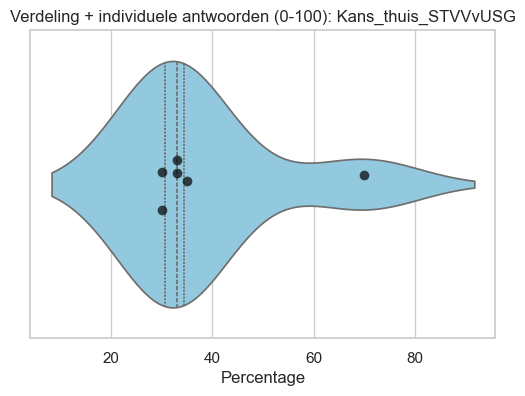

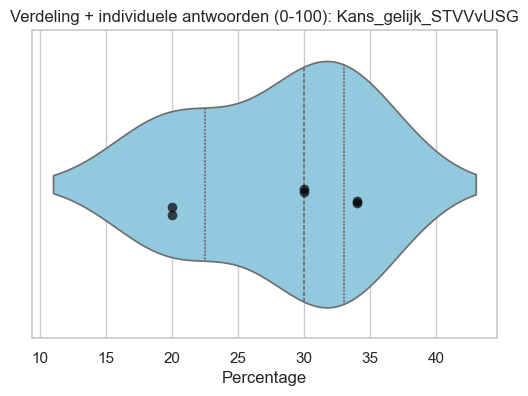

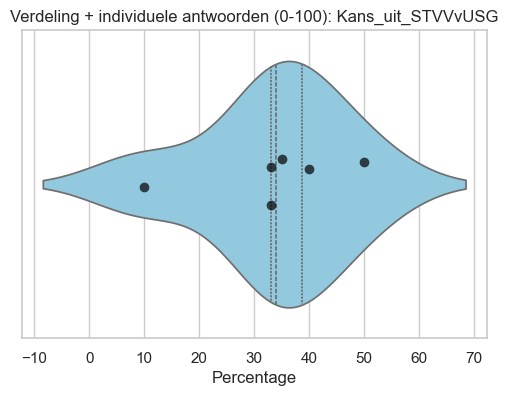

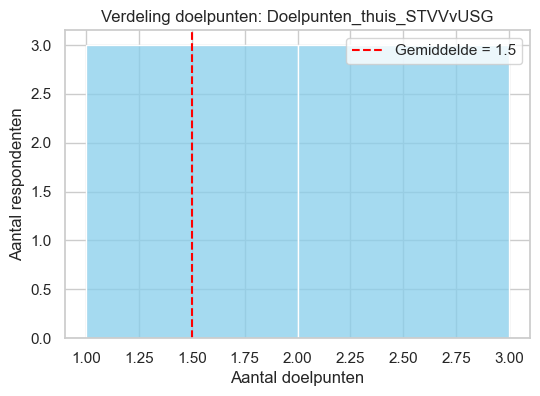

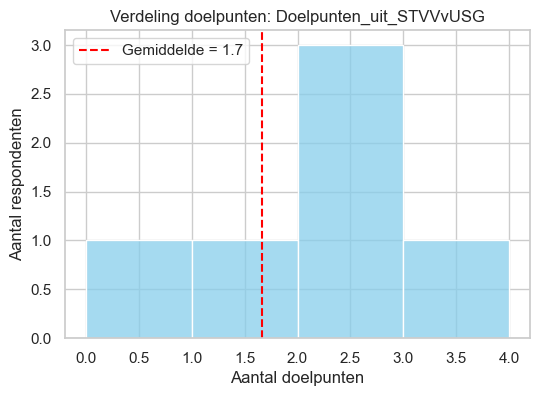

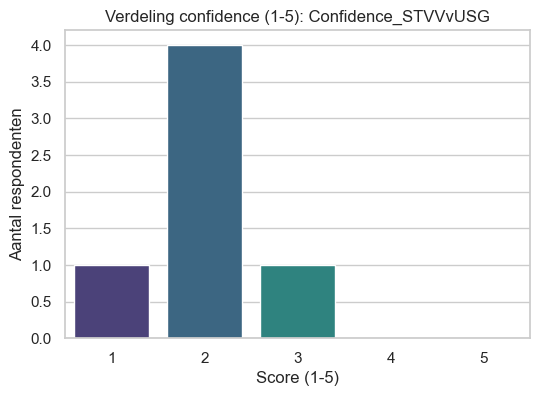

In [809]:
# Wedstrijden
wedstrijden = [
    {
        "prefix": "RSCvCercle",
        "cols_pct": ['Kans_thuis_RSCvCercle', 'Kans_gelijk_RSCvCercle', 'Kans_uit_RSCvCercle'],
        "cols_num": ['Doelpunten_thuis_RSCvCercle', 'Doelpunten_uit_RSCvCercle', 'Confidence_RSCvCercle']
    },
    {
        "prefix": "STVVvUSG",
        "cols_pct": ['Kans_thuis_STVVvUSG', 'Kans_gelijk_STVVvUSG', 'Kans_uit_STVVvUSG'],
        "cols_num": ['Doelpunten_thuis_STVVvUSG', 'Doelpunten_uit_STVVvUSG', 'Confidence_STVVvUSG']
    }
]

for match in wedstrijden:
    # --- Percentage vragen (0-100) ---
    for col in match['cols_pct']:
        if col in enquete_df.columns:
            data = enquete_df[col].clip(0, 100)
            plt.figure(figsize=(6,4))
            sns.violinplot(x=data, inner="quartile", color="skyblue")
            sns.stripplot(x=data, color='black', jitter=True, size=7, alpha=0.7)
            plt.title(f"Verdeling + individuele antwoorden (0-100): {col}")
            plt.xlabel("Percentage")
            plt.show()
    
    # --- Numerieke vragen (doelpunten, confidence) ---
    for col in match['cols_num']:
        if col in enquete_df.columns:
            data = enquete_df[col].dropna()
            plt.figure(figsize=(6,4))
            
            # Gemiddelde voor doelpunten
            if "Doelpunten" in col:
                mean_val = data.mean()
                sns.histplot(data, bins=range(int(data.min()), int(data.max())+2), color="skyblue", kde=False)
                plt.axvline(mean_val, color='red', linestyle='--', label=f'Gemiddelde = {mean_val:.1f}')
                plt.legend()
                plt.title(f"Verdeling doelpunten: {col}")
                plt.xlabel("Aantal doelpunten")
                plt.ylabel("Aantal respondenten")
            
            # Confidence 1-5 schaal
            elif "Confidence" in col:
                sns.countplot(x=data, palette="viridis", order=range(1,6))
                plt.title(f"Verdeling confidence (1-5): {col}")
                plt.xlabel("Score (1-5)")
                plt.ylabel("Aantal respondenten")
            
            plt.show()

### Overige kans vragen

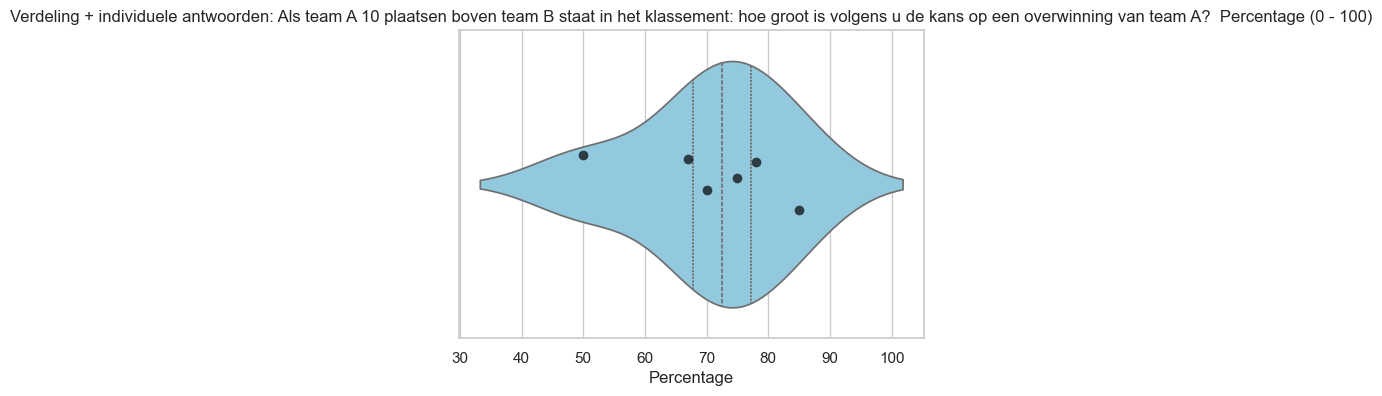

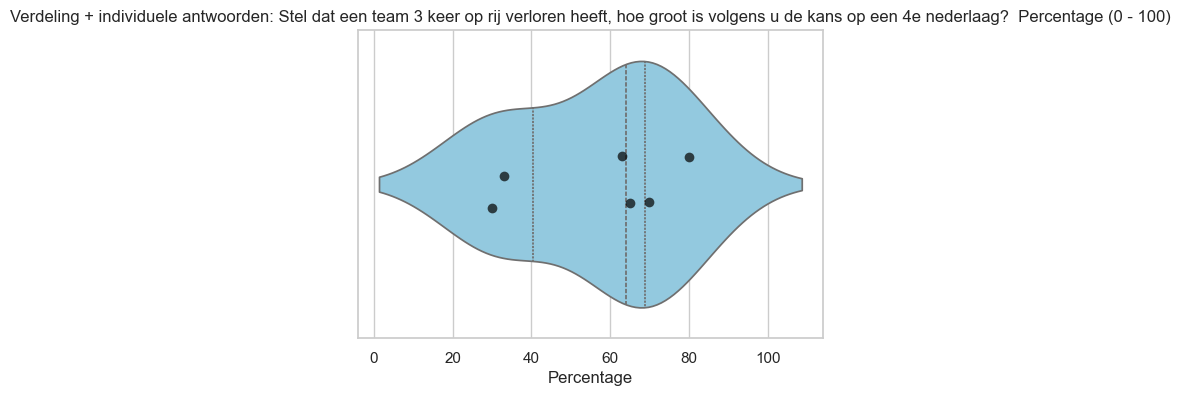

In [810]:
kans_vragen = [
    "Als team A 10 plaatsen boven team B staat in het klassement: hoe groot is volgens u de kans op een overwinning van team A?  Percentage (0 - 100)",
    "Stel dat een team 3 keer op rij verloren heeft, hoe groot is volgens u de kans op een 4e nederlaag?  Percentage (0 - 100)"
]

for col in kans_vragen:
    if col in enquete_df.columns:
        # Clip waarden tussen 0 en 100
        data = enquete_df[col].clip(0, 100)

        plt.figure(figsize=(6,4))
        sns.violinplot(x=data, inner="quartile", color="skyblue")
        sns.stripplot(x=data, color='black', jitter=True, size=7, alpha=0.7)
        plt.title(f"Verdeling + individuele antwoorden: {col}")
        plt.xlabel("Percentage")
        plt.show()

### Ranking van factoren

In [811]:
def borda_score_plot(df, keyword, titel, figsize=(8,5), palette="Blues_d"):
    """
    Bereken Borda scores voor ranking-vragen en plot de resultaten.

    Parameters:
    - df: DataFrame met enquete resultaten
    - keyword: string die in kolomnamen voorkomt, bv. "winst/verlies"
    - titel: titel van de plot
    - figsize: grootte van de plot
    - palette: kleuren voor de barplot
    """
    # Filter kolommen met rankings
    cols = [col for col in df.columns if keyword in col and "[" in col]
    if not cols:
        print(f"Geen kolommen gevonden voor keyword: {keyword}")
        return
    
    ranking = df[cols]
    scores = {}

    for col in ranking.columns:
        # Extract positie uit kolomnaam (bijv. "[1e]" → 1)
        match = re.search(r"\[(\d+)e\]", col)
        if match:
            positie = int(match.group(1))
        else:
            continue
        # Borda punten: 1e = max punten
        punten = len(cols) - positie + 1

        for factor in ranking[col]:
            if pd.notnull(factor):
                scores[factor] = scores.get(factor, 0) + punten

    # Sorteer scores van hoog naar laag
    scores_df = pd.Series(scores).sort_values(ascending=False)

    # Plot
    plt.figure(figsize=figsize)
    sns.barplot(x=scores_df.values, y=scores_df.index, palette=palette)
    plt.title(titel)
    plt.xlabel("Borda score")
    plt.ylabel("Factor")
    plt.show()

    # Extra: Top1 verdeling
    top1_col = cols[0]
    top1_counts = ranking[top1_col].value_counts().sort_values(ascending=False)
    plt.figure(figsize=figsize)
    sns.barplot(x=top1_counts.values, y=top1_counts.index, palette="Greens_d")
    plt.title(f"Welke factor staat het vaakst op plaats 1 ({keyword})")
    plt.xlabel("Aantal keer 1e plaats")
    plt.ylabel("Factor")
    plt.show()

    return scores_df

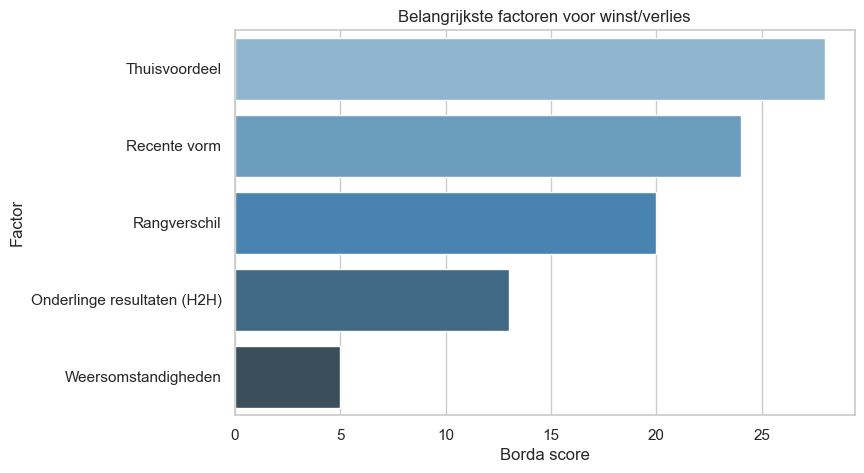

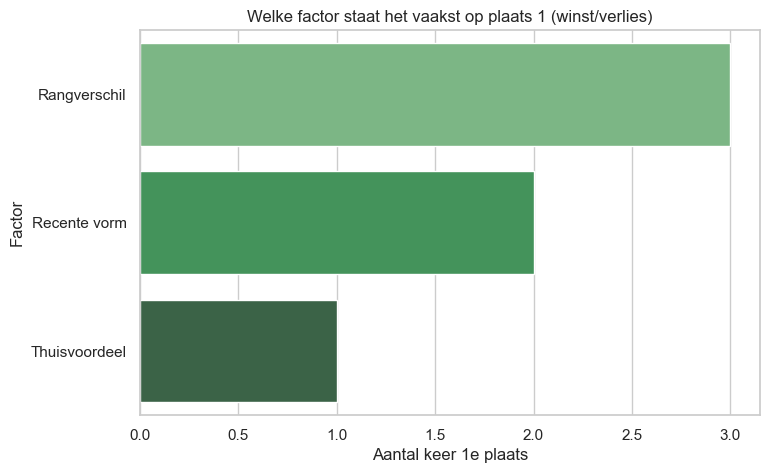

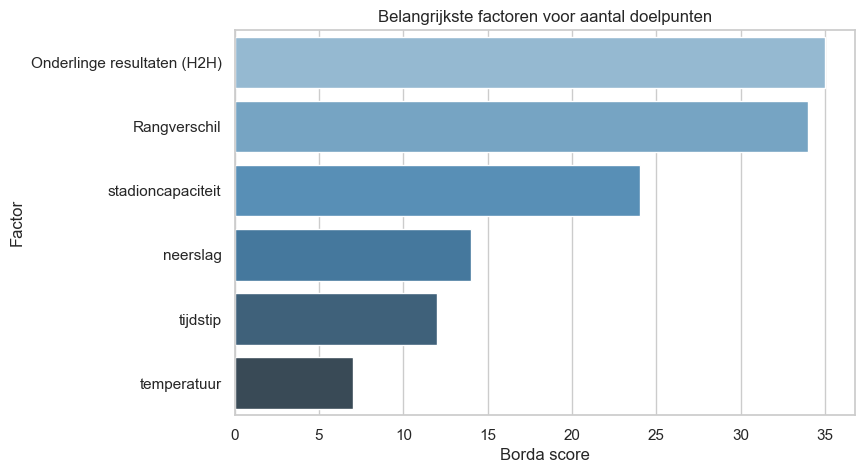

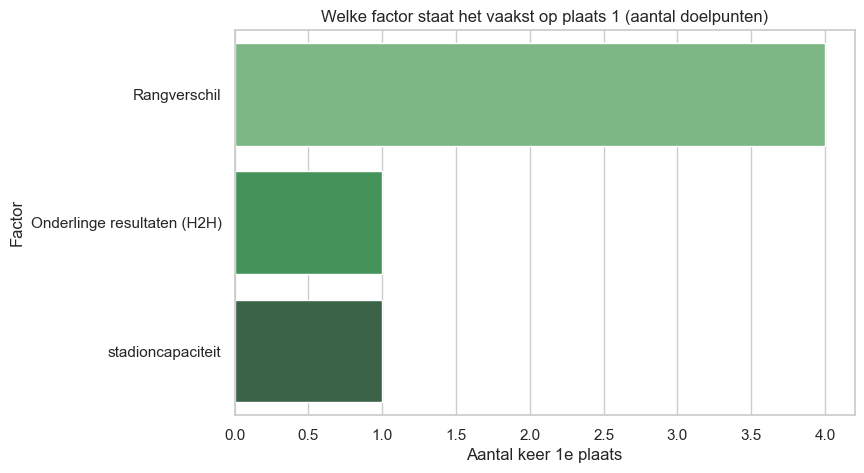

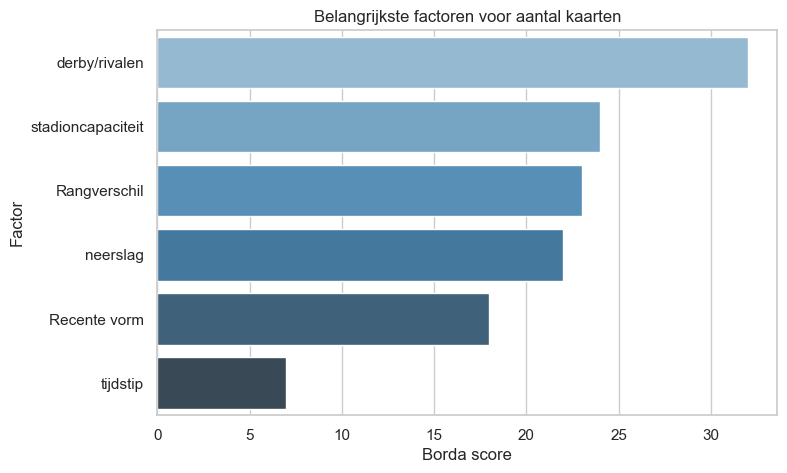

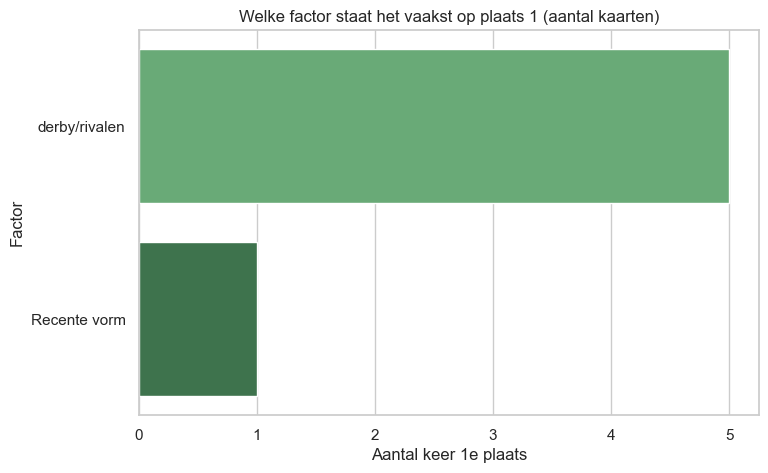

In [812]:
# Winst/verlies
scores_winst = borda_score_plot(enquete_df, "winst/verlies", "Belangrijkste factoren voor winst/verlies")

# Doelpunten
scores_doelpunten = borda_score_plot(enquete_df, "aantal doelpunten", "Belangrijkste factoren voor aantal doelpunten")

# Kaarten
scores_kaarten = borda_score_plot(enquete_df, "aantal kaarten", "Belangrijkste factoren voor aantal kaarten")

### Intuïtieve causale inschattingen

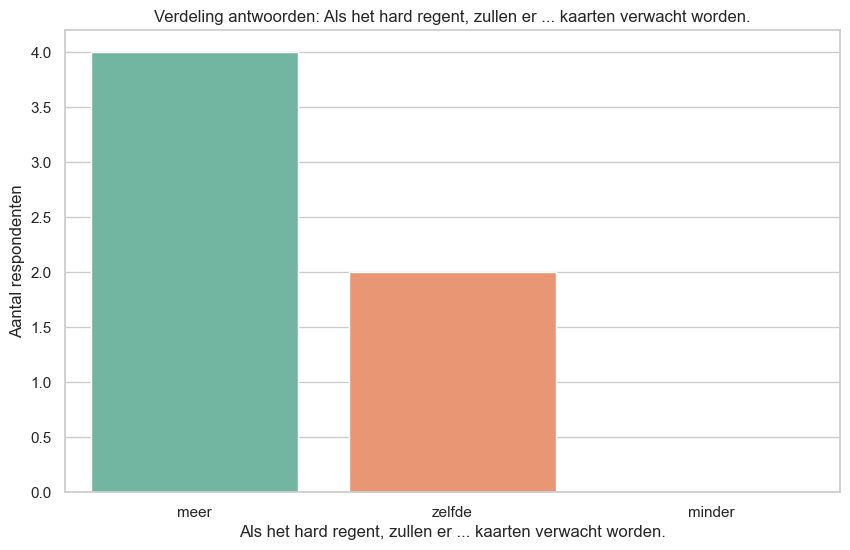

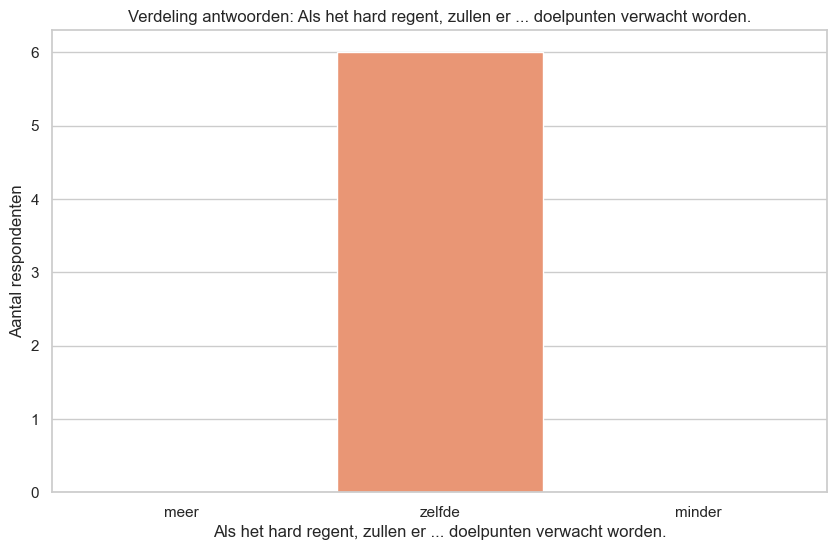

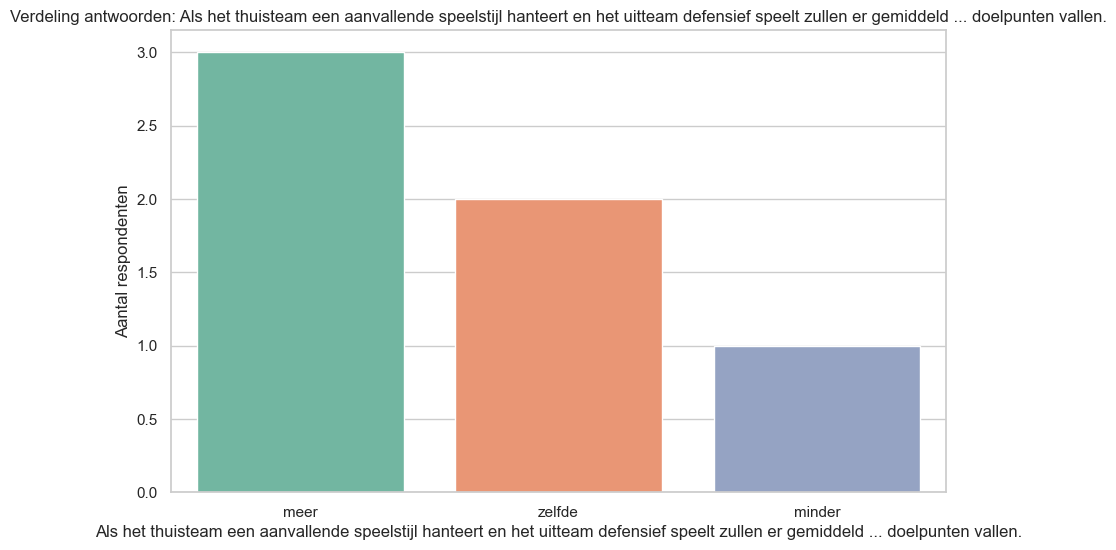

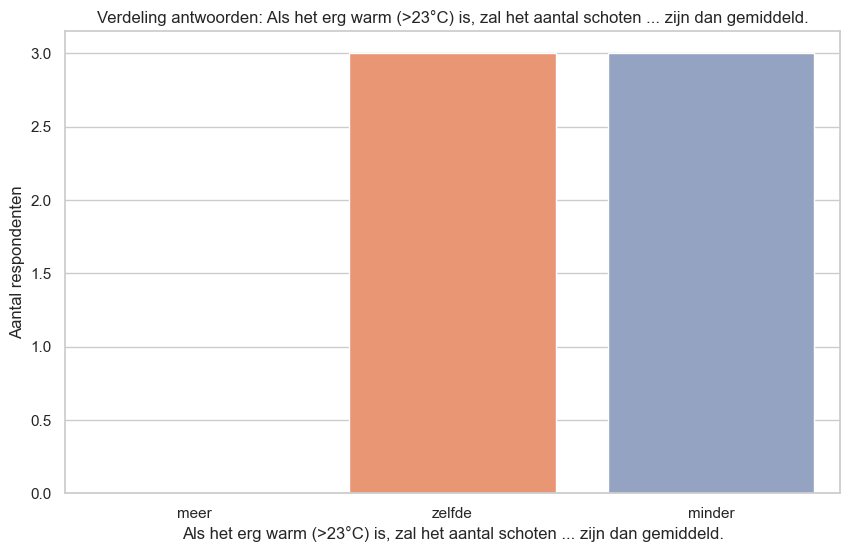

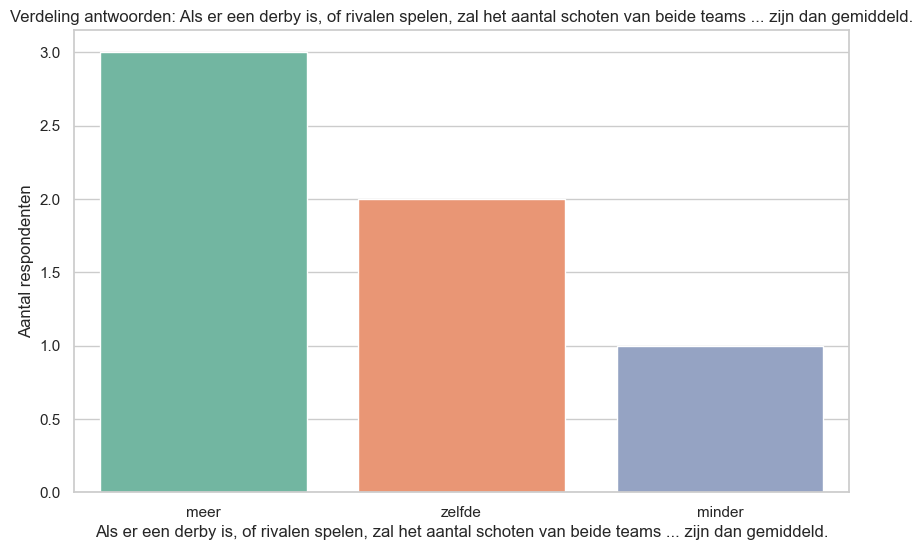

In [813]:
causale_vragen = [
    "Als het hard regent, zullen er ... kaarten verwacht worden.",
    "Als het hard regent, zullen er ... doelpunten verwacht worden.",
    "Als het thuisteam een aanvallende speelstijl hanteert en het uitteam defensief speelt zullen er gemiddeld ... doelpunten vallen.",
    "Als het erg warm (>23°C) is, zal het aantal schoten ... zijn dan gemiddeld.",
    "Als er een derby is, of rivalen spelen, zal het aantal schoten van beide teams ... zijn dan gemiddeld."
]

for col in causale_vragen:
    if col in enquete_df.columns:
        plt.figure()
        sns.countplot(data=enquete_df, x=col, order=["meer","zelfde","minder"], palette="Set2")
        plt.title(f"Verdeling antwoorden: {col}")
        plt.ylabel("Aantal respondenten")
        plt.show()

## 11. Experts vs Model vergelijken

- Kansvoorspellingen (Brier score)
- Doelpunten (MAE / RMSE)
- Visualisatie (scatterplots, barplots)

## 12. Confidence vs Accuracy

- Confidence bins
- Accuracy per bin
- Calibration plots
- Analyse van over- of underconfidence

## 13. Bias analyse

- Thuisvoordeel overschatting
- Motivatie overschatting
- Vorm, rangverschil
- Histogrammen / visualisaties

## 14. Visualisaties

- Factor importance
- Experts vs model resultaten
- Doelpunten vergelijking
- Confidence calibration
- Interactieve grafieken (optioneel)

## 15. Conclusie / Discussie

- Belangrijkste bevindingen
- Factoren met grootste effect
- Verschillen experts vs model
- Limitaties
- Suggesties vervolgonderzoek